# Improved DINOv2 Fisheye Semantic Segmentation (Syn→Real-ready Baseline)

This notebook is an **improved, self-contained** version of the original group notebook:
- fixes train/val augmentation split bug
- adds **global** mIoU computation (confusion-matrix based)
- supports **1000-sample training** with **75/25** split
- makes label mapping explicit and reproducible (RGB→class)
- upgrades decoder to a **multi-layer DINOv2 feature fusion** head (SegFormer-like, but lightweight)
- uses **GroupNorm** instead of BatchNorm (better for small batch sizes)
- adds optional **class-weighted CE + Dice** and safer augmentations

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
from pathlib import Path

# Paths in Google Drive
ZIP_ROOT = Path('/content/drive/MyDrive/')

RGB_ZIP = ZIP_ROOT / 'rgb_images.zip'
LABEL_ZIP = ZIP_ROOT / 'gtLabels.zip'
LIDAR_ZIP = ZIP_ROOT / 'lidar_data.zip'

# Local extraction directory (FAST)
EXTRACT_ROOT = Path('/content/datasets/synwoodscape')
RGB_DIR = EXTRACT_ROOT / 'rgb_images'
LABEL_DIR = EXTRACT_ROOT / 'gtLabels'
LIDAR_DIR = EXTRACT_ROOT / 'lidar_data'

RGB_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)
LIDAR_DIR.mkdir(parents=True, exist_ok=True)

def unzip(zip_path, extract_to):
    print(f"Unzipping {zip_path.name} → {extract_to}")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)

# Unzip only if not already extracted
if not RGB_DIR.exists() or not any(RGB_DIR.iterdir()):
    unzip(RGB_ZIP, RGB_DIR)
if not LABEL_DIR.exists() or not any(LABEL_DIR.iterdir()):
    unzip(LABEL_ZIP, LABEL_DIR)
if not LIDAR_DIR.exists() or not any(LIDAR_DIR.iterdir()):
    unzip(LIDAR_ZIP, LIDAR_DIR)



print("✅ Extraction complete")


✅ Extraction complete


In [4]:
import torch
# Kaggle CUDA
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Found 500 pkl file(s) to process.

[1/500]  00000
    [MVL] 32408 pts  →  ./depth_outputs/00000_MVL_depth.png
    [MVR] 42642 pts  →  ./depth_outputs/00000_MVR_depth.png
    [RV] 21565 pts  →  ./depth_outputs/00000_RV_depth.png
    [FV] 24761 pts  →  ./depth_outputs/00000_FV_depth.png
    Summary → ./depth_outputs/00000_summary.png

[2/500]  00001
    [MVL] 34168 pts  →  ./depth_outputs/00001_MVL_depth.png


KeyboardInterrupt: 

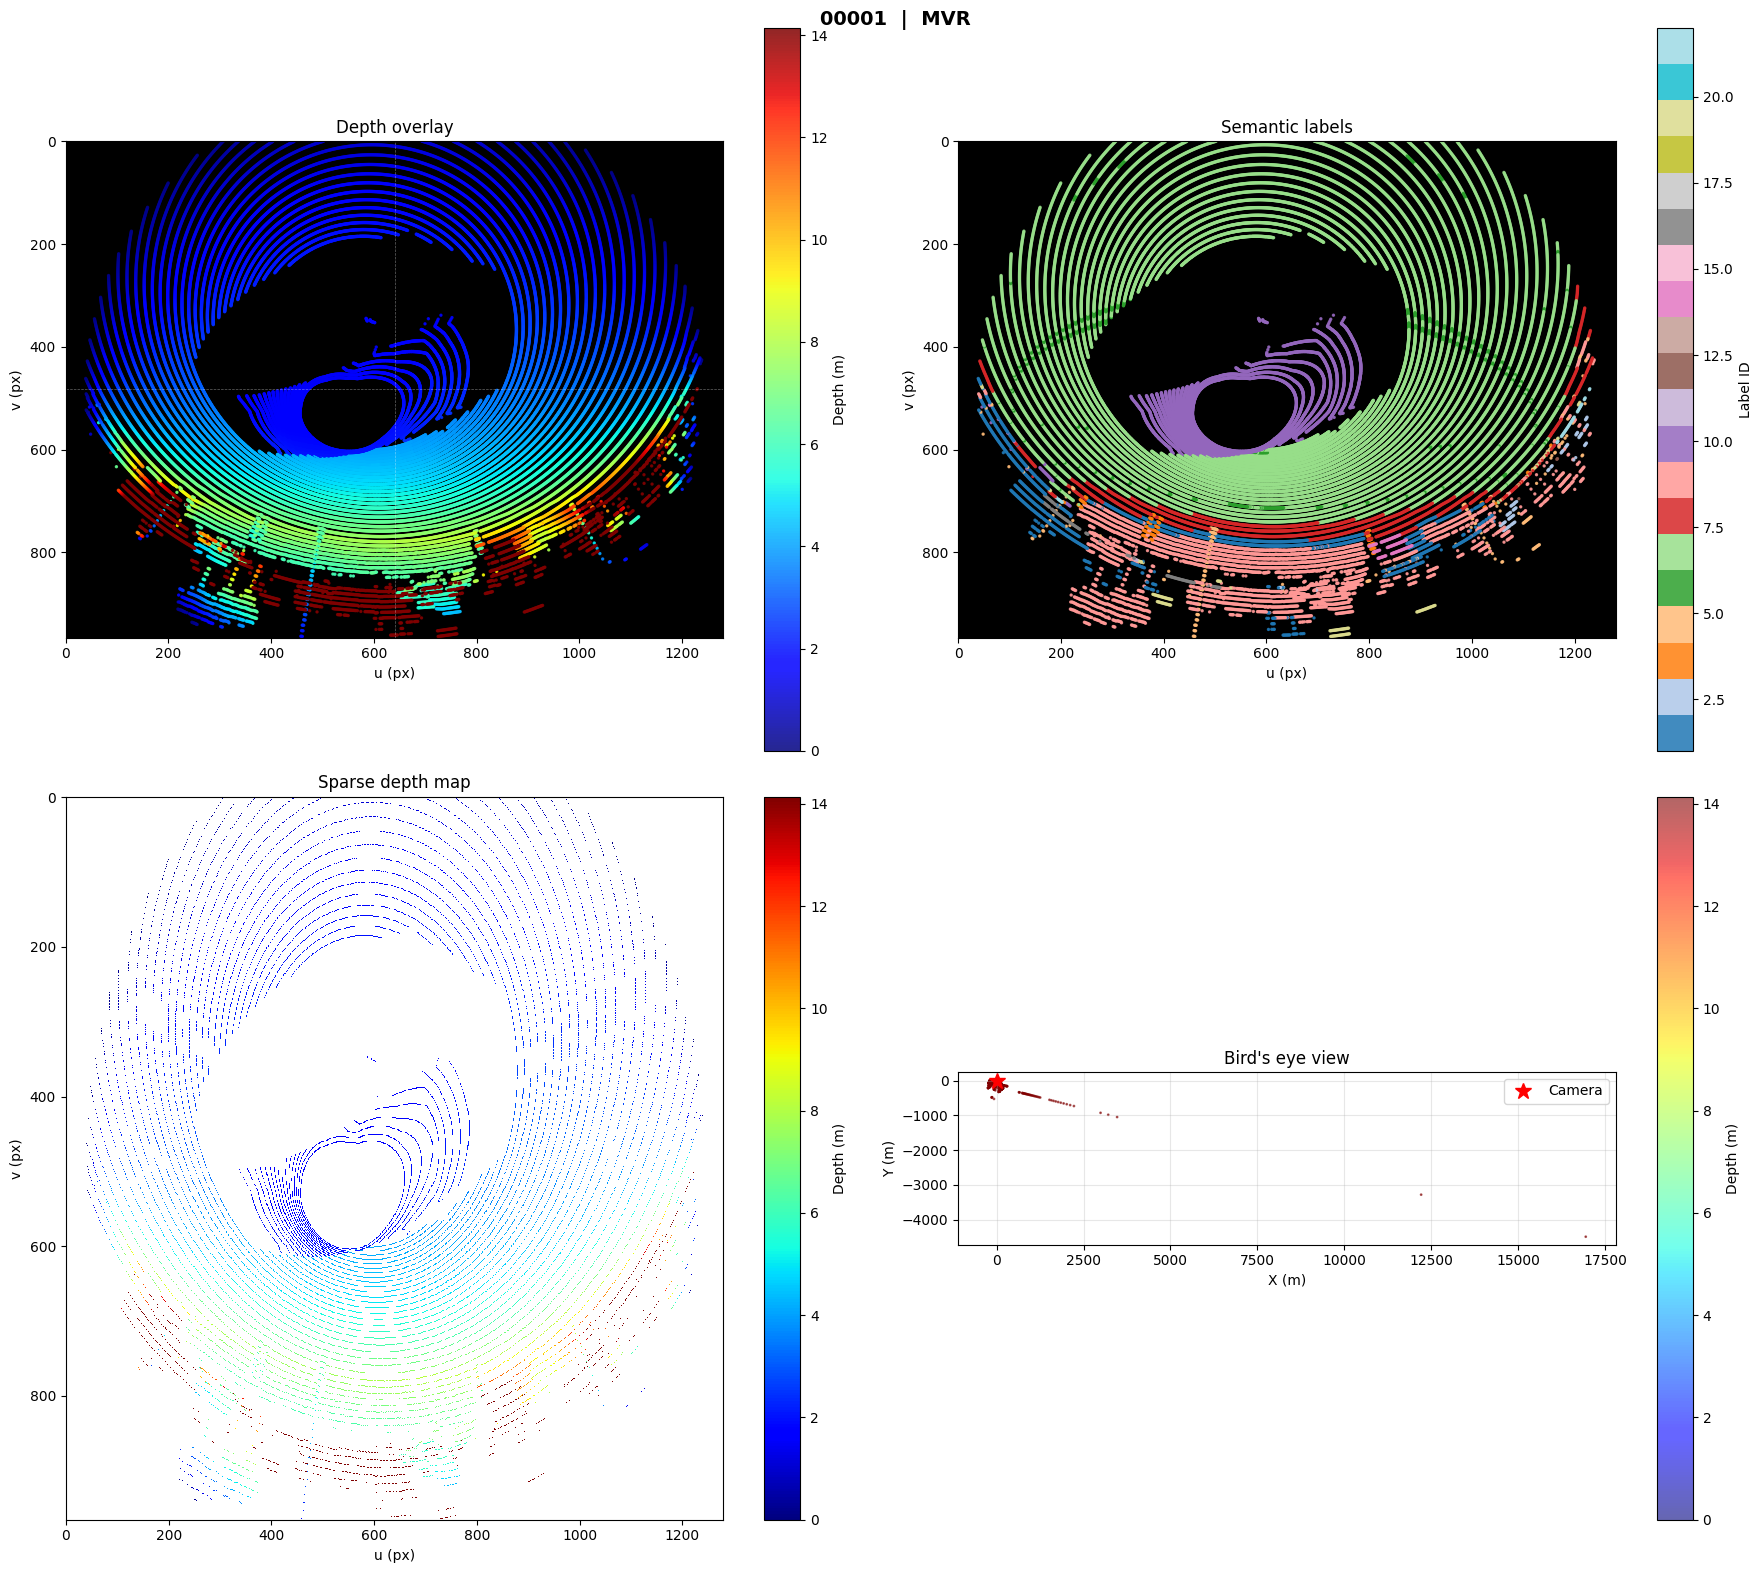

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json
import os
import glob

# ==============================================================================
# CONFIGURATION — Edit these paths
# ==============================================================================

LIDAR_DIR  = '/content/datasets/synwoodscape/lidar_data/lidar_data/'   # folder of .pkl files
IMAGES_DIR = '/content/datasets/synwoodscape/rgb_images/'              # folder of *_FV.png etc.
CALIB_DIR  = '/content/datasets/synwoodscape/calibration/'             # folder of calib JSONs
OUTPUT_DIR = './depth_outputs'

# Camera suffixes that exist for every lidar frame
CAMERA_NAMES = ['BEV', 'MVL', 'MVR', 'RV', 'FV']

# Image extensions to try, in priority order
IMAGE_EXTENSIONS = ['.png', '.jpg', '.jpeg']

# Set to None to process every pkl file, or set a limit for testing e.g. 5
MAX_FILES = None

# ==============================================================================
# CALIBRATION — Paste each camera's dict here (same structure as before).
# If a matching JSON file is found in CALIB_DIR it takes priority.
# ==============================================================================

CALIBRATIONS = CALIBRATIONS = {
    "FV": {
        "extrinsic": {
            "quaternion":  [0.6202204286587283, -0.6042974885762495,
                            0.36354706163082123, -0.34348900878254707],
            "translation": [1.92, 0.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 0.329055,
            "cy_offset": -3.5506,
            "height":    966.0,
            "k1": 341.725,
            "k2": -26.4448,
            "k3": 32.7864,
            "k4": 0.50499,
            "width": 1280.0
        }
    },
    "MVL": {
        "extrinsic": {
            "quaternion":  [0.9625033676947315, 0.24265726834768292,
                            -0.00839554023354343, -0.12097203064563249],
            "translation": [0.8, 1.0, -0.9]
        },
        "intrinsic": {
            "cx_offset": 1.185,
            "cy_offset": -3.36745,
            "height":    966.0,
            "k1": 342.234,
            "k2": -18.6659,
            "k3": 23.1572,
            "k4": 4.28064,
            "width": 1280.0
        }
    },
    "MVR": {
        "extrinsic": {
            "quaternion":  [0.2538667538615206, 0.9591523340962085,
                            -0.12402493162210342, -0.014010268296567839],
            "translation": [0.8, 1.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 0.384268,
            "cy_offset": -0.461036,
            "height":    966.0,
            "k1": 340.749,
            "k2": -16.9704,
            "k3": 20.9909,
            "k4": 4.60924,
            "width": 1280.0
        }
    },
    "RV": {
        "extrinsic": {
            "quaternion":  [0.6618934113759706, 0.6615469354954553,
                            -0.24866366735447534, -0.24983823696839286],
            "translation": [-1.92, 0.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 2.86472,
            "cy_offset": -2.06627,
            "height":    966.0,
            "k1": 342.457,
            "k2": -22.4772,
            "k3": 28.5462,
            "k4": 1.78203,
            "width": 1280.0
        }
    },
    # "BEV": { ... },  ← paste when you have it
}

# ==============================================================================
# CALIBRATION LOADER
# ==============================================================================

def load_calibration(camera_name):
    """
    Try to load calibration from CALIB_DIR JSON first,
    then fall back to the hardcoded CALIBRATIONS dict.
    """
    candidates = [
        os.path.join(CALIB_DIR, f"{camera_name}.json"),
        os.path.join(CALIB_DIR, f"{camera_name.lower()}.json"),
        os.path.join(CALIB_DIR, f"calib_{camera_name}.json"),
        os.path.join(CALIB_DIR, f"calib_{camera_name.lower()}.json"),
    ]
    for path in candidates:
        if os.path.exists(path):
            with open(path, 'r') as f:
                calib = json.load(f)
            # Normalise the verbose CARLA translation key if present
            extr = calib.get('extrinsic', {})
            for key in list(extr.keys()):
                if 'translation' in key.lower() and key != 'translation':
                    extr['translation'] = extr.pop(key)
                    break
            return calib

    if camera_name in CALIBRATIONS:
        return CALIBRATIONS[camera_name]

    return None   # no calibration available

# ==============================================================================
# NAME MATCHING
# ==============================================================================

def find_image(base_name, camera_name):
    """
    Given a base name like '00040' and a camera like 'FV',
    return the full path to '00040_FV.png' (or .jpg / .jpeg),
    or None if not found.
    """
    for ext in IMAGE_EXTENSIONS:
        path = os.path.join(IMAGES_DIR, f"{base_name}_{camera_name}{ext}")
        if os.path.exists(path):
            return path
    return None

# ==============================================================================
# GEOMETRY
# ==============================================================================

def quaternion_to_rotation_matrix(q):
    """[w, x, y, z] → 3×3 rotation matrix."""
    w, x, y, z = q
    return np.array([
        [1 - 2*(y**2 + z**2),  2*(x*y - w*z),        2*(x*z + w*y)],
        [2*(x*y + w*z),        1 - 2*(x**2 + z**2),  2*(y*z - w*x)],
        [2*(x*z - w*y),        2*(y*z + w*x),        1 - 2*(x**2 + y**2)]
    ])


def create_transform_matrix(quaternion, translation):
    R = quaternion_to_rotation_matrix(quaternion)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3]  = translation
    return T


def project_lidar_to_fisheye(points_world, quaternion, translation,
                              a1, a2, a3, a4, cx, cy):
    """
    Project Nx3 world-frame points onto the fisheye image plane.
    WoodScape model: r(θ) = a1·θ + a2·θ² + a3·θ³ + a4·θ⁴
    """
    T_w2c = np.linalg.inv(create_transform_matrix(quaternion, translation))
    N = points_world.shape[0]
    pts_h = np.hstack([points_world, np.ones((N, 1))])
    pts_c = (T_w2c @ pts_h.T).T[:, :3]

    X, Y, Z = pts_c[:, 0], pts_c[:, 1], pts_c[:, 2]
    valid   = Z > 0.1

    r_xy  = np.sqrt(X**2 + Y**2)
    theta = np.arctan2(r_xy, Z)
    r_d   = a1*theta + a2*theta**2 + a3*theta**3 + a4*theta**4

    r_safe = np.maximum(r_xy, 1e-8)
    u = cx + r_d * (X / r_safe)
    v = cy + r_d * (Y / r_safe)

    return u, v, valid, pts_c


def occlusion_correction(u, v, depth, W, H):
    """Z-buffer: keep only the nearest point per pixel."""
    depth_map = np.full((H, W), np.inf)
    pid_map   = np.full((H, W), -1, dtype=int)

    ui = np.round(u).astype(int)
    vi = np.round(v).astype(int)
    ok = (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)

    mask = np.zeros(len(u), dtype=bool)
    for i in np.where(ok)[0]:
        uu, vv = ui[i], vi[i]
        if depth[i] < depth_map[vv, uu]:
            if pid_map[vv, uu] >= 0:
                mask[pid_map[vv, uu]] = False
            depth_map[vv, uu] = depth[i]
            pid_map[vv, uu]   = i
            mask[i]           = True
    return mask

# ==============================================================================
# PER-CAMERA PROCESSING
# ==============================================================================

def process_camera(base_name, camera_name, points_world, labels, calib, output_dir):
    """Project LiDAR onto one fisheye camera, save visualisation, return depth map."""

    intr        = calib['intrinsic']
    a1, a2, a3, a4 = intr['k1'], intr['k2'], intr['k3'], intr['k4']
    cx          = intr['width']  / 2.0 + intr['cx_offset']
    cy          = intr['height'] / 2.0 + intr['cy_offset']
    W           = int(intr['width'])
    H           = int(intr['height'])

    extr        = calib['extrinsic']
    quaternion  = extr['quaternion']
    translation = np.array(extr['translation'])

    # Projection
    u, v, valid, pts_c = project_lidar_to_fisheye(
        points_world, quaternion, translation, a1, a2, a3, a4, cx, cy)

    # Occlusion
    depth      = pts_c[:, 2]
    occ        = occlusion_correction(u, v, depth, W, H)
    mask       = valid & occ

    u_v   = u[mask];  v_v = v[mask]
    d_v   = depth[mask]
    lab_v = labels[mask]
    pts_v = points_world[mask]

    # Sparse depth image
    depth_img       = np.full((H, W), np.nan)
    ui              = np.round(u_v).astype(int)
    vi              = np.round(v_v).astype(int)
    in_b            = (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)
    depth_img[vi[in_b], ui[in_b]] = d_v[in_b]

    vmax = float(np.nanpercentile(d_v, 95)) if len(d_v) else 50.0

    # Load RGB image via name matching
    img_path = find_image(base_name, camera_name)
    rgb_img  = mpimg.imread(img_path) if img_path else None

    # ---- Figure ----
    n_rows = 3 if rgb_img is not None else 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 8 * n_rows))
    fig.suptitle(f'{base_name}  |  {camera_name}', fontsize=14, fontweight='bold')

    def bg(ax):
        ax.set_facecolor('black')
        if rgb_img is not None:
            ax.imshow(rgb_img, extent=[0, W, H, 0], aspect='auto')

    # Row 0 — depth scatter + semantic scatter
    ax = axes[0, 0]; bg(ax)
    sc = ax.scatter(u_v, v_v, c=d_v, s=2, cmap='jet', alpha=0.85, vmin=0, vmax=vmax)
    ax.set(xlim=(0, W), ylim=(H, 0), title='Depth overlay',
           xlabel='u (px)', ylabel='v (px)')
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, label='Depth (m)')
    ax.axhline(cy, color='w', lw=0.5, ls='--', alpha=0.4)
    ax.axvline(cx, color='w', lw=0.5, ls='--', alpha=0.4)

    ax = axes[0, 1]; bg(ax)
    sc = ax.scatter(u_v, v_v, c=lab_v, s=2, cmap='tab20', alpha=0.85)
    ax.set(xlim=(0, W), ylim=(H, 0), title='Semantic labels',
           xlabel='u (px)', ylabel='v (px)')
    ax.set_aspect('equal')
    plt.colorbar(sc, ax=ax, label='Label ID')

    # Row 1 — sparse depth map + BEV
    ax = axes[1, 0]
    im = ax.imshow(depth_img, cmap='jet', vmin=0, vmax=vmax,
                   interpolation='nearest', aspect='auto')
    ax.set(title='Sparse depth map', xlabel='u (px)', ylabel='v (px)')
    plt.colorbar(im, ax=ax, label='Depth (m)')

    ax = axes[1, 1]
    sc = ax.scatter(pts_v[:, 0], pts_v[:, 1], c=d_v, s=1,
                    cmap='jet', alpha=0.6, vmin=0, vmax=vmax)
    ax.plot(translation[0], translation[1], 'r*', ms=12, label='Camera')
    ax.set(title="Bird's eye view", xlabel='X (m)', ylabel='Y (m)')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
    plt.colorbar(sc, ax=ax, label='Depth (m)')

    # Row 2 — RGB + proximity scatter (only when image found)
    if rgb_img is not None:
        ax = axes[2, 0]
        ax.imshow(rgb_img); ax.set_title('Original RGB'); ax.axis('off')

        ax = axes[2, 1]; bg(ax)
        sizes = np.clip(300 / (d_v + 1e-3), 1, 20)
        sc = ax.scatter(u_v, v_v, c=d_v, s=sizes, cmap='plasma',
                        alpha=0.9, vmin=0, vmax=vmax)
        ax.set(xlim=(0, W), ylim=(H, 0),
               title='Depth overlay (size ∝ proximity)')
        ax.set_aspect('equal')
        plt.colorbar(sc, ax=ax, label='Depth (m)')

    plt.tight_layout()
    out_path = os.path.join(output_dir, f"{base_name}_{camera_name}_depth.png")
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.close(fig)
    print(f"    [{camera_name}] {mask.sum()} pts  →  {out_path}")

    return depth_img


# ==============================================================================
# BATCH RUNNER
# ==============================================================================

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Collect all pkl files, sorted by name
    pkl_files = sorted(glob.glob(os.path.join(LIDAR_DIR, '*.pkl')))
    if not pkl_files:
        print(f"No .pkl files found in {LIDAR_DIR}")
        return

    if MAX_FILES is not None:
        pkl_files = pkl_files[:MAX_FILES]

    print(f"Found {len(pkl_files)} pkl file(s) to process.\n")

    # Pre-load calibrations once (they're the same for all frames)
    calibrations = {}
    for cam in CAMERA_NAMES:
        calib = load_calibration(cam)
        if calib is not None:
            calibrations[cam] = calib
        else:
            print(f"WARNING: No calibration for {cam} — it will be skipped.")

    if not calibrations:
        print("No calibrations loaded. Exiting.")
        return

    # ---- Main loop over pkl files ----
    for pkl_idx, pkl_path in enumerate(pkl_files, 1):
        base_name = os.path.splitext(os.path.basename(pkl_path))[0]
        print(f"[{pkl_idx}/{len(pkl_files)}]  {base_name}")

        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)

        points_world = data['points']
        labels       = data['labels']

        depth_maps = {}

        for cam, calib in calibrations.items():
            depth_maps[cam] = process_camera(
                base_name, cam, points_world, labels, calib, OUTPUT_DIR
            )

        # ---- Summary strip for this frame ----
        cams_done = list(depth_maps.keys())
        fig, axes = plt.subplots(1, len(cams_done),
                                 figsize=(6 * len(cams_done), 4))
        if len(cams_done) == 1:
            axes = [axes]

        for ax, cam in zip(axes, cams_done):
            dm   = depth_maps[cam]
            vmax = float(np.nanpercentile(dm[~np.isnan(dm)], 95)) \
                   if not np.all(np.isnan(dm)) else 50.0
            im = ax.imshow(dm, cmap='jet', vmin=0, vmax=vmax,
                           interpolation='nearest', aspect='auto')
            ax.set_title(cam, fontsize=10)
            ax.axis('off')
            plt.colorbar(im, ax=ax, label='m', shrink=0.8)

        fig.suptitle(f'Sparse depth maps — {base_name}', fontsize=12)
        plt.tight_layout()
        strip_path = os.path.join(OUTPUT_DIR, f"{base_name}_summary.png")
        plt.savefig(strip_path, dpi=120, bbox_inches='tight')
        plt.close(fig)
        print(f"    Summary → {strip_path}\n")

    print("All done.")


if __name__ == '__main__':
    main()

In [ ]:
print("Image shape:", image_shape)
print("K matrix:\n", K)


Image shape: (720, 1280)
K matrix:
 [[700   0 640]
 [  0 700 360]
 [  0   0   1]]


In [6]:
from tqdm.auto import tqdm

In [7]:
import os, json, random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch

SEED = 42
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# Kaggle: Use CUDA instead of MPS
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")



class Config:
    # ---- data ----
    # Kaggle: Set DATA_ROOT to /kaggle/input/your-dataset-name/
    # The dataset should contain the SynWoodScape folder structure
    data_root: str = ""  # TODO: set this to /kaggle/input/your-dataset-name/SynWoodScape_V0.1.0
    image_dir: str = ""  # if empty, auto-discover under data_root
    mask_dir: str  = ""  # if empty, auto-discover under data_root/semantic_annotations/gtLabels
    mask_format: str = "auto"  # "auto" | "rgb" | "id"
    file_ext: str  = ".png"
    max_samples: int = 2500
    train_ratio: float = 0.75  # 75/25
    target_size: tuple = (518, 518)  # (W,H) for cv2; keep divisible by patch size 14
    ignore_index: int = 255

    # ---- label space ----
    num_classes: int = 0  # TODO: set K (unified label space). If using ID masks, K can be inferred if left as 0.
    COLOR_MAP: dict = None  # loaded below

    # ---- model ----
    model_name: str = "dinov2_vitb14"
    freeze_backbone: bool = True
    n_intermediate_layers: int = 4  # fuse last N layers if available
    decoder_dim: int = 256
    dropout: float = 0.1

    # ---- training ----
    batch_size: int = 4
    epochs: int =100
    lr: float = 2e-4
    weight_decay: float = 1e-4
    grad_accum_steps: int = 2  # effective batch = batch_size * grad_accum_steps
    use_amp: bool = True  # Automatic Mixed Precision works on Kaggle GPUs
    use_dice: bool = True
    dice_weight: float = 0.3  # total = (1-dw)*CE + dw*Dice
    use_class_weights: bool = True

    # ---- output ----
    # Kaggle: Save to /kaggle/working/ (the only writable directory)
    out_dir: str = "/kaggle/working/checkpoints_improved"


def _count_images(d: Path, exts=(".png",".jpg",".jpeg",".webp")) -> int:
    if not d.exists() or not d.is_dir():
        return 0
    n=0
    for e in exts:
        n += len(list(d.glob(f"**/*{e}")))
    return n

def auto_discover_paths(cfg: Config):
    """Auto-discover image_dir/mask_dir for SynWoodScape-style folder layout."""
    root = Path(cfg.data_root).expanduser() if cfg.data_root else None

    # ---- mask dir ----
    if not cfg.mask_dir:
        if root:
            cand1 = root / "semantic_annotations" / "rgbLabels"
            cand2 = root / "semantic_annotations" / "gtLabels"
            if cand1.exists():
                cfg.mask_dir = str(cand1)
                print(f"✓ Auto-discovered mask_dir: {cfg.mask_dir}")
            elif cand2.exists():
                cfg.mask_dir = str(cand2)
                print(f"✓ Auto-discovered mask_dir: {cfg.mask_dir}")

    # ---- image dir ----
    if not cfg.image_dir and root:
        # Heuristic search: pick the directory with most images, excluding label/annotation folders
        candidates = []
        for d in root.rglob("*"):
            if not d.is_dir():
                continue
            name = str(d).lower()
            if any(x in name for x in ["semantic_annotations", "labels", "gtlabels", "rgblabels", "annotation"]):
                continue
            n = _count_images(d)
            if n >= 50:  # ignore tiny folders
                score = n
                if "rgb" in name: score += 2000
                if "fisheye" in name or "surround" in name: score += 1000
                if "image" in name or "images" in name: score += 500
                candidates.append((score, n, d))
        candidates.sort(reverse=True, key=lambda x: x[0])
        if candidates:
            cfg.image_dir = str(candidates[0][2])
            print("\n✓ Auto-discovered image_dir candidates (top 5):")
            for s,n,d in candidates[:5]:
                print(f"  - {d}  (images≈{n}, score={s})")

    # ---- sanity checks ----
    if not cfg.image_dir or not Path(cfg.image_dir).exists():
        raise FileNotFoundError(
            f"❌ image_dir not found. Please set cfg.image_dir to the folder containing RGB images.\n"
            f"Current cfg.image_dir={cfg.image_dir!r}, cfg.data_root={cfg.data_root!r}\n"
            f"Kaggle tip: Use '/kaggle/input/your-dataset-name/...' paths"
        )
    if not cfg.mask_dir or not Path(cfg.mask_dir).exists():
        raise FileNotFoundError(
            f"❌ mask_dir not found. Please set cfg.mask_dir to semantic_annotations/rgbLabels (RGB masks) "
            f"or semantic_annotations/gtLabels (ID masks).\n"
            f"Current cfg.mask_dir={cfg.mask_dir!r}, cfg.data_root={cfg.data_root!r}\n"
            f"Kaggle tip: Use '/kaggle/input/your-dataset-name/...' paths"
        )

def auto_detect_mask_format(mask_path: Path) -> str:
    import cv2
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m is None:
        return "rgb"
    if len(m.shape) == 2:
        return "id"
    if m.shape[2] == 1:
        return "id"
    return "rgb"

def infer_num_classes_from_id_masks(mask_dir: str, file_ext: str = ".png", ignore_index: int = 255, max_files: int = 100) -> int:
    import cv2
    p = Path(mask_dir)
    files = list(p.rglob(f"*{file_ext}"))[:max_files]
    mx = -1
    print(f"Inferring num_classes from up to {len(files)} mask files...")
    for i, f in enumerate(files):
        if i % 20 == 0:
            print(f"  Processing {i+1}/{len(files)}...", end='\r')
        m = cv2.imread(str(f), cv2.IMREAD_UNCHANGED)
        if m is None:
            continue
        if len(m.shape) == 3:
            m = m[...,0]
        valid = m[m != ignore_index]
        if valid.size:
            mx = max(mx, int(valid.max()))
    print()  # New line
    return (mx + 1) if mx >= 0 else 0


# ============================================================================
# KAGGLE CONFIGURATION
# ============================================================================

cfg = Config()

# TODO: UPDATE THESE PATHS FOR YOUR KAGGLE DATASET
# Example: If your dataset is named "synwoodscape-dataset" on Kaggle
# cfg.data_root = "/kaggle/input/synwoodscape-dataset/SynWoodScape_V0.1.0"

# Option 1: Set data_root and let auto-discovery find image_dir and mask_dir
 # UPDATE THIS

# Option 2: Or explicitly set paths (if auto-discovery doesn't work)
cfg.image_dir = "/content/datasets/synwoodscape/rgb_images/rgb_images"
cfg.mask_dir  = "/content/datasets/synwoodscape/gtLabels/gtLabels"

print("\n" + "="*70)
print("KAGGLE DATASET CONFIGURATION")
print("="*70)

# If using explicit paths, verify they exist
if cfg.data_root and not cfg.image_dir:
    print(f"\n📁 Data root: {cfg.data_root}")
    if Path(cfg.data_root).exists():
        print("✓ Data root exists")
        # List contents to help user verify structure
        print("\nContents of data_root:")
        try:
            for item in sorted(Path(cfg.data_root).iterdir())[:10]:
                print(f"  - {item.name}")
        except Exception as e:
            print(f"  Could not list: {e}")
    else:
        print("❌ Data root does NOT exist")
        print("\n💡 Kaggle Tips:")
        print("  1. Make sure you've added the dataset in notebook settings")
        print("  2. Check available datasets: !ls /kaggle/input/")
        print("  3. Dataset path format: /kaggle/input/dataset-name/...")

# Count files in explicit paths (if set)
if cfg.image_dir:
    print(f"\n📁 Image dir: {cfg.image_dir}")
    if Path(cfg.image_dir).exists():
        print("  PNG images:", len(list(Path(cfg.image_dir).rglob("*.png"))))
        print("  JPG images:", len(list(Path(cfg.image_dir).rglob("*.jpg"))))
    else:
        print("  ❌ Does NOT exist")

if cfg.mask_dir:
    print(f"\n📁 Mask dir: {cfg.mask_dir}")
    if Path(cfg.mask_dir).exists():
        print("  PNG masks:", len(list(Path(cfg.mask_dir).rglob("*.png"))))
    else:
        print("  ❌ Does NOT exist")

# ---- Resolve data paths ----
# If set cfg.data_root (recommended), we will auto-discover:
#   - cfg.mask_dir default: <data_root>/semantic_annotations/rgbLabels (or gtLabels)
#   - cfg.image_dir: best candidate folder with many RGB images under <data_root>
if cfg.data_root and (not cfg.image_dir or not cfg.mask_dir):
    print("\n🔍 Auto-discovering paths...")
    auto_discover_paths(cfg)

print("\n" + "="*70)
print("FINAL CONFIGURATION")
print("="*70)
print(f"✓ image_dir: {cfg.image_dir}")
print(f"✓ mask_dir : {cfg.mask_dir}")

# ---- Auto-detect mask format ----
if cfg.mask_format == "auto":
    print("\n🔍 Auto-detecting mask format...")
    sample_masks = list(Path(cfg.mask_dir).rglob(f"*{cfg.file_ext}"))
    if sample_masks:
        sample_mask = sample_masks[0]
        cfg.mask_format = auto_detect_mask_format(sample_mask)
        print(f"✓ Detected format: {cfg.mask_format}")
    else:
        print(f"⚠ No mask files found with extension {cfg.file_ext}")
        cfg.mask_format = "id"  # default fallback

print(f"✓ Mask format: {cfg.mask_format} (rgb=color-coded, id=integer labels)")


# ---- Load COLOR_MAP (only needed for RGB masks) ----
if cfg.mask_format == "rgb":
    # Option A: load from JSON file (recommended for reproducibility)
    # JSON format: {"128,64,128": 0, "244,35,232": 1, ...}

    # Kaggle: Check if color map JSON is in the dataset
    COLOR_MAP_JSON = None

    # Try to find color map JSON in dataset
    if cfg.data_root:
        potential_json_paths = [
            Path(cfg.data_root) / "color_map.json",
            Path(cfg.data_root) / "semantic_annotations" / "color_map.json",
            Path(cfg.mask_dir).parent / "color_map.json",
        ]
        for json_path in potential_json_paths:
            if json_path.exists():
                COLOR_MAP_JSON = str(json_path)
                print(f"✓ Found color map JSON: {COLOR_MAP_JSON}")
                break

    if COLOR_MAP_JSON and os.path.exists(COLOR_MAP_JSON):
        with open(COLOR_MAP_JSON, "r") as f:
            raw = json.load(f)
        cfg.COLOR_MAP = {tuple(map(int, k.split(","))): int(v) for k, v in raw.items()}
        print(f"✓ Loaded {len(cfg.COLOR_MAP)} color mappings from JSON")
    else:
        print("\n⚠ WARNING: No color_map.json found!")
        print("  For RGB masks, you need to provide a color mapping.")
        print("  Creating placeholder - YOU MUST UPDATE THIS!")
        # Option B: hardcode here (placeholder MUST be replaced with dataset mapping)
        cfg.COLOR_MAP = {
            # Example placeholder (Cityscapes-like). REPLACE with dataset mapping.
            (128, 64, 128): 0,   # road
            (244, 35, 232): 1,   # sidewalk
        }

    if cfg.num_classes <= 0:
        cfg.num_classes = max(cfg.COLOR_MAP.values()) + 1
    assert cfg.num_classes == (max(cfg.COLOR_MAP.values()) + 1), (
        f"num_classes={cfg.num_classes} but COLOR_MAP max id={max(cfg.COLOR_MAP.values())}"
    )
    print(f"✓ K (num_classes) = {cfg.num_classes}")
    print(f"✓ COLOR_MAP entries = {len(cfg.COLOR_MAP)}")
else:
    # ID masks (e.g., gtLabels): no COLOR_MAP needed.
    cfg.COLOR_MAP = None
    if cfg.num_classes <= 0:
        print("\n🔍 Inferring num_classes from ID masks...")
        cfg.num_classes = infer_num_classes_from_id_masks(cfg.mask_dir, cfg.file_ext, cfg.ignore_index)
    print(f"✓ K (num_classes) = {cfg.num_classes} (inferred/defined for ID masks)")

# Create output directory
os.makedirs(cfg.out_dir, exist_ok=True)
print(f"\n✓ Output directory: {cfg.out_dir}")

print("\n" + "="*70)
print("CONFIGURATION COMPLETE")
print("="*70)
print(f"Device: {device}")
print(f"Batch size: {cfg.batch_size}")
print(f"Epochs: {cfg.epochs}")
print(f"Mixed precision: {cfg.use_amp}")
print(f"Max samples: {cfg.max_samples}")
print("="*70 + "\n")

device = cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU Memory: 101.97 GB

KAGGLE DATASET CONFIGURATION

📁 Image dir: /content/datasets/synwoodscape/rgb_images/rgb_images
  PNG images: 2500
  JPG images: 0

📁 Mask dir: /content/datasets/synwoodscape/gtLabels/gtLabels
  PNG masks: 2500

FINAL CONFIGURATION
✓ image_dir: /content/datasets/synwoodscape/rgb_images/rgb_images
✓ mask_dir : /content/datasets/synwoodscape/gtLabels/gtLabels

🔍 Auto-detecting mask format...
✓ Detected format: id
✓ Mask format: id (rgb=color-coded, id=integer labels)

🔍 Inferring num_classes from ID masks...
Inferring num_classes from up to 100 mask files...

✓ K (num_classes) = 25 (inferred/defined for ID masks)

✓ Output directory: /kaggle/working/checkpoints_improved

CONFIGURATION COMPLETE
Device: cuda
Batch size: 4
Epochs: 100
Mixed precision: True
Max samples: 2500



In [8]:
import cv2
from PIL import Image
from typing import Dict, Tuple, List, Sequence
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Kaggle-specific optimizations
import os
import gc

def list_pairs(
    image_dir: str,
    mask_dir: str,
    img_exts: Sequence[str] = (".png", ".jpg", ".jpeg", ".webp"),
    mask_ext: str = ".png",
) -> List[Tuple[Path, Path]]:
    """
    Pair RGB images with segmentation masks in SynWoodScape-style layouts.
    Robust pairing logic:
    1) Recursively collect images under image_dir for any extension in img_exts.
    2) First try SAME relative path under mask_dir, but with suffix changed to mask_ext.
       Example:
         rgb_images/FRONT/seq/000123.jpg  ->  gtLabels/FRONT/seq/000123.png
    3) If not found, try same relative path without changing suffix.
    4) Fallback: match by filename (and by stem+mask_ext) at mask_dir root.
    """
    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir)

    # Kaggle: Verify paths exist
    if not image_dir.exists():
        raise FileNotFoundError(f"Image directory not found: {image_dir}")
    if not mask_dir.exists():
        raise FileNotFoundError(f"Mask directory not found: {mask_dir}")

    img_files: List[Path] = []
    for e in img_exts:
        img_files.extend(image_dir.rglob(f"*{e}"))
    img_files = sorted(img_files)

    print(f"Found {len(img_files)} image files")

    pairs: List[Tuple[Path, Path]] = []
    missing_masks = 0

    for img_path in img_files:
        rel = img_path.relative_to(image_dir)
        # preferred: same relpath, but mask is usually .png
        cand1 = mask_dir / rel.with_suffix(mask_ext)
        cand2 = mask_dir / rel  # if masks share same suffix (rare)
        cand3 = mask_dir / img_path.name
        cand4 = mask_dir / (img_path.stem + mask_ext)

        mask_path = None
        for c in (cand1, cand2, cand3, cand4):
            if c.exists():
                mask_path = c
                break

        if mask_path is not None:
            pairs.append((img_path, mask_path))
        else:
            missing_masks += 1

    if missing_masks > 0:
        print(f"Warning: {missing_masks} images have no matching masks")

    return pairs


def analyze_unique_colors(mask_paths: List[Path], max_files: int = 20) -> Dict[Tuple[int,int,int], int]:
    """
    Quick helper to inspect which RGB colors appear in RGB masks.
    Optimized for Kaggle environment with memory management.
    """
    color_counts = {}

    for i, p in enumerate(mask_paths[:max_files]):
        if i % 5 == 0:
            print(f"Analyzing mask {i+1}/{min(len(mask_paths), max_files)}...", end='\r')

        m = np.array(Image.open(p).convert("RGB"))
        colors, counts = np.unique(m.reshape(-1, 3), axis=0, return_counts=True)

        for c, cnt in zip(colors, counts):
            t = tuple(int(x) for x in c.tolist())
            color_counts[t] = color_counts.get(t, 0) + int(cnt)

        # Free memory
        del m

    print()  # New line after progress
    gc.collect()

    return dict(sorted(color_counts.items(), key=lambda kv: kv[1], reverse=True))


# Kaggle-specific configuration
class KaggleConfig:
    """Configuration class for Kaggle environment"""
    def __init__(self):
        # Kaggle paths typically start with /kaggle/input/
        # Adjust these paths based on your dataset structure
        self.image_dir = "/content/datasets/synwoodscape/rgb_images/rgb_images"  # UPDATE THIS
        self.mask_dir = "/content/datasets/synwoodscape/gtLabels/gtLabels"     # UPDATE THIS
        self.file_ext = ".png"
        self.max_samples = 2500

        # Kaggle output directory
        self.output_dir = "/kaggle/working/"

    def update_paths(self, image_dir: str = None, mask_dir: str = None):
        """Update paths for your specific dataset"""
        if image_dir:
            self.image_dir = image_dir
        if mask_dir:
            self.mask_dir = mask_dir


# Main execution
if __name__ == "__main__":
    SEED = 42
    np.random.seed(SEED)

    # Initialize configuration
    cfg = KaggleConfig()

    # For Kaggle, you need to update these paths based on your dataset
    # Example: If your dataset is named "synwoodscape-dataset"
    # cfg.update_paths(
    #     image_dir="/kaggle/input/synwoodscape-dataset/rgb_images",
    #     mask_dir="/kaggle/input/synwoodscape-dataset/gtLabels"
    # )

    print("=" * 60)
    print("KAGGLE GPU DATASET LOADER")
    print("=" * 60)

    # Check GPU availability
    try:
        import torch
        if torch.cuda.is_available():
            print(f"✓ GPU Available: {torch.cuda.get_device_name(0)}")
            print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        else:
            print("⚠ No GPU detected - running on CPU")
    except ImportError:
        print("⚠ PyTorch not imported - GPU check skipped")

    print("=" * 60)

    # List image-mask pairs
    print(f"\nSearching for image-mask pairs...")
    print(f"Image dir: {cfg.image_dir}")
    print(f"Mask dir: {cfg.mask_dir}")

    pairs = list_pairs(
        cfg.image_dir,
        cfg.mask_dir,
        img_exts=(".png", ".jpg", ".jpeg", ".webp"),
        mask_ext=cfg.file_ext
    )

    print(f"\n✓ Found {len(pairs)} valid pairs")

    # Limit to max_samples
    if len(pairs) > cfg.max_samples:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(pairs), size=cfg.max_samples, replace=False)
        pairs = [pairs[i] for i in idx]
        print(f"✓ Randomly selected {cfg.max_samples} pairs for training")

    print(f"\n✓ Using {len(pairs)} pairs")

    # Optional: Inspect RGB mask colors if using rgbLabels
    if len(pairs) > 0:
        print("\nAnalyzing mask colors (first 10 masks)...")
        color_counts = analyze_unique_colors([m for _, m in pairs], max_files=10)
        print("\nTop 20 colors found:")
        for i, (color, count) in enumerate(list(color_counts.items())[:20], 1):
            print(f"  {i}. RGB{color}: {count:,} pixels")

    # Save pairs list for later use
    pairs_file = Path(cfg.output_dir) / "image_mask_pairs.txt"
    with open(pairs_file, 'w') as f:
        for img_path, mask_path in pairs:
            f.write(f"{img_path}\t{mask_path}\n")
    print(f"\n✓ Saved pairs list to: {pairs_file}")

    # Display sample pair
    if len(pairs) > 0:
        print("\n" + "=" * 60)
        print("SAMPLE PAIR")
        print("=" * 60)
        img_path, mask_path = pairs[0]
        print(f"Image: {img_path}")
        print(f"Mask:  {mask_path}")

        # Optional: Display visualization
        try:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            img = Image.open(img_path)
            mask = Image.open(mask_path)

            axes[0].imshow(img)
            axes[0].set_title("Sample Image")
            axes[0].axis('off')

            axes[1].imshow(mask)
            axes[1].set_title("Sample Mask")
            axes[1].axis('off')

            plt.tight_layout()
            plt.savefig(Path(cfg.output_dir) / "sample_pair.png", dpi=150, bbox_inches='tight')
            print(f"\n✓ Saved sample visualization to: {cfg.output_dir}/sample_pair.png")
            plt.close()
        except Exception as e:
            print(f"\n⚠ Could not create visualization: {e}")

    print("\n" + "=" * 60)
    print("DATASET LOADING COMPLETE")
    print("=" * 60)

KAGGLE GPU DATASET LOADER
✓ GPU Available: NVIDIA RTX PRO 6000 Blackwell Server Edition
✓ GPU Memory: 101.97 GB

Searching for image-mask pairs...
Image dir: /content/datasets/synwoodscape/rgb_images/rgb_images
Mask dir: /content/datasets/synwoodscape/gtLabels/gtLabels
Found 2500 image files

✓ Found 2500 valid pairs

✓ Using 2500 pairs

Analyzing mask colors (first 10 masks)...


Top 20 colors found:
  1. RGB(7, 7, 7): 5,180,558 pixels
  2. RGB(24, 24, 24): 2,811,820 pixels
  3. RGB(1, 1, 1): 1,040,043 pixels
  4. RGB(13, 13, 13): 877,470 pixels
  5. RGB(8, 8, 8): 807,573 pixels
  6. RGB(9, 9, 9): 574,111 pixels
  7. RGB(10, 10, 10): 243,252 pixels
  8. RGB(6, 6, 6): 226,442 pixels
  9. RGB(22, 22, 22): 62,447 pixels
  10. RGB(3, 3, 3): 54,321 pixels
  11. RGB(5, 5, 5): 39,799 pixels
  12. RGB(4, 4, 4): 22,476 pixels
  13. RGB(2, 2, 2): 16,062 pixels
  14. RGB(14, 14, 14): 14,744 pixels
  15. RGB(12, 12, 12): 6,002 pixels
  16. RGB(20, 20, 20): 4,766 pixels
  17. RGB(11, 11, 11): 3,16

In [9]:
import os, json, random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch

SEED = 42
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# Kaggle: Use CUDA instead of MPS
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


@dataclass
class Config:
    """
    Complete configuration class for Kaggle GPU training.
    All attributes required by dataset, dataloader, and training code.
    """
    # ============================================================================
    # DATA CONFIGURATION
    # ============================================================================
    data_root: str = ""                    # Root directory of dataset
    image_dir: str = ""                    # Directory containing RGB images
    mask_dir: str = ""                     # Directory containing segmentation masks
    mask_format: str = "auto"              # "auto" | "rgb" | "id"
    file_ext: str = ".png"                 # File extension for masks
    max_samples: int = 2500                # Maximum number of samples to use
    train_ratio: float = 0.75              # Train/test split ratio (0.75 = 75% train, 25% test)
    target_size: tuple = (518, 518)        # (W, H) - Target image size for resizing
    ignore_index: int = 255                # Index to ignore in loss calculation

    # ============================================================================
    # LABEL SPACE
    # ============================================================================
    num_classes: int = 0                   # Number of classes (auto-inferred if 0)
    COLOR_MAP: dict = None                 # RGB color to class mapping (for RGB masks)

    # ============================================================================
    # MODEL CONFIGURATION
    # ============================================================================
    model_name: str = "dinov2_vitb14"      # Backbone model name
    freeze_backbone: bool = True           # Freeze backbone weights
    n_intermediate_layers: int = 4         # Number of intermediate layers to fuse
    decoder_dim: int = 256                 # Decoder dimension
    dropout: float = 0.1                   # Dropout rate

    # ============================================================================
    # TRAINING CONFIGURATION
    # ============================================================================
    batch_size: int = 4                    # Batch size per GPU
    epochs: int = 100                       # Number of training epochs
    lr: float = 2e-4                       # Learning rate
    weight_decay: float = 1e-4             # Weight decay (L2 regularization)
    grad_accum_steps: int = 2              # Gradient accumulation steps
    use_amp: bool = True                   # Use automatic mixed precision
    use_dice: bool = True                  # Use Dice loss
    dice_weight: float = 0.3               # Dice loss weight (total = (1-w)*CE + w*Dice)
    use_class_weights: bool = True         # Use class weights in loss

    # ============================================================================
    # OUTPUT CONFIGURATION
    # ============================================================================
    out_dir: str = "/kaggle/working/checkpoints_improved"  # Output directory


def _count_images(d: Path, exts=(".png",".jpg",".jpeg",".webp")) -> int:
    """Count number of images in directory"""
    if not d.exists() or not d.is_dir():
        return 0
    n = 0
    for e in exts:
        n += len(list(d.glob(f"**/*{e}")))
    return n


def auto_discover_paths(cfg: Config):
    """Auto-discover image_dir/mask_dir for SynWoodScape-style folder layout."""
    root = Path(cfg.data_root).expanduser() if cfg.data_root else None

    # ---- mask dir ----
    if not cfg.mask_dir:
        if root:
            cand1 = root / "semantic_annotations" / "rgbLabels"
            cand2 = root / "semantic_annotations" / "gtLabels"
            if cand1.exists():
                cfg.mask_dir = str(cand1)
                print(f"✓ Auto-discovered mask_dir: {cfg.mask_dir}")
            elif cand2.exists():
                cfg.mask_dir = str(cand2)
                print(f"✓ Auto-discovered mask_dir: {cfg.mask_dir}")

    # ---- image dir ----
    if not cfg.image_dir and root:
        candidates = []
        for d in root.rglob("*"):
            if not d.is_dir():
                continue
            name = str(d).lower()
            if any(x in name for x in ["semantic_annotations", "labels", "gtlabels", "rgblabels", "annotation"]):
                continue
            n = _count_images(d)
            if n >= 50:
                score = n
                if "rgb" in name: score += 2000
                if "fisheye" in name or "surround" in name: score += 1000
                if "image" in name or "images" in name: score += 500
                candidates.append((score, n, d))
        candidates.sort(reverse=True, key=lambda x: x[0])
        if candidates:
            cfg.image_dir = str(candidates[0][2])
            print("\n✓ Auto-discovered image_dir candidates (top 5):")
            for s,n,d in candidates[:5]:
                print(f"  - {d}  (images≈{n}, score={s})")

    # ---- sanity checks ----
    if not cfg.image_dir or not Path(cfg.image_dir).exists():
        raise FileNotFoundError(
            f"❌ image_dir not found.\n"
            f"Current cfg.image_dir={cfg.image_dir!r}\n"
            f"Current cfg.data_root={cfg.data_root!r}\n"
            f"💡 Kaggle tip: Use '/kaggle/input/your-dataset-name/...' paths"
        )
    if not cfg.mask_dir or not Path(cfg.mask_dir).exists():
        raise FileNotFoundError(
            f"❌ mask_dir not found.\n"
            f"Current cfg.mask_dir={cfg.mask_dir!r}\n"
            f"Current cfg.data_root={cfg.data_root!r}\n"
            f"💡 Kaggle tip: Use '/kaggle/input/your-dataset-name/...' paths"
        )


def auto_detect_mask_format(mask_path: Path) -> str:
    """Detect whether masks are RGB or ID format"""
    import cv2
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m is None:
        return "rgb"
    if len(m.shape) == 2:
        return "id"
    if m.shape[2] == 1:
        return "id"
    return "rgb"


def infer_num_classes_from_id_masks(mask_dir: str, file_ext: str = ".png",
                                     ignore_index: int = 255, max_files: int = 100) -> int:
    """Infer number of classes from ID masks"""
    import cv2
    p = Path(mask_dir)
    files = list(p.rglob(f"*{file_ext}"))[:max_files]
    mx = -1
    print(f"Inferring num_classes from up to {len(files)} mask files...")
    for i, f in enumerate(files):
        if i % 20 == 0:
            print(f"  Processing {i+1}/{len(files)}...", end='\r')
        m = cv2.imread(str(f), cv2.IMREAD_UNCHANGED)
        if m is None:
            continue
        if len(m.shape) == 3:
            m = m[...,0]
        valid = m[m != ignore_index]
        if valid.size:
            mx = max(mx, int(valid.max()))
    print()
    return (mx + 1) if mx >= 0 else 0


# ============================================================================
# INITIALIZE CONFIGURATION
# ============================================================================

cfg = Config()

print("\n" + "="*70)
print("KAGGLE CONFIGURATION INITIALIZATION")
print("="*70)

# Verify all required attributes exist
required_attrs = [
    'data_root', 'image_dir', 'mask_dir', 'mask_format', 'file_ext',
    'max_samples', 'train_ratio', 'target_size', 'ignore_index',
    'num_classes', 'COLOR_MAP',
    'model_name', 'freeze_backbone', 'n_intermediate_layers', 'decoder_dim', 'dropout',
    'batch_size', 'epochs', 'lr', 'weight_decay', 'grad_accum_steps',
    'use_amp', 'use_dice', 'dice_weight', 'use_class_weights',
    'out_dir'
]

missing = [attr for attr in required_attrs if not hasattr(cfg, attr)]
if missing:
    raise AttributeError(f"❌ Config missing required attributes: {missing}")

print("✓ All required attributes present:")
print(f"  - train_ratio: {cfg.train_ratio}")
print(f"  - target_size: {cfg.target_size}")
print(f"  - batch_size: {cfg.batch_size}")
print(f"  - ignore_index: {cfg.ignore_index}")
print(f"  - grad_accum_steps: {cfg.grad_accum_steps}")


# ============================================================================
# SET YOUR DATASET PATH HERE
# ============================================================================

# TODO: UPDATE THIS PATH FOR YOUR KAGGLE DATASET


# OR set paths explicitly:
cfg.image_dir = "/content/datasets/synwoodscape/rgb_images/rgb_images"
cfg.mask_dir = "/content/datasets/synwoodscape/gtLabels/gtLabels"

print(f"\n📁 Data root: {cfg.data_root}")

# Check if data root exists
if cfg.data_root and Path(cfg.data_root).exists():
    print("✓ Data root exists")
elif cfg.data_root:
    print("❌ Data root does NOT exist")
    print("\n💡 Available datasets in /kaggle/input/:")
    try:
        for item in sorted(Path("/kaggle/input/").iterdir()):
            print(f"  - {item.name}")
    except:
        pass


# ============================================================================
# AUTO-DISCOVER OR VERIFY PATHS
# ============================================================================

if cfg.data_root and (not cfg.image_dir or not cfg.mask_dir):
    print("\n🔍 Auto-discovering paths...")
    auto_discover_paths(cfg)

print("\n" + "="*70)
print("FINAL PATHS")
print("="*70)
print(f"✓ image_dir: {cfg.image_dir}")
print(f"✓ mask_dir : {cfg.mask_dir}")


# ============================================================================
# AUTO-DETECT MASK FORMAT
# ============================================================================

if cfg.mask_format == "auto":
    print("\n🔍 Auto-detecting mask format...")
    sample_masks = list(Path(cfg.mask_dir).rglob(f"*{cfg.file_ext}"))
    if sample_masks:
        sample_mask = sample_masks[0]
        cfg.mask_format = auto_detect_mask_format(sample_mask)
        print(f"✓ Detected format: {cfg.mask_format}")
    else:
        print(f"⚠ No mask files found with extension {cfg.file_ext}")
        cfg.mask_format = "id"

print(f"✓ Mask format: {cfg.mask_format} (rgb=color-coded, id=integer labels)")


# ============================================================================
# LOAD COLOR MAP OR INFER NUM_CLASSES
# ============================================================================

if cfg.mask_format == "rgb":
    COLOR_MAP_JSON = None

    # Try to find color map JSON in dataset
    if cfg.data_root:
        potential_json_paths = [
            Path(cfg.data_root) / "color_map.json",
            Path(cfg.data_root) / "semantic_annotations" / "color_map.json",
            Path(cfg.mask_dir).parent / "color_map.json",
        ]
        for json_path in potential_json_paths:
            if json_path.exists():
                COLOR_MAP_JSON = str(json_path)
                print(f"✓ Found color map JSON: {COLOR_MAP_JSON}")
                break

    if COLOR_MAP_JSON and os.path.exists(COLOR_MAP_JSON):
        with open(COLOR_MAP_JSON, "r") as f:
            raw = json.load(f)
        cfg.COLOR_MAP = {tuple(map(int, k.split(","))): int(v) for k, v in raw.items()}
        print(f"✓ Loaded {len(cfg.COLOR_MAP)} color mappings from JSON")
    else:
        print("\n⚠ WARNING: No color_map.json found!")
        print("  Creating placeholder - YOU MUST UPDATE THIS!")
        cfg.COLOR_MAP = {
            (128, 64, 128): 0,   # Example placeholder
            (244, 35, 232): 1,
        }

    if cfg.num_classes <= 0:
        cfg.num_classes = max(cfg.COLOR_MAP.values()) + 1
    print(f"✓ K (num_classes) = {cfg.num_classes}")
    print(f"✓ COLOR_MAP entries = {len(cfg.COLOR_MAP)}")

else:
    # ID masks: no COLOR_MAP needed
    cfg.COLOR_MAP = None
    if cfg.num_classes <= 0:
        print("\n🔍 Inferring num_classes from ID masks...")
        cfg.num_classes = infer_num_classes_from_id_masks(
            cfg.mask_dir, cfg.file_ext, cfg.ignore_index
        )
    print(f"✓ K (num_classes) = {cfg.num_classes} (inferred from ID masks)")


# ============================================================================
# CREATE OUTPUT DIRECTORY
# ============================================================================

os.makedirs(cfg.out_dir, exist_ok=True)
print(f"\n✓ Output directory: {cfg.out_dir}")


# ============================================================================
# CONFIGURATION SUMMARY
# ============================================================================

print("\n" + "="*70)
print("CONFIGURATION COMPLETE")
print("="*70)
print(f"Device: {device}")
print(f"Dataset: {cfg.data_root}")
print(f"Train ratio: {cfg.train_ratio} ({cfg.train_ratio*100:.0f}% train, {(1-cfg.train_ratio)*100:.0f}% test)")
print(f"Batch size: {cfg.batch_size}")
print(f"Gradient accumulation: {cfg.grad_accum_steps}")
print(f"Effective batch: {cfg.batch_size * cfg.grad_accum_steps}")
print(f"Target size: {cfg.target_size}")
print(f"Num classes: {cfg.num_classes}")
print(f"Mask format: {cfg.mask_format}")
print(f"Mixed precision: {cfg.use_amp}")
print(f"Epochs: {cfg.epochs}")
print(f"Learning rate: {cfg.lr}")
print("="*70 + "\n")

device = cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU Memory: 101.97 GB

KAGGLE CONFIGURATION INITIALIZATION
✓ All required attributes present:
  - train_ratio: 0.75
  - target_size: (518, 518)
  - batch_size: 4
  - ignore_index: 255
  - grad_accum_steps: 2

📁 Data root: 

FINAL PATHS
✓ image_dir: /content/datasets/synwoodscape/rgb_images/rgb_images
✓ mask_dir : /content/datasets/synwoodscape/gtLabels/gtLabels

🔍 Auto-detecting mask format...
✓ Detected format: id
✓ Mask format: id (rgb=color-coded, id=integer labels)

🔍 Inferring num_classes from ID masks...
Inferring num_classes from up to 100 mask files...
  Processing 81/100...
✓ K (num_classes) = 25 (inferred from ID masks)

✓ Output directory: /kaggle/working/checkpoints_improved

CONFIGURATION COMPLETE
Device: cuda
Dataset: 
Train ratio: 0.75 (75% train, 25% test)
Batch size: 4
Gradient accumulation: 2
Effective batch: 8
Target size: (518, 518)
Num classes: 25
Mask format: id
Mixed precision: True
Epochs: 100
Learn

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
from PIL import Image
from typing import Dict, Tuple, List
from pathlib import Path  # ADDED: Missing import

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def rgb_to_class(mask_rgb: np.ndarray, color_map: Dict[Tuple[int,int,int], int], ignore_index: int = 255) -> np.ndarray:
    h, w, _ = mask_rgb.shape
    out = np.full((h, w), ignore_index, dtype=np.int64)
    for (r,g,b), cls in color_map.items():
        m = (mask_rgb[:,:,0]==r) & (mask_rgb[:,:,1]==g) & (mask_rgb[:,:,2]==b)
        out[m] = cls
    return out

class PairedAugment:
    def __init__(self, p_flip=0.5, p_rot=0.3, max_deg=10, p_color=0.7, p_blur=0.2):
        self.p_flip = p_flip
        self.p_rot = p_rot
        self.max_deg = max_deg
        self.p_color = p_color
        self.p_blur = p_blur

    def __call__(self, img: np.ndarray, mask: np.ndarray):
        if np.random.rand() < self.p_flip:
            img = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()

        if np.random.rand() < self.p_rot:
            angle = np.random.uniform(-self.max_deg, self.max_deg)
            h, w = img.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
            mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT_101)

        if np.random.rand() < self.p_color:
            alpha = np.random.uniform(0.85, 1.15)
            beta  = np.random.uniform(-15, 15)
            img = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)
            hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
            hsv[:,:,0] = (hsv[:,:,0] + np.random.uniform(-8, 8)) % 180
            hsv[:,:,1] = np.clip(hsv[:,:,1] * np.random.uniform(0.85, 1.15), 0, 255)
            img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

        if np.random.rand() < self.p_blur:
            k = np.random.choice([3,5])
            img = cv2.GaussianBlur(img, (k,k), 0)

        return img, mask

class FisheyeSegDataset(Dataset):
    def __init__(
        self,
        pairs: List[Tuple[Path,Path]],
        target_size: Tuple[int,int],
        mask_format: str,
        num_classes: int,
        color_map: dict = None,
        augment: bool = False,
        ignore_index: int = 255
    ):
        self.pairs = pairs
        self.target_size = target_size  # (W,H)
        self.mask_format = mask_format
        self.num_classes = num_classes
        self.color_map = color_map
        self.augment = augment
        self.ignore_index = ignore_index
        self.aug = PairedAugment() if augment else None


    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img = np.array(Image.open(img_path).convert("RGB"))
        if self.mask_format == "rgb":
            msk_rgb = np.array(Image.open(mask_path).convert("RGB"))
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
            msk_rgb = cv2.resize(msk_rgb, self.target_size, interpolation=cv2.INTER_NEAREST)
            msk = rgb_to_class(msk_rgb, self.color_map, ignore_index=self.ignore_index)
        else:
            m = np.array(Image.open(mask_path))
            if m.ndim == 3:
                m = m[..., 0]
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
            m = cv2.resize(m, self.target_size, interpolation=cv2.INTER_NEAREST)
            msk = m.astype(np.int64)
            # clamp unknown ids to ignore
            msk[(msk < 0) | (msk >= self.num_classes)] = self.ignore_index

        if self.aug is not None:
            img, msk = self.aug(img, msk)

        img = img.astype(np.float32) / 255.0
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        img = torch.from_numpy(img.transpose(2,0,1).copy()).float().contiguous()
        msk = torch.from_numpy(msk.copy()).long().contiguous()

        return {"image": img, "mask": msk, "img_path": str(img_path)}


# ============================================================================
# KAGGLE DATALOADER SETUP
# ============================================================================

print("\n" + "="*70)
print("CREATING TRAIN/TEST SPLIT AND DATALOADERS")
print("="*70)

# ---- split 75/25 over selected pairs ----
n = len(pairs)
n_train = int(n * cfg.train_ratio)
idx = np.arange(n)
rng = np.random.default_rng(SEED)
rng.shuffle(idx)
train_idx = idx[:n_train].tolist()
test_idx  = idx[n_train:].tolist()

train_pairs = [pairs[i] for i in train_idx]
test_pairs  = [pairs[i] for i in test_idx]

print(f"✓ Split: {len(train_pairs)} train / {len(test_pairs)} test ({cfg.train_ratio*100:.0f}/{(1-cfg.train_ratio)*100:.0f})")

# Create datasets
train_ds = FisheyeSegDataset(
    train_pairs,
    cfg.target_size,
    cfg.mask_format,
    cfg.num_classes,
    cfg.COLOR_MAP,
    augment=True,
    ignore_index=cfg.ignore_index
)

test_ds = FisheyeSegDataset(
    test_pairs,
    cfg.target_size,
    cfg.mask_format,
    cfg.num_classes,
    cfg.COLOR_MAP,
    augment=False,
    ignore_index=cfg.ignore_index
)

print(f"✓ Train dataset: {len(train_ds)} samples")
print(f"✓ Test dataset: {len(test_ds)} samples")

# ============================================================================
# KAGGLE-OPTIMIZED DATALOADER SETTINGS
# ============================================================================

# Determine optimal num_workers for Kaggle
import os
num_cpus = os.cpu_count() or 2
num_workers = min(4, num_cpus)  # Cap at 4 for Kaggle stability

# KAGGLE OPTIMIZATION: Enable pin_memory and persistent_workers
pin_memory = torch.cuda.is_available()  # True if CUDA available
persistent = num_workers > 0

print(f"\nDataLoader configuration:")
print(f"  - Batch size: {cfg.batch_size}")
print(f"  - Num workers: {num_workers} (CPU cores: {num_cpus})")
print(f"  - Pin memory: {pin_memory} ({'CUDA optimization' if pin_memory else 'CPU mode'})")
print(f"  - Persistent workers: {persistent}")

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=num_workers,              # CHANGED: 0 → 2-4 for parallel loading
    pin_memory=pin_memory,                # CHANGED: False → True for CUDA
    drop_last=True,
    persistent_workers=persistent,        # NEW: Keep workers alive
    prefetch_factor=2 if num_workers > 0 else None  # NEW: Prefetch batches
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=num_workers,              # CHANGED: 0 → 2-4
    pin_memory=pin_memory,                # CHANGED: False → True
    persistent_workers=persistent,        # NEW: Keep workers alive
    prefetch_factor=2 if num_workers > 0 else None  # NEW: Prefetch batches
)

print(f"\n✓ Train batches per epoch: {len(train_loader)}")
print(f"✓ Test batches: {len(test_loader)}")

# Calculate effective batch size with gradient accumulation
effective_batch = cfg.batch_size * cfg.grad_accum_steps
print(f"✓ Effective batch size: {effective_batch} ({cfg.batch_size} × {cfg.grad_accum_steps} accum steps)")

print("="*70 + "\n")


# ============================================================================
# OPTIONAL: QUICK DATALOADER TEST
# ============================================================================

def test_dataloader_quick():
    """Quick test to verify dataloaders work"""
    print("🧪 Testing dataloader...")
    try:
        batch = next(iter(train_loader))
        images = batch["image"]
        masks = batch["mask"]

        print(f"✓ Batch loaded successfully!")
        print(f"  - Images: {images.shape}, dtype={images.dtype}")
        print(f"  - Masks: {masks.shape}, dtype={masks.dtype}")
        print(f"  - Image range: [{images.min():.3f}, {images.max():.3f}]")
        print(f"  - Unique mask classes: {masks.unique().tolist()[:10]}")

        # Move to device to test GPU transfer
        if torch.cuda.is_available():
            images_gpu = images.to('cuda')
            masks_gpu = masks.to('cuda')
            print(f"✓ Successfully transferred batch to GPU")
            del images_gpu, masks_gpu
            torch.cuda.empty_cache()

        return True
    except Exception as e:
        print(f"❌ Dataloader test failed: {e}")
        import traceback
        traceback.print_exc()
        return False

# Uncomment to run test
# test_dataloader_quick()


# ============================================================================
# MEMORY CLEANUP
# ============================================================================

import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"💾 GPU Memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB allocated")

print("\n" + "="*70)
print("DATALOADERS READY")
print("="*70)
print(f"Train samples: {len(train_ds)}, Test samples: {len(test_ds)}")
print("="*70 + "\n")


CREATING TRAIN/TEST SPLIT AND DATALOADERS
✓ Split: 1875 train / 625 test (75/25)
✓ Train dataset: 1875 samples
✓ Test dataset: 625 samples

DataLoader configuration:
  - Batch size: 4
  - Num workers: 4 (CPU cores: 48)
  - Pin memory: True (CUDA optimization)
  - Persistent workers: True

✓ Train batches per epoch: 468
✓ Test batches: 157
✓ Effective batch size: 8 (4 × 2 accum steps)

💾 GPU Memory: 0.00 GB allocated

DATALOADERS READY
Train samples: 1875, Test samples: 625



In [11]:

def compute_class_weights(loader: DataLoader, num_classes: int, ignore_index: int = 255, max_batches: int = None):
    counts = torch.zeros(num_classes, dtype=torch.long)
    for b, batch in enumerate(loader):
        m = batch["mask"]
        valid = (m != ignore_index)
        m = m[valid]
        if m.numel() > 0:
            counts += torch.bincount(m.view(-1), minlength=num_classes).cpu()
        if max_batches is not None and (b+1) >= max_batches:
            break
    counts = counts.float().clamp(min=1.0)
    inv = 1.0 / counts
    w = inv / inv.mean()
    return w

class_weights = None
if cfg.use_class_weights:
    class_weights = compute_class_weights(train_loader, cfg.num_classes, cfg.ignore_index)
    print("Class weights (mean=1):", class_weights[:10])


Class weights (mean=1): tensor([8.3322e+00, 1.3550e-07, 1.1287e-05, 1.9288e-06, 3.2745e-06, 3.5428e-06,
        9.3704e-07, 3.8899e-08, 2.0023e-07, 5.2151e-07])


In [12]:
DEVICE = 'cuda'

In [13]:

import torch.nn as nn
import torch.nn.functional as F

class GNAct(nn.Module):
    def __init__(self, c: int, groups: int = 32, dropout: float = 0.0):
        super().__init__()
        g = min(groups, c)
        self.norm = nn.GroupNorm(num_groups=g, num_channels=c)
        self.act = nn.GELU()
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        x = x.contiguous()
        return self.drop(self.act(self.norm(x)))


class MultiLayerFusionDecoder(nn.Module):
    def __init__(self, in_dim: int, n_layers: int, hidden: int, num_classes: int, dropout: float):
        super().__init__()
        self.proj = nn.ModuleList([nn.Conv2d(in_dim, hidden, kernel_size=1) for _ in range(n_layers)])
        self.post = nn.Sequential(
            nn.Conv2d(hidden * n_layers, hidden, kernel_size=1),
            GNAct(hidden, dropout=dropout),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            GNAct(hidden, dropout=dropout),
        )
        self.classifier = nn.Conv2d(hidden, num_classes, kernel_size=1)

    def forward(self, feats: list, target_size: tuple):
        # 1) Ensure that every layer of features is contiguous
        feats = [f.contiguous() for f in feats]

        # 2) Also ensure before each projection convolution contiguous
        proj = [p(f.contiguous()) for p, f in zip(self.proj, feats)]

        # 3) After cat contiguous
        x = torch.cat(proj, dim=1).contiguous()

        # 4) Before enter post contiguous
        x = self.post(x.contiguous()).contiguous()

        logits_patch = self.classifier(x.contiguous())
        logits = F.interpolate(logits_patch, size=target_size, mode="bilinear", align_corners=False).contiguous()
        return logits



class DINOv2MultiLayerSeg(nn.Module):
    def __init__(self, model_name: str, num_classes: int, n_layers: int = 4,
                 hidden: int = 256, freeze_backbone: bool = True, dropout: float = 0.1, pretrained: bool = True):
        super().__init__()
        print(f"Loading {model_name} from torch.hub...")
        self.backbone = torch.hub.load("facebookresearch/dinov2", model_name, pretrained=pretrained)
        self.patch_size = getattr(self.backbone, "patch_size", 14)
        self.embed_dim = getattr(self.backbone, "embed_dim", 768)
        self.n_layers = n_layers
        self.freeze_backbone = freeze_backbone

        if freeze_backbone:
            # 1) Freeze everything
            for p in self.backbone.parameters():
                p.requires_grad = False

            # 2) Unfreeze last N transformer blocks
            N = 2  # fine-tune last 2 layers
            if hasattr(self.backbone, "blocks"):
                for blk in self.backbone.blocks[-N:]:
                    for p in blk.parameters():
                        p.requires_grad = True
            else:
                raise AttributeError("Backbone does not expose transformer blocks")

            self.backbone.eval()


        self.decoder = MultiLayerFusionDecoder(
            in_dim=self.embed_dim,
            n_layers=n_layers,
            hidden=hidden,
            num_classes=num_classes,
            dropout=dropout
        )

    def _to_spatial(self, patch_tokens: torch.Tensor, H: int, W: int):
        Hp, Wp = H // self.patch_size, W // self.patch_size
        return patch_tokens.transpose(1,2).reshape(
            patch_tokens.size(0), patch_tokens.size(2), Hp, Wp
        ).contiguous()


    def forward(self, x):
        B, C, H, W = x.shape
        feats = []
        if hasattr(self.backbone, "get_intermediate_layers"):
            with torch.set_grad_enabled(not self.freeze_backbone):
                inter = self.backbone.get_intermediate_layers(
                    x, n=self.n_layers, reshape=False, return_class_token=False
                )
            for t in inter:
                if t.dim() == 4:
                    feats.append(t)
                else:
                    feats.append(self._to_spatial(t, H, W))
        else:
            with torch.set_grad_enabled(not self.freeze_backbone):
                out = self.backbone.forward_features(x)
                patch = out["x_norm_patchtokens"]
            feats = [self._to_spatial(patch, H, W)] * self.n_layers

        logits = self.decoder(feats, target_size=(H, W))
        return logits

    def train(self, mode: bool = True):
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()
        return self

model = DINOv2MultiLayerSeg(
    model_name=cfg.model_name,
    num_classes=cfg.num_classes,
    n_layers=cfg.n_intermediate_layers,
    hidden=cfg.decoder_dim,
    freeze_backbone=cfg.freeze_backbone,
    dropout=cfg.dropout,
    pretrained=True
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Params total={total:,} trainable={trainable:,}")


Loading dinov2_vitb14 from torch.hub...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Params total=88,227,865 trainable=15,826,201


In [14]:

class SoftDiceLoss(nn.Module):
    def __init__(self, num_classes: int, ignore_index: int = 255, eps: float = 1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.eps = eps

    def forward(self, logits: torch.Tensor, target: torch.Tensor):
        B, C, H, W = logits.shape
        probs = torch.softmax(logits, dim=1)
        valid = (target != self.ignore_index)
        if valid.sum() == 0:
            return logits.new_tensor(0.0)

        t = torch.zeros((B, C, H, W), device=logits.device, dtype=probs.dtype)
        t.scatter_(1, target.clamp(0, C-1).unsqueeze(1), 1.0)
        t = t * valid.unsqueeze(1)
        probs = probs * valid.unsqueeze(1)

        num = 2 * (probs * t).sum(dim=(0,2,3))
        den = (probs + t).sum(dim=(0,2,3)) + self.eps
        dice = 1 - (num / den)

        gt_present = t.sum(dim=(0,2,3)) > 0
        return dice[gt_present].mean() if gt_present.any() else dice.mean()

ce_loss = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE) if class_weights is not None else None,
    ignore_index=cfg.ignore_index
)
dice_loss = SoftDiceLoss(cfg.num_classes, ignore_index=cfg.ignore_index)


@torch.no_grad()
def confusion_matrix_from_logits(
    logits: torch.Tensor, target: torch.Tensor,
    num_classes: int, ignore_index: int = 255
):
    pred = logits.argmax(dim=1).detach().cpu()
    tgt  = target.detach().cpu()

    valid = (tgt != ignore_index)
    pred = pred[valid].reshape(-1)
    tgt  = tgt[valid].reshape(-1)

    if tgt.numel() == 0:
        return torch.zeros((num_classes, num_classes), dtype=torch.long)

    idx = tgt * num_classes + pred
    cm = torch.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)
    return cm

def iou_from_confusion(cm: torch.Tensor):
    diag = torch.diag(cm).float()
    gt = cm.sum(dim=1).float()
    pr = cm.sum(dim=0).float()
    denom = gt + pr - diag
    iou = diag / torch.clamp(denom, min=1.0)
    valid = denom > 0
    miou = iou[valid].mean().item() if valid.any() else 0.0
    pixacc = (diag.sum() / torch.clamp(gt.sum(), min=1.0)).item()
    return miou, pixacc, iou.detach().cpu().numpy(), valid.detach().cpu().numpy()


In [21]:
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler  # REQUIRED for mixed precision
from tqdm.auto import tqdm
import numpy as np
import os

# ============================================================================
# OPTIMIZER SETUP
# ============================================================================

print("\n" + "="*70)
print("OPTIMIZER AND SCHEDULER SETUP")
print("="*70)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=cfg.lr,
    weight_decay=cfg.weight_decay
)
print(f"✓ Optimizer: AdamW (lr={cfg.lr}, weight_decay={cfg.weight_decay})")

# ============================================================================
# LEARNING RATE SCHEDULER (Warmup + Cosine Decay)
# ============================================================================

total_steps = cfg.epochs * max(1, len(train_loader))
warmup_steps = int(0.1 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, (total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
print(f"✓ Scheduler: Warmup + Cosine (warmup_steps={warmup_steps}, total_steps={total_steps})")

# ============================================================================
# MIXED PRECISION SCALER (REQUIRED FOR AMP TRAINING)
# ============================================================================

if cfg.use_amp:
    scaler = GradScaler()  # THIS WAS MISSING!
    print(f"✓ Mixed Precision: Enabled (GradScaler initialized)")
else:
    scaler = None
    print(f"✓ Mixed Precision: Disabled")

print("="*70 + "\n")

# ============================================================================
# TRAINING STATE
# ============================================================================

best_miou = -1.0
history = {
    "epoch": [],
    "train_loss": [],
    "test_loss": [],
    "miou": [],
    "pixacc": [],
    "lr": []
}

# ============================================================================
# TRAINING FUNCTION
# ============================================================================

def train_one_epoch(epoch: int):
    """Train for one epoch with optional mixed precision"""
    model.train()
    optimizer.zero_grad(set_to_none=True)
    running = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [train]")
    for it, batch in enumerate(pbar):
        img = batch["image"].to(DEVICE, non_blocking=True).contiguous()
        msk = batch["mask"].to(DEVICE, non_blocking=True).contiguous()

        # Mixed precision training
        if cfg.use_amp:
            with autocast():  # Use autocast for mixed precision
                logits = model(img)
                ce = ce_loss(logits, msk)

                if cfg.use_dice:
                    d = dice_loss(logits, msk)
                    loss = (1 - cfg.dice_weight) * ce + cfg.dice_weight * d
                else:
                    loss = ce

                loss = loss / cfg.grad_accum_steps

            # Backward pass with scaler
            scaler.scale(loss).backward()

            # Gradient accumulation step
            if (it + 1) % cfg.grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

        else:
            # Regular training (no mixed precision)
            logits = model(img)
            ce = ce_loss(logits, msk)

            if cfg.use_dice:
                d = dice_loss(logits, msk)
                loss = (1 - cfg.dice_weight) * ce + cfg.dice_weight * d
            else:
                loss = ce

            loss = loss / cfg.grad_accum_steps
            loss.backward()

            if (it + 1) % cfg.grad_accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

        running += loss.item() * cfg.grad_accum_steps
        pbar.set_postfix(loss=f"{running/(it+1):.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    return running / max(1, len(train_loader))


# ============================================================================
# EVALUATION FUNCTION
# ============================================================================

@torch.no_grad()
def evaluate():
    """Evaluate model on test set"""
    model.eval()
    cm = torch.zeros((cfg.num_classes, cfg.num_classes), dtype=torch.long)  # CPU
    total_loss = 0.0
    n = 0

    for batch in tqdm(test_loader, desc="Eval"):
        img = batch["image"].to(DEVICE, non_blocking=True)
        msk = batch["mask"].to(DEVICE, non_blocking=True)

        # Use mixed precision for evaluation too
        if cfg.use_amp:
            with autocast():
                logits = model(img)
                ce = ce_loss(logits, msk)

                if cfg.use_dice:
                    d = dice_loss(logits, msk)
                    loss = (1 - cfg.dice_weight) * ce + cfg.dice_weight * d
                else:
                    loss = ce
        else:
            logits = model(img)
            ce = ce_loss(logits, msk)

            if cfg.use_dice:
                d = dice_loss(logits, msk)
                loss = (1 - cfg.dice_weight) * ce + cfg.dice_weight * d
            else:
                loss = ce

        cm += confusion_matrix_from_logits(logits, msk, cfg.num_classes, cfg.ignore_index)
        total_loss += float(loss.item())
        n += 1

    miou, pixacc, per_iou, valid = iou_from_confusion(cm)
    return total_loss / max(1, n), miou, pixacc, per_iou, valid


# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Total epochs: {cfg.epochs}")
print(f"Evaluation every: {eval_every if 'eval_every' in locals() else 5} epochs")
print(f"Output directory: {cfg.out_dir}")
print("="*70 + "\n")

eval_every = 5  # Evaluate every N epochs

for epoch in range(25):
    tr_loss = train_one_epoch(epoch)

    # Evaluation
    if (epoch % eval_every) == 0 or (epoch == cfg.epochs - 1):
        te_loss, miou, pixacc, per_iou, valid = evaluate()
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f} test_loss={te_loss:.4f} mIoU={miou:.4f} pixAcc={pixacc:.4f}")
    else:
        # Skip evaluation, use placeholder values
        te_loss, miou, pixacc = tr_loss, 0.0, 0.0
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f} (no eval)")

    # Get current learning rate
    lr_now = optimizer.param_groups[0]["lr"]

    # Update history
    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["miou"].append(miou)
    history["pixacc"].append(pixacc)
    history["lr"].append(lr_now)

    # Save best model
    if miou > best_miou:
        best_miou = miou
        ckpt_path = os.path.join(cfg.out_dir, "best_model.pt")
        torch.save({
            "model": model.state_dict(),
            "cfg": cfg.__dict__,
            "miou": best_miou,
            "epoch": epoch,
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
        }, ckpt_path)
        print(f"✓ Saved best model: {ckpt_path} (mIoU={best_miou:.4f})")

    # Save checkpoint every N epochs (optional)
    if (epoch % 10) == 0 and epoch > 0:
        ckpt_path = os.path.join(cfg.out_dir, f"checkpoint_epoch_{epoch}.pt")
        torch.save({
            "model": model.state_dict(),
            "cfg": cfg.__dict__,
            "miou": miou,
            "epoch": epoch,
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
        }, ckpt_path)
        print(f"✓ Saved checkpoint: {ckpt_path}")

    # Clear GPU cache periodically
    if torch.cuda.is_available() and (epoch % 5) == 0:
        torch.cuda.empty_cache()

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"Best mIoU: {best_miou:.4f}")
print(f"Total epochs trained: {cfg.epochs}")
print(f"Best model saved at: {os.path.join(cfg.out_dir, 'best_model.pt')}")
print("="*70 + "\n")

# ============================================================================
# SAVE TRAINING HISTORY
# ============================================================================

import json
history_path = os.path.join(cfg.out_dir, "training_history.json")
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"✓ Training history saved: {history_path}")

# ============================================================================
# PLOT TRAINING CURVES (OPTIONAL)
# ============================================================================

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Loss curves
    axes[0, 0].plot(history["epoch"], history["train_loss"], label="Train Loss")
    axes[0, 0].plot(history["epoch"], history["test_loss"], label="Test Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Loss Curves")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # mIoU curve
    axes[0, 1].plot(history["epoch"], history["miou"], label="mIoU", color='green')
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("mIoU")
    axes[0, 1].set_title("Mean IoU")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Pixel accuracy
    axes[1, 0].plot(history["epoch"], history["pixacc"], label="Pixel Accuracy", color='orange')
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Accuracy")
    axes[1, 0].set_title("Pixel Accuracy")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Learning rate
    axes[1, 1].plot(history["epoch"], history["lr"], label="Learning Rate", color='red')
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("LR")
    axes[1, 1].set_title("Learning Rate Schedule")
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    axes[1, 1].set_yscale('log')

    plt.tight_layout()
    plot_path = os.path.join(cfg.out_dir, "training_curves.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"✓ Training curves saved: {plot_path}")
    plt.close()

except Exception as e:
    print(f"⚠ Could not create training plots: {e}")


OPTIMIZER AND SCHEDULER SETUP
✓ Optimizer: AdamW (lr=0.0002, weight_decay=0.0001)
✓ Scheduler: Warmup + Cosine (warmup_steps=4680, total_steps=46800)
✓ Mixed Precision: Enabled (GradScaler initialized)


STARTING TRAINING
Total epochs: 100
Evaluation every: 5 epochs
Output directory: /kaggle/working/checkpoints_improved



/tmp/ipython-input-888640352.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # THIS WAS MISSING!


Epoch 0 [train]:   0%|          | 0/468 [00:00<?, ?it/s]

/tmp/ipython-input-888640352.py:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Use autocast for mixed precision


Eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 5 [train]:   0%|          | 0/468 [00:00<?, ?it/s]

Eval:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 5: train_loss=0.4454 test_loss=0.4915 mIoU=0.4568 pixAcc=0.8896


Epoch 6 [train]:   0%|          | 0/468 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
cfg.lidar_dir      = "/content/datasets/synwoodscape/lidar_data/lidar_data/"
cfg.images_dir     = "/content/datasets/synwoodscape/rgb_images/"
cfg.distance_bins  = [0, 5, 10, 20, 30, 50, 100]   # metres

In [27]:
"""
distance_vs_accuracy_eval.py
=============================
Standalone script — assumes model is already trained.

Uses the EXACT same LiDAR projection pipeline that works in your
depth extraction script, then samples the segmentation model's
predictions at each projected LiDAR point to measure how accuracy
degrades with distance.

Outputs (saved to OUTPUT_DIR):
  • distance_accuracy.csv        — mIoU, pixel acc, per-class IoU per bin
  • distance_vs_accuracy.png     — 3-panel plot
"""

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json
import os
import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

# ==============================================================================
# CONFIGURATION — edit these
# ==============================================================================

LIDAR_DIR   = '/content/datasets/synwoodscape/lidar_data/lidar_data/'
IMAGES_DIR  = '/content/datasets/synwoodscape/rgb_images/rgb_images'
CALIB_DIR   = '/content/datasets/synwoodscape/calibration/'
CHECKPOINT  = '/kaggle/working/checkpoints_improved/best_model.pt'
OUTPUT_DIR  = './distance_eval_outputs'

CAMERA_NAMES     = ['FV', 'MVL', 'MVR', 'RV']   # cameras to evaluate (skip BEV — no calib)
IMAGE_EXTENSIONS = ['.png', '.jpg', '.jpeg']

# Distance bin edges in metres — finer near-range where it matters most
DISTANCE_BINS = [0, 5, 10, 20, 30, 50, 100]

# Must match your training config exactly
NUM_CLASSES  = 25
MODEL_NAME   = 'dinov2_vitb14'
N_LAYERS     = 4
DECODER_DIM  = 256
DROPOUT      = 0.1

# Optional — if set, labels the heatmap axes. e.g. ['sky','road','vehicle',...]
CLASS_NAMES  = None

# Set to an int e.g. 10 to test on a small subset first, None = all frames
MAX_FILES    = None

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==============================================================================
# CALIBRATIONS (same as your working script)
# ==============================================================================

CALIBRATIONS = {
    "FV": {
        "extrinsic": {
            "quaternion":  [0.6202204286587283, -0.6042974885762495,
                            0.36354706163082123, -0.34348900878254707],
            "translation": [1.92, 0.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 0.329055, "cy_offset": -3.5506,
            "height": 966.0, "width": 1280.0,
            "k1": 341.725, "k2": -26.4448, "k3": 32.7864, "k4": 0.50499,
        }
    },
    "MVL": {
        "extrinsic": {
            "quaternion":  [0.9625033676947315, 0.24265726834768292,
                            -0.00839554023354343, -0.12097203064563249],
            "translation": [0.8, 1.0, -0.9]
        },
        "intrinsic": {
            "cx_offset": 1.185, "cy_offset": -3.36745,
            "height": 966.0, "width": 1280.0,
            "k1": 342.234, "k2": -18.6659, "k3": 23.1572, "k4": 4.28064,
        }
    },
    "MVR": {
        "extrinsic": {
            "quaternion":  [0.2538667538615206, 0.9591523340962085,
                            -0.12402493162210342, -0.014010268296567839],
            "translation": [0.8, 1.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 0.384268, "cy_offset": -0.461036,
            "height": 966.0, "width": 1280.0,
            "k1": 340.749, "k2": -16.9704, "k3": 20.9909, "k4": 4.60924,
        }
    },
    "RV": {
        "extrinsic": {
            "quaternion":  [0.6618934113759706, 0.6615469354954553,
                            -0.24866366735447534, -0.24983823696839286],
            "translation": [-1.92, 0.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 2.86472, "cy_offset": -2.06627,
            "height": 966.0, "width": 1280.0,
            "k1": 342.457, "k2": -22.4772, "k3": 28.5462, "k4": 1.78203,
        }
    },
}

# ==============================================================================
# CALIBRATION LOADER (identical to your working script)
# ==============================================================================
PATCH_SIZE = 14

def pad_to_patch_multiple(tensor, patch=PATCH_SIZE):
    _, _, H, W = tensor.shape
    pad_h = (patch - H % patch) % patch
    pad_w = (patch - W % patch) % patch
    tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode='reflect')
    return tensor, pad_h, pad_w

@torch.no_grad()
def run_inference(model, img_tensor, orig_H, orig_W):
    padded, pad_h, pad_w = pad_to_patch_multiple(img_tensor)
    logits = model(padded)
    pH, pW = padded.shape[-2], padded.shape[-1]
    logits = logits[:, :, :pH - pad_h if pad_h > 0 else pH,
                          :pW - pad_w if pad_w > 0 else pW]
    if logits.shape[-2:] != (orig_H, orig_W):
        logits = F.interpolate(logits, size=(orig_H, orig_W),
                               mode='bilinear', align_corners=False)
    return logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int32)
def load_calibration(camera_name):
    candidates = [
        os.path.join(CALIB_DIR, f"{camera_name}.json"),
        os.path.join(CALIB_DIR, f"{camera_name.lower()}.json"),
        os.path.join(CALIB_DIR, f"calib_{camera_name}.json"),
        os.path.join(CALIB_DIR, f"calib_{camera_name.lower()}.json"),
    ]
    for path in candidates:
        if os.path.exists(path):
            with open(path, 'r') as f:
                calib = json.load(f)
            extr = calib.get('extrinsic', {})
            for key in list(extr.keys()):
                if 'translation' in key.lower() and key != 'translation':
                    extr['translation'] = extr.pop(key)
                    break
            return calib
    if camera_name in CALIBRATIONS:
        return CALIBRATIONS[camera_name]
    return None

# ==============================================================================
# IMAGE FINDER (identical to your working script)
# ==============================================================================

def find_image(base_name, camera_name):
    for ext in IMAGE_EXTENSIONS:
        path = os.path.join(IMAGES_DIR, f"{base_name}_{camera_name}{ext}")
        if os.path.exists(path):
            return path
    return None

# ==============================================================================
# GEOMETRY (identical to your working script)
# ==============================================================================

def quaternion_to_rotation_matrix(q):
    w, x, y, z = q
    return np.array([
        [1 - 2*(y**2 + z**2),  2*(x*y - w*z),        2*(x*z + w*y)],
        [2*(x*y + w*z),        1 - 2*(x**2 + z**2),  2*(y*z - w*x)],
        [2*(x*z - w*y),        2*(y*z + w*x),        1 - 2*(x**2 + y**2)]
    ])


def create_transform_matrix(quaternion, translation):
    R = quaternion_to_rotation_matrix(quaternion)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3]  = translation
    return T


def project_lidar_to_fisheye(points_world, quaternion, translation,
                              a1, a2, a3, a4, cx, cy):
    T_w2c = np.linalg.inv(create_transform_matrix(quaternion, translation))
    N     = points_world.shape[0]
    pts_h = np.hstack([points_world, np.ones((N, 1))])
    pts_c = (T_w2c @ pts_h.T).T[:, :3]

    X, Y, Z = pts_c[:, 0], pts_c[:, 1], pts_c[:, 2]
    valid   = Z > 0.1

    r_xy  = np.sqrt(X**2 + Y**2)
    theta = np.arctan2(r_xy, Z)
    r_d   = a1*theta + a2*theta**2 + a3*theta**3 + a4*theta**4

    r_safe = np.maximum(r_xy, 1e-8)
    u = cx + r_d * (X / r_safe)
    v = cy + r_d * (Y / r_safe)

    return u, v, valid, pts_c


def occlusion_correction(u, v, depth, W, H):
    depth_map = np.full((H, W), np.inf)
    pid_map   = np.full((H, W), -1, dtype=int)

    ui = np.round(u).astype(int)
    vi = np.round(v).astype(int)
    ok = (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)

    mask = np.zeros(len(u), dtype=bool)
    for i in np.where(ok)[0]:
        uu, vv = ui[i], vi[i]
        if depth[i] < depth_map[vv, uu]:
            if pid_map[vv, uu] >= 0:
                mask[pid_map[vv, uu]] = False
            depth_map[vv, uu] = depth[i]
            pid_map[vv, uu]   = i
            mask[i]           = True
    return mask

# ==============================================================================
# MODEL (must match your training architecture exactly)
# ==============================================================================

class GNAct(nn.Module):
    def __init__(self, c, groups=32, dropout=0.0):
        super().__init__()
        self.norm = nn.GroupNorm(min(groups, c), c)
        self.act  = nn.GELU()
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.act(self.norm(x.contiguous())))


class MultiLayerFusionDecoder(nn.Module):
    def __init__(self, in_dim, n_layers, hidden, num_classes, dropout):
        super().__init__()
        self.proj = nn.ModuleList(
            [nn.Conv2d(in_dim, hidden, 1) for _ in range(n_layers)])
        self.post = nn.Sequential(
            nn.Conv2d(hidden * n_layers, hidden, 1),
            GNAct(hidden, dropout=dropout),
            nn.Conv2d(hidden, hidden, 3, padding=1),
            GNAct(hidden, dropout=dropout),
        )
        self.classifier = nn.Conv2d(hidden, num_classes, 1)

    def forward(self, feats, target_size):
        proj   = [p(f.contiguous()) for p, f in zip(self.proj, feats)]
        x      = torch.cat(proj, 1).contiguous()
        x      = self.post(x)
        logits = self.classifier(x)
        return F.interpolate(logits, size=target_size,
                             mode='bilinear', align_corners=False)


class DINOv2MultiLayerSeg(nn.Module):
    def __init__(self, model_name, num_classes, n_layers=4, hidden=256,
                 freeze_backbone=True, dropout=0.1, pretrained=False):
        super().__init__()
        self.backbone   = torch.hub.load(
            'facebookresearch/dinov2', model_name, pretrained=pretrained)
        self.patch_size = getattr(self.backbone, 'patch_size', 14)
        self.embed_dim  = getattr(self.backbone, 'embed_dim', 768)
        self.n_layers   = n_layers
        self.freeze_backbone = freeze_backbone

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            if hasattr(self.backbone, 'blocks'):
                for blk in self.backbone.blocks[-2:]:
                    for p in blk.parameters():
                        p.requires_grad = True
            self.backbone.eval()

        self.decoder = MultiLayerFusionDecoder(
            self.embed_dim, n_layers, hidden, num_classes, dropout)

    def _to_spatial(self, t, H, W):
        Hp, Wp = H // self.patch_size, W // self.patch_size
        return t.transpose(1, 2).reshape(
            t.size(0), t.size(2), Hp, Wp).contiguous()

    def forward(self, x):
        B, C, H, W = x.shape
        feats = []
        if hasattr(self.backbone, 'get_intermediate_layers'):
            inter = self.backbone.get_intermediate_layers(
                x, n=self.n_layers, reshape=False, return_class_token=False)
            for t in inter:
                feats.append(t if t.dim() == 4 else self._to_spatial(t, H, W))
        else:
            out   = self.backbone.forward_features(x)
            patch = out['x_norm_patchtokens']
            feats = [self._to_spatial(patch, H, W)] * self.n_layers
        return self.decoder(feats, (H, W))

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()
        return self

# ==============================================================================
# METRICS ACCUMULATOR
# ==============================================================================

class DistanceMetrics:
    """
    Holds one K×K confusion matrix per distance bin.
    Row = ground truth class, Col = predicted class.
    Diagonal = correct predictions.
    """
    def __init__(self, bins, num_classes):
        self.edges  = np.array(bins, dtype=np.float32)
        self.n_bins = len(bins) - 1
        self.K      = num_classes
        self.conf   = np.zeros((self.n_bins, num_classes, num_classes), dtype=np.int64)
        self.counts = np.zeros(self.n_bins, dtype=np.int64)

    def update(self, gt_labels, pred_labels, depths):
        """
        gt_labels:   (N,) int  — LiDAR semantic label at each point
        pred_labels: (N,) int  — model predicted class at projected pixel
        depths:      (N,) float — camera-frame Z depth in metres
        """
        # assign each point to a bin index 0 … n_bins-1
        bin_idx = np.searchsorted(self.edges[1:-1], depths)
        valid   = (gt_labels   >= 0) & (gt_labels   < self.K) & \
                  (pred_labels >= 0) & (pred_labels < self.K) & \
                  np.isfinite(depths)
        for b in range(self.n_bins):
            m = valid & (bin_idx == b)
            if not m.any():
                continue
            np.add.at(self.conf[b], (gt_labels[m], pred_labels[m]), 1)
            self.counts[b] += m.sum()

    def pixel_accuracy(self):
        acc = np.full(self.n_bins, np.nan)
        for b in range(self.n_bins):
            total = self.conf[b].sum()
            if total > 0:
                acc[b] = self.conf[b].diagonal().sum() / total
        return acc

    def per_class_iou(self):
        iou = np.full((self.n_bins, self.K), np.nan)
        for b in range(self.n_bins):
            C = self.conf[b]
            for c in range(self.K):
                tp    = C[c, c]
                fp    = C[:, c].sum() - tp
                fn    = C[c, :].sum() - tp
                denom = tp + fp + fn
                if denom > 0:
                    iou[b, c] = tp / denom
        return iou

    def miou(self):
        return np.nanmean(self.per_class_iou(), axis=1)

    def bin_labels(self):
        e = self.edges
        return [f"{e[i]:.0f}–{e[i+1]:.0f} m" for i in range(self.n_bins)]

# ==============================================================================
# IMAGE INFERENCE HELPERS
# ==============================================================================

_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def load_image_tensor(path):
    """Load RGB image → normalised float tensor + original (H, W)."""
    img = mpimg.imread(path)
    if img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    if img.ndim == 2:                          # greyscale → RGB
        img = np.stack([img] * 3, axis=-1)
    img = img[:, :, :3]                        # drop alpha if present
    orig_H, orig_W = img.shape[:2]
    t = torch.from_numpy(img.transpose(2, 0, 1)).float()
    t = (t - _MEAN) / _STD
    return t.unsqueeze(0).to(DEVICE), orig_H, orig_W


@torch.no_grad()
def run_inference(model, img_tensor, orig_H, orig_W):
    """Returns (H, W) numpy array of predicted class indices."""
    logits = model(img_tensor)
    if logits.shape[-2:] != (orig_H, orig_W):
        logits = F.interpolate(logits, size=(orig_H, orig_W),
                               mode='bilinear', align_corners=False)
    return logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int32)

# ==============================================================================
# PLOTTING
# ==============================================================================

def plot_results(bin_labels, acc, miou_vals, per_cls, pt_counts,
                 class_names, output_dir):
    n_bins, K = per_cls.shape
    x     = np.arange(n_bins)
    bar_w = 0.35

    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    fig.patch.set_facecolor('#0d1117')

    for ax in axes:
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#c9d1d9')
        ax.xaxis.label.set_color('#c9d1d9')
        ax.yaxis.label.set_color('#c9d1d9')
        ax.title.set_color('#e6edf3')
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363d')

    # ── Panel 1: pixel accuracy + mIoU per bin ────────────────────────────
    ax = axes[0]
    b1 = ax.bar(x - bar_w/2, acc,       bar_w, label='Pixel Acc',
                color='#58a6ff', alpha=0.9)
    b2 = ax.bar(x + bar_w/2, miou_vals, bar_w, label='mIoU',
                color='#3fb950', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=20, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title('Pixel Accuracy & mIoU vs Distance')
    ax.legend(facecolor='#21262d', labelcolor='#c9d1d9')
    ax.grid(axis='y', color='#30363d', linewidth=0.5)
    for bar in [*b1, *b2]:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom',
                    fontsize=7, color='#c9d1d9')

    # ── Panel 2: per-class IoU heatmap ────────────────────────────────────
    ax = axes[1]
    im = ax.imshow(per_cls.T, aspect='auto', cmap='RdYlGn',
                   vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=20, ha='right')
    ax.set_yticks(range(K))
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_title('Per-class IoU vs Distance  (green = high)')
    cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color='#c9d1d9')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#c9d1d9')
    for bi in range(n_bins):
        for ci in range(K):
            val = per_cls[bi, ci]
            if not np.isnan(val):
                ax.text(bi, ci, f'{val:.2f}', ha='center', va='center',
                        fontsize=6.5,
                        color='black' if val > 0.5 else 'white')

    # ── Panel 3: LiDAR point density per bin ─────────────────────────────
    ax = axes[2]
    ax.bar(x, pt_counts, color='#d2a8ff', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=20, ha='right')
    ax.set_ylabel('LiDAR point count')
    ax.set_title('LiDAR Point Density per Distance Bin')
    ax.grid(axis='y', color='#30363d', linewidth=0.5)
    for xi, cnt in zip(x, pt_counts):
        ax.text(xi, cnt * 1.01, f'{cnt:,}', ha='center',
                fontsize=7, color='#c9d1d9')

    plt.tight_layout(pad=2.0)
    out = os.path.join(output_dir, 'distance_vs_accuracy.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.close()
    print(f'✓ Plot saved: {out}')

# ==============================================================================
# MAIN
# ==============================================================================

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    class_names = CLASS_NAMES or [f'cls_{i}' for i in range(NUM_CLASSES)]

    # ── Load model ────────────────────────────────────────────────────────────
    print('Loading model …')
    model = DINOv2MultiLayerSeg(
        model_name      = MODEL_NAME,
        num_classes     = NUM_CLASSES,
        n_layers        = N_LAYERS,
        hidden          = DECODER_DIM,
        freeze_backbone = True,
        dropout         = DROPOUT,
        pretrained      = False,       # weights come from checkpoint
    ).to(DEVICE)

    ckpt  = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
    state = ckpt.get('model', ckpt.get('state_dict', ckpt))
    model.load_state_dict(state, strict=True)
    model.eval()
    print(f'✓ Loaded checkpoint: {CHECKPOINT}')

    # ── Load calibrations ─────────────────────────────────────────────────────
    calibrations = {}
    for cam in CAMERA_NAMES:
        calib = load_calibration(cam)
        if calib:
            calibrations[cam] = calib
        else:
            print(f'WARNING: no calibration for {cam}, skipping.')

    # ── Collect pkl files ─────────────────────────────────────────────────────
    pkl_files = sorted(glob.glob(os.path.join(LIDAR_DIR, '*.pkl')))
    if not pkl_files:
        print(f'No .pkl files found in {LIDAR_DIR}')
        return
    if MAX_FILES:
        pkl_files = pkl_files[:MAX_FILES]
    print(f'Found {len(pkl_files)} frames × {len(calibrations)} cameras\n')

    # ── Metrics accumulator ───────────────────────────────────────────────────
    metrics = DistanceMetrics(DISTANCE_BINS, NUM_CLASSES)

    # ── Main loop ─────────────────────────────────────────────────────────────
    for pkl_path in tqdm(pkl_files, desc='Evaluating frames'):
        base_name = os.path.splitext(os.path.basename(pkl_path))[0]

        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)

        points_world = data['points']   # (N, 3) world XYZ
        labels       = data['labels']   # (N,)   semantic label

        for cam, calib in calibrations.items():

            # ── Find RGB image (exact same logic as your working script) ──
            img_path = find_image(base_name, cam)
            if img_path is None:
                continue

            # ── Model inference ───────────────────────────────────────────
            try:
                img_tensor, orig_H, orig_W = load_image_tensor(img_path)
                pred_map = run_inference(model, img_tensor, orig_H, orig_W)
            except Exception as e:
                tqdm.write(f'  WARN inference failed {base_name} {cam}: {e}')
                continue

            # ── Project LiDAR (exact same logic as your working script) ──
            intr        = calib['intrinsic']
            a1, a2, a3, a4 = intr['k1'], intr['k2'], intr['k3'], intr['k4']
            cx          = intr['width']  / 2.0 + intr['cx_offset']
            cy          = intr['height'] / 2.0 + intr['cy_offset']
            W           = int(intr['width'])
            H           = int(intr['height'])

            extr        = calib['extrinsic']
            quaternion  = extr['quaternion']
            translation = np.array(extr['translation'])

            u, v, valid, pts_c = project_lidar_to_fisheye(
                points_world, quaternion, translation,
                a1, a2, a3, a4, cx, cy)

            depth = pts_c[:, 2]
            occ   = occlusion_correction(u, v, depth, W, H)
            mask  = valid & occ

            # Points that survived projection
            u_v   = u[mask]
            v_v   = v[mask]
            d_v   = depth[mask]
            gt_v  = labels[mask].astype(np.int32)

            if len(gt_v) == 0:
                continue

            # ── Sample model predictions at projected pixel locations ──────
            # Clip to pred_map bounds (orig_H × orig_W after upsampling)
            ui = np.clip(np.round(u_v).astype(int), 0, orig_W - 1)
            vi = np.clip(np.round(v_v).astype(int), 0, orig_H - 1)
            pred_v = pred_map[vi, ui]

            # ── Accumulate into distance bins ─────────────────────────────
            metrics.update(gt_v, pred_v, d_v)

    # ── Compute and save results ──────────────────────────────────────────────
    bin_labels = metrics.bin_labels()
    acc        = metrics.pixel_accuracy()
    miou_vals  = metrics.miou()
    per_cls    = metrics.per_class_iou()
    pt_counts  = metrics.counts

    print('\n' + '='*60)
    print(f'{"Bin":<15} {"Points":>10} {"PixAcc":>8} {"mIoU":>8}')
    print('='*60)
    for b in range(metrics.n_bins):
        print(f'{bin_labels[b]:<15} {pt_counts[b]:>10,} '
              f'{acc[b]:>8.4f} {miou_vals[b]:>8.4f}')
    print('='*60)

    # Save CSV
    csv_path = os.path.join(OUTPUT_DIR, 'distance_accuracy.csv')
    with open(csv_path, 'w') as f:
        header = ['bin', 'points', 'pixel_acc', 'mIoU'] + \
                 [f'IoU_{n}' for n in class_names]
        f.write(','.join(header) + '\n')
        for b in range(metrics.n_bins):
            row = [bin_labels[b], str(pt_counts[b]),
                   f'{acc[b]:.4f}', f'{miou_vals[b]:.4f}']
            row += [f'{per_cls[b, c]:.4f}' for c in range(NUM_CLASSES)]
            f.write(','.join(row) + '\n')
    print(f'✓ CSV saved: {csv_path}')

    # Save plot
    plot_results(bin_labels, acc, miou_vals, per_cls,
                 pt_counts, class_names, OUTPUT_DIR)

    print('\nDone.')


if __name__ == '__main__':
    main()

Loading model …


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✓ Loaded checkpoint: /kaggle/working/checkpoints_improved/best_model.pt
Found 500 frames × 4 cameras



Evaluating frames:   0%|          | 0/500 [00:00<?, ?it/s]

  WARN inference failed 00000 FV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00000 MVL: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00000 MVR: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00000 RV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00001 FV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00001 MVL: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00001 MVR: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00001 RV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00002 FV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00002 MVL: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00002 MVR: Input image width 12

/tmp/ipython-input-1425112768.py:373: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.per_class_iou(), axis=1)


✓ Plot saved: ./distance_eval_outputs/distance_vs_accuracy.png

Done.


In [28]:
PATCH_SIZE = 14

def pad_to_patch_multiple(tensor, patch=PATCH_SIZE):
    _, _, H, W = tensor.shape
    pad_h = (patch - H % patch) % patch
    pad_w = (patch - W % patch) % patch
    tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode='reflect')
    return tensor, pad_h, pad_w

@torch.no_grad()
def run_inference(model, img_tensor, orig_H, orig_W):
    padded, pad_h, pad_w = pad_to_patch_multiple(img_tensor)
    logits = model(padded)
    pH, pW = padded.shape[-2], padded.shape[-1]
    logits = logits[:, :, :pH - pad_h if pad_h > 0 else pH,
                          :pW - pad_w if pad_w > 0 else pW]
    if logits.shape[-2:] != (orig_H, orig_W):
        logits = F.interpolate(logits, size=(orig_H, orig_W),
                               mode='bilinear', align_corners=False)
    return logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int32)

In [29]:
if __name__ == '__main__':
    main()

Loading model …


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✓ Loaded checkpoint: /kaggle/working/checkpoints_improved/best_model.pt
Found 500 frames × 4 cameras



Evaluating frames:   0%|          | 0/500 [00:00<?, ?it/s]


Bin                 Points   PixAcc     mIoU
0–5 m           40,383,782   0.2812   0.0207
5–10 m          10,512,251   0.1650   0.0161
10–20 m          5,935,942   0.1108   0.0108
20–30 m          2,557,636   0.0651   0.0060
30–50 m          2,342,109   0.0324   0.0033
50–100 m         2,682,099   0.0143   0.0015
✓ CSV saved: ./distance_eval_outputs/distance_accuracy.csv
✓ Plot saved: ./distance_eval_outputs/distance_vs_accuracy.png

Done.


In [15]:
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler  # REQUIRED for mixed precision
from tqdm.auto import tqdm
import numpy as np
import os

# ============================================================================
# OPTIMIZER SETUP
# ============================================================================

print("\n" + "="*70)
print("OPTIMIZER AND SCHEDULER SETUP")
print("="*70)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=cfg.lr,
    weight_decay=cfg.weight_decay
)
print(f"✓ Optimizer: AdamW (lr={cfg.lr}, weight_decay={cfg.weight_decay})")

# ============================================================================
# LEARNING RATE SCHEDULER (Warmup + Cosine Decay)
# ============================================================================

total_steps = cfg.epochs * max(1, len(train_loader))
warmup_steps = int(0.1 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, (total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
print(f"✓ Scheduler: Warmup + Cosine (warmup_steps={warmup_steps}, total_steps={total_steps})")

# ============================================================================
# MIXED PRECISION SCALER (REQUIRED FOR AMP TRAINING)
# ============================================================================

if cfg.use_amp:
    scaler = GradScaler()
    print(f"✓ Mixed Precision: Enabled (GradScaler initialized)")
else:
    scaler = None
    print(f"✓ Mixed Precision: Disabled")

print("="*70 + "\n")

# ============================================================================
# DISTANCE-WEIGHTED LOSS CONFIG
# ============================================================================
# Step function: pixels whose LiDAR depth falls in a near/mid/far zone get
# different loss multipliers.  Pixels with no LiDAR hit get weight 1.0.
#
#   |<--- NEAR_THRESH --->|<--- FAR_THRESH --->|
#   [     near_weight     |    mid_weight      |  far_weight  ]
#
# Tune these three values to control how aggressively near objects are
# emphasised.  Good starting point: near=2.0, mid=1.0, far=0.5

NEAR_THRESH  = getattr(cfg, "depth_near_thresh", 10.0)   # metres
FAR_THRESH   = getattr(cfg, "depth_far_thresh",  30.0)   # metres
NEAR_WEIGHT  = getattr(cfg, "depth_near_weight",  2.0)   # loss multiplier for d < NEAR_THRESH
MID_WEIGHT   = getattr(cfg, "depth_mid_weight",   1.0)   # loss multiplier for NEAR <= d < FAR
FAR_WEIGHT   = getattr(cfg, "depth_far_weight",   0.5)   # loss multiplier for d >= FAR_THRESH
NO_HIT_WEIGHT = 1.0   # weight for pixels with no LiDAR hit (neutral)

# Paths — must match your existing depth extraction script
_DW_LIDAR_DIR  = getattr(cfg, "lidar_dir",  "/content/datasets/synwoodscape/lidar_data/lidar_data/")
_DW_CALIB_DIR  = getattr(cfg, "calib_dir",  "/content/datasets/synwoodscape/calibration/")

print(f"✓ Distance-weighted loss: near(<{NEAR_THRESH}m)={NEAR_WEIGHT}x  "
      f"mid={MID_WEIGHT}x  far(>{FAR_THRESH}m)={FAR_WEIGHT}x")

# ============================================================================
# LIDAR PROJECTION HELPERS  (same geometry as your depth extraction script)
# ============================================================================

import json, glob, pickle

_DW_CALIBRATIONS = {
    "FV":  {"extrinsic": {"quaternion": [0.6202204286587283,-0.6042974885762495, 0.36354706163082123,-0.34348900878254707], "translation": [1.92,0.0,0.9]},  "intrinsic": {"cx_offset":0.329055,"cy_offset":-3.5506,"height":966.0,"width":1280.0,"k1":341.725,"k2":-26.4448,"k3":32.7864,"k4":0.50499}},
    "MVL": {"extrinsic": {"quaternion": [0.9625033676947315, 0.24265726834768292,-0.00839554023354343,-0.12097203064563249],"translation": [0.8,1.0,-0.9]}, "intrinsic": {"cx_offset":1.185,"cy_offset":-3.36745,"height":966.0,"width":1280.0,"k1":342.234,"k2":-18.6659,"k3":23.1572,"k4":4.28064}},
    "MVR": {"extrinsic": {"quaternion": [0.2538667538615206, 0.9591523340962085,-0.12402493162210342,-0.014010268296567839],"translation": [0.8,1.0,0.9]},  "intrinsic": {"cx_offset":0.384268,"cy_offset":-0.461036,"height":966.0,"width":1280.0,"k1":340.749,"k2":-16.9704,"k3":20.9909,"k4":4.60924}},
    "RV":  {"extrinsic": {"quaternion": [0.6618934113759706, 0.6615469354954553,-0.24866366735447534,-0.24983823696839286],"translation": [-1.92,0.0,0.9]}, "intrinsic": {"cx_offset":2.86472,"cy_offset":-2.06627,"height":966.0,"width":1280.0,"k1":342.457,"k2":-22.4772,"k3":28.5462,"k4":1.78203}},
}

def _dw_load_calib(cam):
    for fname in [f"{cam}.json", f"{cam.lower()}.json", f"calib_{cam}.json"]:
        path = os.path.join(_DW_CALIB_DIR, fname)
        if os.path.exists(path):
            with open(path) as f:
                c = json.load(f)
            extr = c.get("extrinsic", {})
            for k in list(extr.keys()):
                if "translation" in k.lower() and k != "translation":
                    extr["translation"] = extr.pop(k)
            return c
    return _DW_CALIBRATIONS.get(cam)

def _dw_quat_to_rot(q):
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-w*z),   2*(x*z+w*y)],
        [2*(x*y+w*z),   1-2*(x*x+z*z), 2*(y*z-w*x)],
        [2*(x*z-w*y),   2*(y*z+w*x),   1-2*(x*x+y*y)],
    ])

def _dw_project(pts_w, q, t, a1, a2, a3, a4, cx, cy):
    """Project world points onto fisheye image. Returns u, v, depth, valid."""
    T = np.eye(4); T[:3,:3] = _dw_quat_to_rot(q); T[:3,3] = t
    T_w2c = np.linalg.inv(T)
    pts_h = np.hstack([pts_w, np.ones((len(pts_w),1))])
    pts_c = (T_w2c @ pts_h.T).T[:,:3]
    X,Y,Z = pts_c[:,0], pts_c[:,1], pts_c[:,2]
    valid  = Z > 0.1
    r_xy   = np.sqrt(X**2+Y**2)
    theta  = np.arctan2(r_xy, Z)
    r_d    = a1*theta + a2*theta**2 + a3*theta**3 + a4*theta**4
    r_safe = np.maximum(r_xy, 1e-8)
    u = cx + r_d*(X/r_safe)
    v = cy + r_d*(Y/r_safe)
    return u, v, pts_c[:,2], valid

def _dw_zbuffer(u, v, depth, W, H):
    """Keep nearest LiDAR point per pixel."""
    dm   = np.full((H,W), np.inf)
    pidm = np.full((H,W), -1, dtype=int)
    ui, vi = np.round(u).astype(int), np.round(v).astype(int)
    ok   = (ui>=0)&(ui<W)&(vi>=0)&(vi<H)
    mask = np.zeros(len(u), dtype=bool)
    for i in np.where(ok)[0]:
        uu,vv = ui[i],vi[i]
        if depth[i] < dm[vv,uu]:
            if pidm[vv,uu] >= 0: mask[pidm[vv,uu]] = False
            dm[vv,uu]=depth[i]; pidm[vv,uu]=i; mask[i]=True
    return mask

# Pre-load calibrations once
_dw_calibs = {}
for _cam in ["FV","MVL","MVR","RV"]:
    _c = _dw_load_calib(_cam)
    if _c: _dw_calibs[_cam] = _c

# Build a lookup: base_name → pkl_path for fast access during training
_dw_pkl_index = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in sorted(glob.glob(os.path.join(_DW_LIDAR_DIR, "*.pkl")))
}
print(f"✓ LiDAR index built: {len(_dw_pkl_index)} frames, {len(_dw_calibs)} cameras")

def build_depth_weight_map(base_names, camera_names, img_H, img_W):
    """
    Build a (B, H, W) float32 weight map for a batch.

    base_names:   list of B frame IDs, e.g. ['00042', '00043', ...]
                  — must come from batch["base_name"] in your dataset
    camera_names: list of B camera IDs, e.g. ['FV', 'MVL', ...]
                  — must come from batch["camera"] in your dataset
    img_H, img_W: image height and width (e.g. 966, 1280)

    Returns a CPU float32 tensor of shape (B, H, W).
    Pixels with a LiDAR hit get NEAR_WEIGHT / MID_WEIGHT / FAR_WEIGHT.
    Pixels with no hit get NO_HIT_WEIGHT (1.0).
    """
    B = len(base_names)
    weight_maps = np.full((B, img_H, img_W), NO_HIT_WEIGHT, dtype=np.float32)

    for b in range(B):
        base = base_names[b]
        cam  = camera_names[b]

        pkl_path = _dw_pkl_index.get(base)
        calib    = _dw_calibs.get(cam)
        if pkl_path is None or calib is None:
            continue   # no LiDAR data → whole image keeps neutral weight

        with open(pkl_path, "rb") as f:
            data = pickle.load(f)
        pts_w = data["points"]   # (N, 3)

        intr = calib["intrinsic"]
        a1,a2,a3,a4 = intr["k1"],intr["k2"],intr["k3"],intr["k4"]
        cx = intr["width"]/2.0  + intr["cx_offset"]
        cy = intr["height"]/2.0 + intr["cy_offset"]
        W  = int(intr["width"])
        H  = int(intr["height"])

        extr = calib["extrinsic"]
        u, v, depth, valid = _dw_project(
            pts_w, extr["quaternion"], np.array(extr["translation"]),
            a1, a2, a3, a4, cx, cy)

        occ  = _dw_zbuffer(u, v, depth, W, H)
        mask = valid & occ

        u_v, v_v, d_v = u[mask], v[mask], depth[mask]
        ui = np.clip(np.round(u_v).astype(int), 0, img_W-1)
        vi = np.clip(np.round(v_v).astype(int), 0, img_H-1)

        # Assign step weights based on depth
        w = np.where(d_v < NEAR_THRESH, NEAR_WEIGHT,
            np.where(d_v < FAR_THRESH,  MID_WEIGHT, FAR_WEIGHT))

        weight_maps[b, vi, ui] = w.astype(np.float32)

    return torch.from_numpy(weight_maps)   # (B, H, W)  on CPU

# ============================================================================
# WEIGHTED CROSS-ENTROPY LOSS
# ============================================================================

def weighted_ce_loss(logits, masks, weight_map, ignore_index=-1):
    """
    Pixel-wise cross-entropy weighted by the depth weight map.

    logits:     (B, C, H, W)
    masks:      (B, H, W)  long
    weight_map: (B, H, W)  float32  — per-pixel loss multiplier
    """
    # Per-pixel CE, no reduction yet
    per_pixel = F.cross_entropy(
        logits, masks,
        ignore_index=ignore_index,
        reduction="none"
    )                                          # (B, H, W)

    w = weight_map.to(per_pixel.device)        # move to GPU if needed

    # Zero out ignored pixels so they don't contribute to the mean either
    valid = (masks != ignore_index).float()
    weighted = per_pixel * w * valid

    # Normalise by number of valid pixels (not total pixels)
    n_valid = valid.sum().clamp(min=1)
    return weighted.sum() / n_valid

# ============================================================================
# TRAINING STATE
# ============================================================================

best_miou = -1.0
history = {
    "epoch": [],
    "train_loss": [],
    "test_loss": [],
    "miou": [],
    "pixacc": [],
    "lr": []
}

# ============================================================================
# TRAINING FUNCTION
# ============================================================================

def train_one_epoch(epoch: int):
    """Train for one epoch with distance-weighted loss."""
    model.train()
    optimizer.zero_grad(set_to_none=True)
    running = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [train]")
    for it, batch in enumerate(pbar):
        img = batch["image"].to(DEVICE, non_blocking=True).contiguous()
        msk = batch["mask"].to(DEVICE, non_blocking=True).contiguous()

        # ── Build per-pixel depth weight map ─────────────────────────────
        # Requires your dataset to return "base_name" and "camera" keys.
        # If it doesn't, weight_map will be all 1.0 (neutral — safe fallback).
        if "base_name" in batch and "camera" in batch:
            B, _, H, W = img.shape
            weight_map = build_depth_weight_map(
                batch["base_name"], batch["camera"], H, W)
        else:
            B, _, H, W = img.shape
            weight_map = torch.ones(B, H, W, dtype=torch.float32)

        ignore_idx = getattr(cfg, "ignore_index", -1)

        if cfg.use_amp:
            with autocast():
                logits = model(img)
                ce = weighted_ce_loss(logits, msk, weight_map, ignore_idx)
                if cfg.use_dice:
                    d    = dice_loss(logits, msk)
                    loss = (1 - cfg.dice_weight) * ce + cfg.dice_weight * d
                else:
                    loss = ce
                loss = loss / cfg.grad_accum_steps

            scaler.scale(loss).backward()
            if (it + 1) % cfg.grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
        else:
            logits = model(img)
            ce = weighted_ce_loss(logits, msk, weight_map, ignore_idx)
            if cfg.use_dice:
                d    = dice_loss(logits, msk)
                loss = (1 - cfg.dice_weight) * ce + cfg.dice_weight * d
            else:
                loss = ce
            loss = loss / cfg.grad_accum_steps
            loss.backward()
            if (it + 1) % cfg.grad_accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

        running += loss.item() * cfg.grad_accum_steps
        pbar.set_postfix(loss=f"{running/(it+1):.4f}",
                         lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    return running / max(1, len(train_loader))


# ============================================================================
# EVALUATION FUNCTION
# ============================================================================

@torch.no_grad()
def evaluate():
    """Evaluate model on test set"""
    model.eval()
    cm = torch.zeros((cfg.num_classes, cfg.num_classes), dtype=torch.long)
    total_loss = 0.0
    n = 0

    for batch in tqdm(test_loader, desc="Eval"):
        img = batch["image"].to(DEVICE, non_blocking=True)
        msk = batch["mask"].to(DEVICE, non_blocking=True)

        if cfg.use_amp:
            with autocast():
                logits = model(img)
                ce = ce_loss(logits, msk)
                if cfg.use_dice:
                    d = dice_loss(logits, msk)
                    loss = (1 - cfg.dice_weight) * ce + cfg.dice_weight * d
                else:
                    loss = ce
        else:
            logits = model(img)
            ce = ce_loss(logits, msk)
            if cfg.use_dice:
                d = dice_loss(logits, msk)
                loss = (1 - cfg.dice_weight) * ce + cfg.dice_weight * d
            else:
                loss = ce

        cm += confusion_matrix_from_logits(logits, msk, cfg.num_classes, cfg.ignore_index)
        total_loss += float(loss.item())
        n += 1

    miou, pixacc, per_iou, valid = iou_from_confusion(cm)
    return total_loss / max(1, n), miou, pixacc, per_iou, valid


# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Total epochs: {cfg.epochs}")
print(f"Output directory: {cfg.out_dir}")
print("="*70 + "\n")

eval_every = 5

for epoch in range(25):
    tr_loss = train_one_epoch(epoch)

    if (epoch % eval_every) == 0 or (epoch == cfg.epochs - 1):
        te_loss, miou, pixacc, per_iou, valid = evaluate()
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f} test_loss={te_loss:.4f} mIoU={miou:.4f} pixAcc={pixacc:.4f}")
    else:
        te_loss, miou, pixacc = tr_loss, 0.0, 0.0
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f} (no eval)")

    lr_now = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["miou"].append(miou)
    history["pixacc"].append(pixacc)
    history["lr"].append(lr_now)

    if miou > best_miou:
        best_miou = miou
        ckpt_path = os.path.join(cfg.out_dir, "best_model.pt")
        torch.save({
            "model": model.state_dict(),
            "cfg": cfg.__dict__,
            "miou": best_miou,
            "epoch": epoch,
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
        }, ckpt_path)
        print(f"✓ Saved best model: {ckpt_path} (mIoU={best_miou:.4f})")

    if (epoch % 10) == 0 and epoch > 0:
        ckpt_path = os.path.join(cfg.out_dir, f"checkpoint_epoch_{epoch}.pt")
        torch.save({
            "model": model.state_dict(),
            "cfg": cfg.__dict__,
            "miou": miou,
            "epoch": epoch,
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
        }, ckpt_path)
        print(f"✓ Saved checkpoint: {ckpt_path}")

    if torch.cuda.is_available() and (epoch % 5) == 0:
        torch.cuda.empty_cache()

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"Best mIoU: {best_miou:.4f}")
print(f"Total epochs trained: {cfg.epochs}")
print(f"Best model saved at: {os.path.join(cfg.out_dir, 'best_model.pt')}")
print("="*70 + "\n")

# ============================================================================
# SAVE TRAINING HISTORY
# ============================================================================

import json
history_path = os.path.join(cfg.out_dir, "training_history.json")
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"✓ Training history saved: {history_path}")

# ============================================================================
# PLOT TRAINING CURVES
# ============================================================================

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].plot(history["epoch"], history["train_loss"], label="Train Loss")
    axes[0, 0].plot(history["epoch"], history["test_loss"], label="Test Loss")
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Loss Curves"); axes[0, 0].legend(); axes[0, 0].grid(True)

    axes[0, 1].plot(history["epoch"], history["miou"], label="mIoU", color='green')
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("mIoU")
    axes[0, 1].set_title("Mean IoU"); axes[0, 1].legend(); axes[0, 1].grid(True)

    axes[1, 0].plot(history["epoch"], history["pixacc"], label="Pixel Accuracy", color='orange')
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Accuracy")
    axes[1, 0].set_title("Pixel Accuracy"); axes[1, 0].legend(); axes[1, 0].grid(True)

    axes[1, 1].plot(history["epoch"], history["lr"], label="Learning Rate", color='red')
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("LR")
    axes[1, 1].set_title("Learning Rate Schedule"); axes[1, 1].legend()
    axes[1, 1].grid(True); axes[1, 1].set_yscale('log')

    plt.tight_layout()
    plot_path = os.path.join(cfg.out_dir, "training_curves.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"✓ Training curves saved: {plot_path}")
    plt.close()

except Exception as e:
    print(f"⚠ Could not create training plots: {e}")


# ============================================================================
# DISTANCE vs ACCURACY EVALUATION
# ============================================================================
# Uses the best saved model checkpoint and the LiDAR pkl files to measure
# how segmentation accuracy (mIoU, pixel accuracy, per-class IoU) degrades
# with distance from the camera.
#
# Required cfg attributes (add to your config if not already present):
#   cfg.lidar_dir        – folder of .pkl files
#   cfg.images_dir       – folder of RGB images (e.g. 00040_FV.png)
#   cfg.calib_dir        – folder of calibration JSONs (or uses hardcoded)
#   cfg.distance_bins    – list of bin edges in metres, e.g. [0,5,10,20,50,100]
#   cfg.camera_names     – list of camera suffixes, e.g. ["FV","MVL","MVR","RV"]
#   cfg.class_names      – list of class name strings (optional, for plot labels)
# ============================================================================

import glob
import pickle
import matplotlib
import matplotlib.image as mpimg
import torch.nn.functional as F

matplotlib.use("Agg")
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("DISTANCE vs ACCURACY EVALUATION")
print("="*70)

# ── Hardcoded calibrations (JSON files in calib_dir take priority) ──────────
_CALIBRATIONS = {
    "FV": {
        "extrinsic": {
            "quaternion":  [0.6202204286587283, -0.6042974885762495,
                            0.36354706163082123, -0.34348900878254707],
            "translation": [1.92, 0.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 0.329055, "cy_offset": -3.5506,
            "height": 966.0, "width": 1280.0,
            "k1": 341.725, "k2": -26.4448, "k3": 32.7864, "k4": 0.50499,
        }
    },
    "MVL": {
        "extrinsic": {
            "quaternion":  [0.9625033676947315, 0.24265726834768292,
                            -0.00839554023354343, -0.12097203064563249],
            "translation": [0.8, 1.0, -0.9]
        },
        "intrinsic": {
            "cx_offset": 1.185, "cy_offset": -3.36745,
            "height": 966.0, "width": 1280.0,
            "k1": 342.234, "k2": -18.6659, "k3": 23.1572, "k4": 4.28064,
        }
    },
    "MVR": {
        "extrinsic": {
            "quaternion":  [0.2538667538615206, 0.9591523340962085,
                            -0.12402493162210342, -0.014010268296567839],
            "translation": [0.8, 1.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 0.384268, "cy_offset": -0.461036,
            "height": 966.0, "width": 1280.0,
            "k1": 340.749, "k2": -16.9704, "k3": 20.9909, "k4": 4.60924,
        }
    },
    "RV": {
        "extrinsic": {
            "quaternion":  [0.6618934113759706, 0.6615469354954553,
                            -0.24866366735447534, -0.24983823696839286],
            "translation": [-1.92, 0.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 2.86472, "cy_offset": -2.06627,
            "height": 966.0, "width": 1280.0,
            "k1": 342.457, "k2": -22.4772, "k3": 28.5462, "k4": 1.78203,
        }
    },
}

# ── Geometry helpers ─────────────────────────────────────────────────────────

def _quat_to_rot(q):
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z),  2*(x*y-w*z),    2*(x*z+w*y)],
        [2*(x*y+w*z),    1-2*(x*x+z*z),  2*(y*z-w*x)],
        [2*(x*z-w*y),    2*(y*z+w*x),    1-2*(x*x+y*y)],
    ])

def _make_T(q, t):
    T = np.eye(4)
    T[:3, :3] = _quat_to_rot(q)
    T[:3, 3]  = t
    return T

def _project_lidar(pts_w, q, t, a1, a2, a3, a4, cx, cy):
    T_w2c = np.linalg.inv(_make_T(q, t))
    pts_h = np.hstack([pts_w, np.ones((len(pts_w), 1))])
    pts_c = (T_w2c @ pts_h.T).T[:, :3]
    X, Y, Z = pts_c[:, 0], pts_c[:, 1], pts_c[:, 2]
    valid   = Z > 0.1
    r_xy    = np.sqrt(X**2 + Y**2)
    theta   = np.arctan2(r_xy, Z)
    r_d     = a1*theta + a2*theta**2 + a3*theta**3 + a4*theta**4
    r_safe  = np.maximum(r_xy, 1e-8)
    u = cx + r_d * (X / r_safe)
    v = cy + r_d * (Y / r_safe)
    return u, v, pts_c[:, 2], valid

def _zbuffer(u, v, depth, W, H):
    dm   = np.full((H, W), np.inf)
    pidm = np.full((H, W), -1, dtype=int)
    ui, vi = np.round(u).astype(int), np.round(v).astype(int)
    ok   = (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)
    mask = np.zeros(len(u), dtype=bool)
    for i in np.where(ok)[0]:
        uu, vv = ui[i], vi[i]
        if depth[i] < dm[vv, uu]:
            if pidm[vv, uu] >= 0:
                mask[pidm[vv, uu]] = False
            dm[vv, uu]   = depth[i]
            pidm[vv, uu] = i
            mask[i]      = True
    return mask

def _load_calib(cam):
    calib_dir = getattr(cfg, "calib_dir", "")
    for fname in [f"{cam}.json", f"{cam.lower()}.json", f"calib_{cam}.json"]:
        path = os.path.join(calib_dir, fname)
        if os.path.exists(path):
            with open(path) as f:
                c = json.load(f)
            extr = c.get("extrinsic", {})
            for k in list(extr.keys()):
                if "translation" in k.lower() and k != "translation":
                    extr["translation"] = extr.pop(k)
            return c
    return _CALIBRATIONS.get(cam)

# ── Metrics accumulator ──────────────────────────────────────────────────────

class _DistanceMetrics:
    def __init__(self, bins, K):
        self.edges  = np.array(bins, dtype=np.float32)
        self.n_bins = len(bins) - 1
        self.K      = K
        self.conf   = np.zeros((self.n_bins, K, K), dtype=np.int64)
        self.counts = np.zeros(self.n_bins, dtype=np.int64)

    def update(self, gt, pred, depths):
        bin_idx = np.searchsorted(self.edges[1:-1], depths)
        valid   = (gt >= 0) & (gt < self.K) & \
                  (pred >= 0) & (pred < self.K) & np.isfinite(depths)
        for b in range(self.n_bins):
            m = valid & (bin_idx == b)
            if not m.any():
                continue
            np.add.at(self.conf[b], (gt[m], pred[m]), 1)
            self.counts[b] += m.sum()

    def pixel_accuracy(self):
        acc = np.full(self.n_bins, np.nan)
        for b in range(self.n_bins):
            tot = self.conf[b].sum()
            if tot > 0:
                acc[b] = self.conf[b].diagonal().sum() / tot
        return acc

    def per_class_iou(self):
        iou = np.full((self.n_bins, self.K), np.nan)
        for b in range(self.n_bins):
            C = self.conf[b]
            for c in range(self.K):
                tp = C[c, c]
                denom = tp + C[:, c].sum() - tp + C[c, :].sum() - tp
                if denom > 0:
                    iou[b, c] = tp / denom
        return iou

    def miou(self):
        return np.nanmean(self.per_class_iou(), axis=1)

    def bin_labels(self):
        e = self.edges
        return [f"{e[i]:.0f}–{e[i+1]:.0f} m" for i in range(self.n_bins)]

# ── ImageNet normalisation constants ─────────────────────────────────────────
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def _load_img_tensor(path):
    img = mpimg.imread(path)
    if img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    if img.ndim == 2:
        img = np.stack([img]*3, -1)
    img = img[:, :, :3]
    H, W = img.shape[:2]
    t = torch.from_numpy(img.transpose(2, 0, 1)).float()
    t = (t - _MEAN) / _STD
    return t.unsqueeze(0).to(DEVICE), H, W

# ── Run evaluation ───────────────────────────────────────────────────────────

# Config defaults (safe fallback if not on cfg)
_lidar_dir    = getattr(cfg, "lidar_dir",     "/content/datasets/synwoodscape/lidar_data/lidar_data/")
_images_dir   = getattr(cfg, "images_dir",    "/content/datasets/synwoodscape/rgb_images/rgb_images")
_dist_bins    = getattr(cfg, "distance_bins", [0, 5, 10, 20, 30, 50, 100])
_cam_names    = getattr(cfg, "camera_names",  ["FV", "MVL", "MVR", "RV"])
_class_names  = getattr(cfg, "class_names",   [f"cls_{i}" for i in range(cfg.num_classes)])
_img_exts     = [".png", ".jpg", ".jpeg"]

# Load best model checkpoint for evaluation
print("Loading best model for depth evaluation …")
_ckpt = torch.load(os.path.join(cfg.out_dir, "best_model.pt"), map_location=DEVICE, weights_only=False)
model.load_state_dict(_ckpt["model"])
model.eval()
print(f"✓ Loaded best model (epoch={_ckpt['epoch']}, mIoU={_ckpt['miou']:.4f})")

# Load calibrations
_calibs = {}
for _cam in _cam_names:
    _c = _load_calib(_cam)
    if _c:
        _calibs[_cam] = _c
    else:
        print(f"  WARNING: no calibration for {_cam}, skipping.")

_metrics = _DistanceMetrics(_dist_bins, cfg.num_classes)

_pkl_files = sorted(glob.glob(os.path.join(_lidar_dir, "*.pkl")))
print(f"Found {len(_pkl_files)} LiDAR frames, {len(_calibs)} cameras.\n")

for _pkl_path in tqdm(_pkl_files, desc="Depth eval"):
    _base = os.path.splitext(os.path.basename(_pkl_path))[0]

    with open(_pkl_path, "rb") as _f:
        _data = pickle.load(_f)
    _pts_w  = _data["points"]   # (N, 3)
    _labels = _data["labels"]   # (N,)

    for _cam, _calib in _calibs.items():
        # Find RGB image
        _img_path = None
        for _ext in _img_exts:
            _p = os.path.join(_images_dir, f"{_base}_{_cam}{_ext}")
            if os.path.exists(_p):
                _img_path = _p
                break
        if _img_path is None:
            continue

        # Model inference
        try:
            with torch.no_grad():
                _img_t, _orig_H, _orig_W = _load_img_tensor(_img_path)
                if cfg.use_amp:
                    with autocast():
                        _logits = model(_img_t)
                else:
                    _logits = model(_img_t)
                # Upsample to original resolution if needed
                if _logits.shape[-2:] != (_orig_H, _orig_W):
                    _logits = F.interpolate(_logits, size=(_orig_H, _orig_W),
                                            mode="bilinear", align_corners=False)
                _pred_map = _logits.argmax(1).squeeze(0).cpu().numpy().astype(np.int32)
        except Exception as _e:
            tqdm.write(f"  WARN inference failed {_base} {_cam}: {_e}")
            continue

        # Project LiDAR onto image
        _intr = _calib["intrinsic"]
        _a1, _a2, _a3, _a4 = _intr["k1"], _intr["k2"], _intr["k3"], _intr["k4"]
        _cx = _intr["width"]  / 2.0 + _intr["cx_offset"]
        _cy = _intr["height"] / 2.0 + _intr["cy_offset"]
        _W, _H = int(_intr["width"]), int(_intr["height"])

        _extr = _calib["extrinsic"]
        _u, _v, _depth, _valid = _project_lidar(
            _pts_w, _extr["quaternion"], np.array(_extr["translation"]),
            _a1, _a2, _a3, _a4, _cx, _cy)

        _occ  = _zbuffer(_u, _v, _depth, _W, _H)
        _mask = _valid & _occ

        _u_v, _v_v = _u[_mask], _v[_mask]
        _d_v       = _depth[_mask]
        _gt_v      = _labels[_mask].astype(np.int32)

        # Sample predicted labels at projected pixel locations
        _ui = np.clip(np.round(_u_v).astype(int), 0, _orig_W - 1)
        _vi = np.clip(np.round(_v_v).astype(int), 0, _orig_H - 1)
        _pred_v = _pred_map[_vi, _ui]

        _metrics.update(_gt_v, _pred_v, _d_v)

# ── Compute results ───────────────────────────────────────────────────────────
_bin_labels = _metrics.bin_labels()
_acc        = _metrics.pixel_accuracy()
_miou_vals  = _metrics.miou()
_per_cls    = _metrics.per_class_iou()   # (n_bins, K)
_pt_counts  = _metrics.counts

# ── Save CSV ──────────────────────────────────────────────────────────────────
_csv_path = os.path.join(cfg.out_dir, "distance_accuracy.csv")
with open(_csv_path, "w") as _f:
    _header = ["bin", "points", "pixel_acc", "mIoU"] + \
              [f"IoU_{n}" for n in _class_names]
    _f.write(",".join(_header) + "\n")
    for _b in range(_metrics.n_bins):
        _row = [_bin_labels[_b], str(_pt_counts[_b]),
                f"{_acc[_b]:.4f}", f"{_miou_vals[_b]:.4f}"]
        _row += [f"{_per_cls[_b, _c]:.4f}" for _c in range(cfg.num_classes)]
        _f.write(",".join(_row) + "\n")
print(f"✓ Distance accuracy CSV saved: {_csv_path}")

# ── Plot ──────────────────────────────────────────────────────────────────────
try:
    _n_bins = _metrics.n_bins
    _K      = cfg.num_classes
    _x      = np.arange(_n_bins)
    _bar_w  = 0.35

    _fig, _axes = plt.subplots(3, 1, figsize=(14, 16))
    _fig.patch.set_facecolor("#0d1117")

    for _ax in _axes:
        _ax.set_facecolor("#161b22")
        _ax.tick_params(colors="#c9d1d9")
        _ax.xaxis.label.set_color("#c9d1d9")
        _ax.yaxis.label.set_color("#c9d1d9")
        _ax.title.set_color("#e6edf3")
        for _spine in _ax.spines.values():
            _spine.set_edgecolor("#30363d")

    # Panel 1 — pixel accuracy + mIoU per bin
    _ax = _axes[0]
    _b1 = _ax.bar(_x - _bar_w/2, _acc,       _bar_w, label="Pixel Acc",
                  color="#58a6ff", alpha=0.9)
    _b2 = _ax.bar(_x + _bar_w/2, _miou_vals, _bar_w, label="mIoU",
                  color="#3fb950", alpha=0.9)
    _ax.set_xticks(_x); _ax.set_xticklabels(_bin_labels, rotation=20, ha="right")
    _ax.set_ylim(0, 1.05)
    _ax.set_ylabel("Score"); _ax.set_title("Pixel Accuracy & mIoU vs Distance")
    _ax.legend(facecolor="#21262d", labelcolor="#c9d1d9")
    _ax.grid(axis="y", color="#30363d", linewidth=0.5)
    for _bar in [*_b1, *_b2]:
        _h = _bar.get_height()
        if not np.isnan(_h):
            _ax.text(_bar.get_x() + _bar.get_width()/2, _h + 0.01,
                     f"{_h:.2f}", ha="center", va="bottom",
                     fontsize=7, color="#c9d1d9")

    # Panel 2 — per-class IoU heatmap
    _ax = _axes[1]
    _im = _ax.imshow(_per_cls.T, aspect="auto", cmap="RdYlGn",
                     vmin=0, vmax=1, interpolation="nearest")
    _ax.set_xticks(_x); _ax.set_xticklabels(_bin_labels, rotation=20, ha="right")
    _ax.set_yticks(range(_K)); _ax.set_yticklabels(_class_names, fontsize=8)
    _ax.set_title("Per-class IoU vs Distance  (green = high)")
    _cbar = plt.colorbar(_im, ax=_ax, fraction=0.02, pad=0.02)
    _cbar.ax.yaxis.set_tick_params(color="#c9d1d9")
    plt.setp(_cbar.ax.yaxis.get_ticklabels(), color="#c9d1d9")
    for _bi in range(_n_bins):
        for _ci in range(_K):
            _val = _per_cls[_bi, _ci]
            if not np.isnan(_val):
                _ax.text(_bi, _ci, f"{_val:.2f}", ha="center", va="center",
                         fontsize=6.5, color="black" if _val > 0.5 else "white")

    # Panel 3 — LiDAR point density per bin
    _ax = _axes[2]
    _ax.bar(_x, _pt_counts, color="#d2a8ff", alpha=0.85)
    _ax.set_xticks(_x); _ax.set_xticklabels(_bin_labels, rotation=20, ha="right")
    _ax.set_ylabel("LiDAR point count")
    _ax.set_title("LiDAR Point Density per Distance Bin")
    _ax.grid(axis="y", color="#30363d", linewidth=0.5)
    for _xi, _cnt in zip(_x, _pt_counts):
        _ax.text(_xi, _cnt * 1.01, f"{_cnt:,}", ha="center",
                 fontsize=7, color="#c9d1d9")

    plt.tight_layout(pad=2.0)
    _plot_path = os.path.join(cfg.out_dir, "distance_vs_accuracy.png")
    plt.savefig(_plot_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.close()
    print(f"✓ Distance vs accuracy plot saved: {_plot_path}")

except Exception as _e:
    print(f"⚠ Could not create distance accuracy plot: {_e}")

print("\n" + "="*70)
print("DISTANCE EVALUATION COMPLETE")
print("="*70)
print(f"Results saved to: {cfg.out_dir}")
print("  • distance_accuracy.csv")
print("  • distance_vs_accuracy.png")
print("="*70 + "\n")


OPTIMIZER AND SCHEDULER SETUP
✓ Optimizer: AdamW (lr=0.0002, weight_decay=0.0001)
✓ Scheduler: Warmup + Cosine (warmup_steps=4680, total_steps=46800)
✓ Mixed Precision: Enabled (GradScaler initialized)

✓ Distance-weighted loss: near(<10.0m)=2.0x  mid=1.0x  far(>30.0m)=0.5x
✓ LiDAR index built: 500 frames, 4 cameras

STARTING TRAINING
Total epochs: 100
Output directory: /kaggle/working/checkpoints_improved



/tmp/ipython-input-464062176.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 0 [train]:   0%|          | 0/468 [00:00<?, ?it/s]

/tmp/ipython-input-464062176.py:284: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

  WARN inference failed 00000 FV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00000 MVL: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00000 MVR: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00000 RV: Input image width 1280 is not a multiple of patch width: 14


/tmp/ipython-input-464062176.py:738: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  WARN inference failed 00001 FV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00001 MVL: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00001 MVR: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00001 RV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00002 FV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00002 MVL: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00002 MVR: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00002 RV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00003 FV: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00003 MVL: Input image width 1280 is not a multiple of patch width: 14
  WARN inference failed 00003 MVR: Input image width 12

/tmp/ipython-input-464062176.py:661: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.per_class_iou(), axis=1)


✓ Distance vs accuracy plot saved: /kaggle/working/checkpoints_improved/distance_vs_accuracy.png

DISTANCE EVALUATION COMPLETE
Results saved to: /kaggle/working/checkpoints_improved
  • distance_accuracy.csv
  • distance_vs_accuracy.png



In [16]:
# =============================================================================
# DINOv2 SELF-ATTENTION EXTRACTION & ANALYSIS (FISHEYE-CORRECT)
# =============================================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os

# -----------------------------------------------------------------------------
# DATASET-CONSISTENT NORMALIZATION
# -----------------------------------------------------------------------------
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


# =============================================================================
# IMAGE LOADING (MATCHES YOUR DATASET EXACTLY)
# =============================================================================
def load_image_dataset_style(image_path, target_size):
    img = np.array(Image.open(image_path).convert("RGB"))
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    img = torch.from_numpy(img.transpose(2,0,1)).unsqueeze(0).float()
    return img


# =============================================================================
# TRUE ATTENTION EXTRACTION FROM DINOv2 (QKᵀ SOFTMAX)
# =============================================================================
def extract_self_attention(
    model,
    image_tensor,
    layer_idx=-1,
    head_idx=None,
):
    """
    Returns:
        attn: [Hp*Wp, Hp*Wp] patch-to-patch attention
        Hp, Wp: patch grid size
    """
    model.eval()
    block = model.backbone.blocks[layer_idx]
    captured = []

    original_forward = block.attn.forward

    def forward_with_attention(x):
        B, N, C = x.shape
        qkv = block.attn.qkv(x)
        qkv = qkv.reshape(B, N, 3, block.attn.num_heads, C // block.attn.num_heads)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)

        attn = (q @ k.transpose(-2, -1)) * block.attn.scale
        attn = attn.softmax(dim=-1)
        captured.append(attn.detach().cpu())

        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        out = block.attn.proj(out)
        return out

    block.attn.forward = forward_with_attention

    B, C, H, W = image_tensor.shape
    Hp, Wp = H // model.patch_size, W // model.patch_size

    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=False):
            _ = model.backbone(image_tensor)

    block.attn.forward = original_forward

    if not captured:
        raise RuntimeError("Attention not captured")

    attn = captured[0][0]  # [heads, tokens, tokens]

    if head_idx is not None:
        attn = attn[head_idx:head_idx+1]

    attn = attn.mean(dim=0)  # average heads

    # remove CLS token
    attn = attn[1:, 1:]

    expected = Hp * Wp
    assert attn.shape[0] == expected, \
        f"Token mismatch: got {attn.shape[0]}, expected {expected}"

    return attn, Hp, Wp


# =============================================================================
# VISUALIZATION: PATCH-TO-PATCH MATRIX
# =============================================================================
def visualize_patch_matrix(attn, save_path=None):
    plt.figure(figsize=(8,7))
    plt.imshow(attn.numpy(), cmap="viridis")
    plt.title("Patch-to-Patch Attention")
    plt.xlabel("Target Patch")
    plt.ylabel("Source Patch")
    plt.colorbar(label="Attention Weight")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# =============================================================================
# VISUALIZATION: SPATIAL ATTENTION MAPS
# =============================================================================
def visualize_spatial_attention(attn, Hp, Wp, queries, save_path=None):
    fig, axes = plt.subplots(2, len(queries), figsize=(4*len(queries), 8))

    for i, (r, c) in enumerate(queries):
        idx = r * Wp + c
        attn_map = attn[idx].reshape(Hp, Wp).numpy()

        axes[0, i].imshow(np.zeros((Hp, Wp)), cmap="gray")
        axes[0, i].plot(c, r, "r*", markersize=18)
        axes[0, i].set_title(f"Query ({r},{c})")
        axes[0, i].axis("off")

        im = axes[1, i].imshow(attn_map, cmap="hot")
        axes[1, i].plot(c, r, "g*", markersize=18)
        axes[1, i].set_title("Attention")
        axes[1, i].axis("off")
        plt.colorbar(im, ax=axes[1, i], fraction=0.046)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# =============================================================================
# CENTER BIAS ANALYSIS
# =============================================================================
def analyze_center_bias(attn, Hp, Wp, save_path=None):
    center = np.array([Hp/2, Wp/2])
    distances, center_attn = [], []

    for i in range(Hp):
        for j in range(Wp):
            idx = i * Wp + j
            dist = np.linalg.norm(np.array([i,j]) - center)
            distances.append(dist)

            center_idxs = []
            for di in [-1,0,1]:
                for dj in [-1,0,1]:
                    ci, cj = int(center[0]+di), int(center[1]+dj)
                    if 0 <= ci < Hp and 0 <= cj < Wp:
                        center_idxs.append(ci * Wp + cj)

            center_attn.append(attn[idx, center_idxs].mean().item())

    plt.figure(figsize=(6,5))
    plt.scatter(distances, center_attn, alpha=0.5)
    z = np.polyfit(distances, center_attn, 2)
    p = np.poly1d(z)
    x = np.linspace(min(distances), max(distances), 100)
    plt.plot(x, p(x), "r--", linewidth=2)
    plt.xlabel("Distance from Center")
    plt.ylabel("Attention to Center")
    plt.title("Center Bias Analysis")
    plt.grid(True)
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

    print(f"Center bias correlation: {np.corrcoef(distances, center_attn)[0,1]:.4f}")


# =============================================================================
# LONG-RANGE INTERACTION ANALYSIS
# =============================================================================
def analyze_long_range(attn, Hp, Wp, save_path=None):
    N = Hp * Wp
    coords = np.array([[i//Wp, i%Wp] for i in range(N)])
    dist = np.linalg.norm(coords[:,None] - coords[None,:], axis=-1)

    mask = dist > 0
    d_flat = dist[mask]
    a_flat = attn.numpy()[mask]

    bins = np.linspace(0, d_flat.max(), 15)
    centers = (bins[:-1] + bins[1:]) / 2
    means = []

    for i in range(len(bins)-1):
        m = (d_flat >= bins[i]) & (d_flat < bins[i+1])
        means.append(a_flat[m].mean() if m.sum() else 0)

    plt.figure(figsize=(6,5))
    plt.plot(centers, means, "o-", linewidth=2)
    plt.xlabel("Patch Distance")
    plt.ylabel("Average Attention")
    plt.title("Attention Decay vs Distance")
    plt.grid(True)
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

    print(f"Long/short attention ratio: {means[-1]/means[0]:.2%}")


# =============================================================================
# COMPLETE PIPELINE
# =============================================================================
def complete_self_attention_analysis(
    model,
    image_path,
    target_size,
    layer_idx=-1,
    head_idx=None,
    output_dir="./attention_analysis"
):
    os.makedirs(output_dir, exist_ok=True)
    device = next(model.parameters()).device

    img_tensor = load_image_dataset_style(image_path, target_size).to(device)

    print("Extracting attention...")
    attn, Hp, Wp = extract_self_attention(
        model, img_tensor, layer_idx, head_idx
    )

    torch.save(attn, f"{output_dir}/patch_attention.pt")

    visualize_patch_matrix(attn, f"{output_dir}/matrix.png")

    queries = [
        (Hp//2, Wp//2),
        (0,0),
        (Hp-1,Wp-1),
        (Hp//2,0),
        (Hp//2,Wp-1),
    ]

    visualize_spatial_attention(
        attn, Hp, Wp, queries,
        f"{output_dir}/spatial.png"
    )

    analyze_center_bias(
        attn, Hp, Wp,
        f"{output_dir}/center_bias.png"
    )

    analyze_long_range(
        attn, Hp, Wp,
        f"{output_dir}/long_range.png"
    )

    print(f"\n✓ Attention analysis complete → {output_dir}\n")


In [ ]:
test_pairs[5]

In [17]:
complete_self_attention_analysis(
    model=model,
    image_path=test_pairs[0][0],
    target_size=cfg.target_size,
    layer_idx=-1,
    head_idx=0,
    output_dir="/kaggle/working/attention/"
)


Extracting attention...
Center bias correlation: -0.5736
Long/short attention ratio: 795.39%

✓ Attention analysis complete → /kaggle/working/attention/



In [ ]:
import os, torch

ckpt_path = os.path.join("/kaggle/working/checkpoints_improved/", "best_model.pt")
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"], strict=True)
model.to(DEVICE).eval()
print("Loaded checkpoint:", ckpt_path, "best mIoU:", ckpt.get("miou"))

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:

@torch.no_grad()
def predict_one(path_img: str):
    model.eval()
    img = np.array(Image.open(path_img).convert("RGB"))
    img_r = cv2.resize(img, cfg.target_size, interpolation=cv2.INTER_LINEAR)
    x = img_r.astype(np.float32)/255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    x = torch.from_numpy(x.transpose(2,0,1)).unsqueeze(0).float().to(DEVICE)
    logits = model(x)
    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()
    return img_r, pred

# quick qualitative check (uncomment and set a valid path)
# sample_img_path = train_pairs[0][0]
# img_vis, pred_vis = predict_one(str(sample_img_path))
# plt.figure(figsize=(10,4))
# plt.subplot(1,2,1); plt.title("Image"); plt.imshow(img_vis); plt.axis("off")
# plt.subplot(1,2,2); plt.title("Pred (class id)"); plt.imshow(pred_vis); plt.axis("off")
# plt.show()


In [18]:
sample_img_path = train_pairs[0][0]   # 或者换成 test_pairs[0][0]
img_vis, pred_vis = predict_one(str(sample_img_path))

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Image"); plt.imshow(img_vis); plt.axis("off")
plt.subplot(1,2,2); plt.title("Pred (class id)"); plt.imshow(pred_vis); plt.axis("off")
plt.show()

NameError: name 'predict_one' is not defined

In [19]:
import matplotlib.pyplot as plt

epochs = history["epoch"]

plt.figure(figsize=(6,4))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["test_loss"], label="test_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss curves")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, history["miou"], label="mIoU")
plt.xlabel("epoch"); plt.ylabel("mIoU"); plt.title("mIoU over epochs")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, history["pixacc"], label="pixAcc")
plt.xlabel("epoch"); plt.ylabel("pixAcc"); plt.title("Pixel Accuracy over epochs")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, history["lr"], label="lr")
plt.xlabel("epoch"); plt.ylabel("lr"); plt.title("Learning rate schedule")
plt.legend(); plt.grid(True); plt.show()


In [ ]:
CARLA_CLASS_NAMES = [
    "Unlabeled",        # 0
    "Building",         # 1
    "Fence",            # 2
    "Other",            # 3
    "Pedestrian",       # 4
    "Pole",             # 5
    "RoadLine",         # 6
    "Road",             # 7
    "SideWalk",         # 8
    "Vegetation",       # 9
    "Vehicle",          # 10
    "Wall",             # 11
    "TrafficSign",      # 12
    "Sky",              # 13
    "Ground",           # 14
    "Bridge",           # 15
    "RailTrack",        # 16
    "GuardRail",        # 17
    "TrafficLight",     # 18
    "Static",           # 19
    "Dynamic",          # 20
    "Water",            # 21
    "Terrain",          # 22
    "Railway"           # 23
]


In [ ]:
def per_class_iou(pred, gt, num_classes, ignore_index=None):
    """
    pred, gt: HxW int arrays
    returns: (ious, valid_mask)
    """
    ious = np.zeros(num_classes, dtype=np.float32)
    valid = np.zeros(num_classes, dtype=bool)

    for c in range(num_classes):
        if ignore_index is not None and c == ignore_index:
            continue

        pred_c = (pred == c)
        gt_c   = (gt == c)

        inter = np.logical_and(pred_c, gt_c).sum()
        union = np.logical_or(pred_c, gt_c).sum()

        if union > 0:
            ious[c] = inter / union
            valid[c] = True
        else:
            ious[c] = np.nan  # class absent in both pred & gt

    return ious, valid


In [20]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# CARLA / SynWoodScape semantic class names (24 classes)
# ============================================================

CARLA_CLASS_NAMES = [
    "Unlabeled",        # 0  (usually ignore)
    "Building",         # 1
    "Fence",            # 2
    "Other",            # 3
    "Pedestrian",       # 4
    "Pole",             # 5
    "RoadLine",         # 6
    "Road",             # 7
    "SideWalk",         # 8
    "Vegetation",       # 9
    "Vehicle",          # 10
    "Wall",             # 11
    "TrafficSign",      # 12
    "Sky",              # 13
    "Ground",           # 14
    "Bridge",           # 15
    "RailTrack",        # 16
    "GuardRail",        # 17
    "TrafficLight",     # 18
    "Static",           # 19
    "Dynamic",          # 20
    "Water",            # 21
    "Terrain",          # 22
    "Railway"           # 23
]


# ============================================================
# Prediction
# ============================================================

@torch.no_grad()
def predict_mask(path_img: str):
    model.eval()

    img = np.array(Image.open(path_img).convert("RGB"))
    img_r = cv2.resize(img, cfg.target_size, interpolation=cv2.INTER_LINEAR)

    x = img_r.astype(np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    x = torch.from_numpy(x.transpose(2, 0, 1)).unsqueeze(0).to(DEVICE)

    logits = model(x)
    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int32)

    return img_r, pred


def load_gt_mask(path_mask: str):
    m = np.array(Image.open(path_mask))
    if m.ndim == 3:
        m = m[..., 0]
    m = cv2.resize(m, cfg.target_size, interpolation=cv2.INTER_NEAREST)
    return m.astype(np.int32)

# ============================================================
# Per-class IoU (single image)
# ============================================================

def per_class_iou(pred, gt, num_classes, ignore_index=None):
    ious = np.zeros(num_classes, dtype=np.float32)
    valid = np.zeros(num_classes, dtype=bool)

    for c in range(num_classes):
        if ignore_index is not None and c == ignore_index:
            ious[c] = np.nan
            continue

        pred_c = (pred == c)
        gt_c = (gt == c)

        inter = np.logical_and(pred_c, gt_c).sum()
        union = np.logical_or(pred_c, gt_c).sum()

        if union > 0:
            ious[c] = inter / union
            valid[c] = True
        else:
            ious[c] = np.nan

    return ious, valid

# ============================================================
# Pick a test sample
# ============================================================

img_path, mask_path = test_pairs[0]   # change index if needed

img_r, pred = predict_mask(str(img_path))
gt = load_gt_mask(str(mask_path))

# ============================================================
# Visualize image / GT / prediction
# ============================================================

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.title("Image")
plt.imshow(img_r)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("GT (class id)")
plt.imshow(gt)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Pred (class id)")
plt.imshow(pred)
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# Per-class IoU bar plot
# ============================================================

ious, valid = per_class_iou(
    pred,
    gt,
    num_classes=24,
    ignore_index=0  # usually 0 for CARLA
)

class_ids = np.arange(24)

plt.figure(figsize=(16, 4))
plt.bar(class_ids[valid], ious[valid])
plt.xticks(
    class_ids[valid],
    [CARLA_CLASS_NAMES[i] for i in class_ids[valid]],
    rotation=45,
    ha="right"
)
plt.ylim(0, 1.0)
plt.xlabel("Class")
plt.ylabel("IoU")
plt.title("Per-class IoU (CARLA / SynWoodScape – single image)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Print numeric summary
# ============================================================

print("\nPer-class IoU:")
for i in class_ids:
    if not valid[i]:
        continue
    print(f"{i:02d} | {CARLA_CLASS_NAMES[i]:15s} | IoU = {ious[i]:.3f}")

miou_img = np.nanmean(ious)
print(f"\nPer-image mIoU (excluding ignore): {miou_img:.4f}")

# ============================================================
# Sanity checks (recommended)
# ============================================================

print("Unique GT labels:", np.unique(gt))
print("Unique Pred labels:", np.unique(pred))



Per-class IoU:
01 | Building        | IoU = 0.758
02 | Fence           | IoU = 0.225
03 | Other           | IoU = 0.222
04 | Pedestrian      | IoU = 0.399
05 | Pole            | IoU = 0.120
06 | RoadLine        | IoU = 0.763
07 | Road            | IoU = 0.957
08 | SideWalk        | IoU = 0.838
09 | Vegetation      | IoU = 0.661
10 | Vehicle         | IoU = 0.203
11 | Wall            | IoU = 0.285
12 | TrafficSign     | IoU = 0.311
13 | Sky             | IoU = 0.620
14 | Ground          | IoU = 0.000
15 | Bridge          | IoU = 0.000
18 | TrafficLight    | IoU = 0.000
19 | Static          | IoU = 0.016
20 | Dynamic         | IoU = 0.000
21 | Water           | IoU = 0.221
22 | Terrain         | IoU = 0.630

Per-image mIoU (excluding ignore): 0.3615
Unique GT labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 20 21 22 24]
Unique Pred labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 21 22 24]


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

@torch.no_grad()
def predict_mask(path_img: str):
    model.eval()
    img = np.array(Image.open(path_img).convert("RGB"))
    img_r = cv2.resize(img, cfg.target_size, interpolation=cv2.INTER_LINEAR)
    x = img_r.astype(np.float32)/255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    x = torch.from_numpy(x.transpose(2,0,1)).unsqueeze(0).float().to(DEVICE)
    logits = model(x)
    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int32)
    return img_r, pred

def load_gt_mask(path_mask: str):
    m = np.array(Image.open(path_mask))
    if m.ndim == 3:
        m = m[...,0]
    m = cv2.resize(m, cfg.target_size, interpolation=cv2.INTER_NEAREST)
    return m.astype(np.int32)

# pick one pairs of samples
img_path, mask_path = test_pairs[0]   # change index to see different samples
img_r, pred = predict_mask(str(img_path))
gt = load_gt_mask(str(mask_path))

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img_r); plt.axis("off")
plt.subplot(1,3,2); plt.title("GT (class id)"); plt.imshow(gt); plt.axis("off")
plt.subplot(1,3,3); plt.title("Pred (class id)"); plt.imshow(pred); plt.axis("off")
plt.show()

/tmp/ipython-input-2506951764.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", cfg.num_classes)


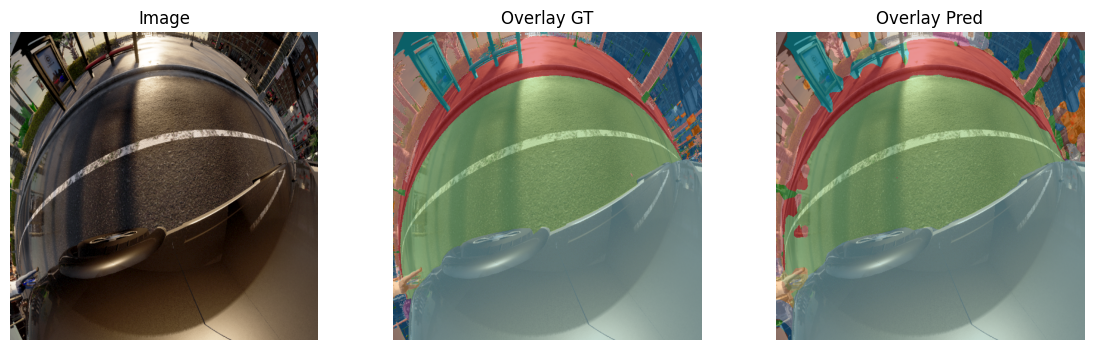

In [ ]:
def overlay_mask(img_rgb, mask, alpha=0.5):
    # use colormap color mask
    import matplotlib.cm as cm
    cmap = cm.get_cmap("tab20", cfg.num_classes)
    color = (cmap(mask % cfg.num_classes)[:, :, :3] * 255).astype(np.uint8)
    out = (img_rgb*(1-alpha) + color*alpha).astype(np.uint8)
    return out

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img_r); plt.axis("off")
plt.subplot(1,3,2); plt.title("Overlay GT"); plt.imshow(overlay_mask(img_r, gt)); plt.axis("off")
plt.subplot(1,3,3); plt.title("Overlay Pred"); plt.imshow(overlay_mask(img_r, pred)); plt.axis("off")
plt.show()


In [22]:
_, miou, pixacc, per_iou, valid = evaluate()

import matplotlib.pyplot as plt
cls_ids = np.arange(len(per_iou))
per_iou_plot = np.where(valid, per_iou, np.nan)

# Create labels matching the actual number of classes
num_classes = len(per_iou)
if num_classes <= len(CARLA_CLASS_NAMES):
    labels = CARLA_CLASS_NAMES[:num_classes]
else:
    # If we have more classes than names, pad with generic labels
    labels = CARLA_CLASS_NAMES + [f"Class_{i}" for i in range(len(CARLA_CLASS_NAMES), num_classes)]

plt.figure(figsize=(14, 6))
plt.bar(cls_ids, per_iou_plot)
plt.xlabel("Class")
plt.ylabel("IoU")
plt.title("Per-class IoU (valid classes)")
plt.xticks(cls_ids, labels, rotation=45, ha='right')
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Eval:   0%|          | 0/157 [00:00<?, ?it/s]

/tmp/ipython-input-464062176.py:339: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


## Visualization

In [27]:
"""
visualise_predictions.py
========================
Standalone visualisation script — assumes model is already trained.

For each sample it produces a 4-panel figure:
  ┌──────────────┬──────────────┐
  │  RGB image   │  GT mask     │
  ├──────────────┼──────────────┤
  │  Prediction  │  Error map   │
  └──────────────┴──────────────┘

The error map highlights:
  • Green  — correct prediction
  • Red    — wrong prediction (with LiDAR overlay shows depth of mistakes)

Outputs:
  • One PNG per sample in OUTPUT_DIR
  • A summary grid of all samples in OUTPUT_DIR/summary_grid.png
"""

import os
import glob
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import torch
import torch.nn as nn
import torch.nn.functional as F

matplotlib.use("Agg")

# ==============================================================================
# CONFIGURATION — edit these
# ==============================================================================

CHECKPOINT   = "/kaggle/working/checkpoints_improved/best_model.pt"
IMAGES_DIR   = "/content/datasets/synwoodscape/rgb_images/rgb_images"
MASKS_DIR    = "/content/datasets/synwoodscape/gtLabels/gtLabels"     # folder of GT mask files
OUTPUT_DIR   = "./visualisation_outputs"

# How mask files are named — adjust to match your dataset
# e.g. "00042_FV_mask.png" or "00042_FV.png" in a separate masks folder
MASK_SUFFIX  = "_mask.png"    # appended to base_name + camera, e.g. 00042_FV_mask.png

# Cameras to visualise
CAMERA_NAMES     = ["FV", "MVL", "MVR", "RV"]
IMAGE_EXTENSIONS = [".png", ".jpg", ".jpeg"]

# How many samples to visualise (None = all)
NUM_SAMPLES  = 16

# Model config — must match training exactly
NUM_CLASSES  = 25
MODEL_NAME   = "dinov2_vitb14"
N_LAYERS     = 4
DECODER_DIM  = 256
DROPOUT      = 0.1

# Class names — set to list of strings for readable legend, or None for cls_0..N
CLASS_NAMES  = None

# Colour palette — 25 visually distinct colours for class overlays
# Uses tab20 + tab20b extended. You can replace with your dataset's official palette.
def build_palette(n):
    cmap1 = plt.get_cmap("tab20")
    cmap2 = plt.get_cmap("tab20b")
    colours = [cmap1(i / 20) for i in range(20)] + \
              [cmap2(i / 20) for i in range(20)]
    return np.array([list(c[:3]) for c in colours[:n]])   # (N, 3) RGB float

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# MODEL  (identical to training — keep in sync)
# ==============================================================================

class GNAct(nn.Module):
    def __init__(self, c, groups=32, dropout=0.0):
        super().__init__()
        self.norm = nn.GroupNorm(min(groups, c), c)
        self.act  = nn.GELU()
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
    def forward(self, x):
        return self.drop(self.act(self.norm(x.contiguous())))

class MultiLayerFusionDecoder(nn.Module):
    def __init__(self, in_dim, n_layers, hidden, num_classes, dropout):
        super().__init__()
        self.proj = nn.ModuleList(
            [nn.Conv2d(in_dim, hidden, 1) for _ in range(n_layers)])
        self.post = nn.Sequential(
            nn.Conv2d(hidden * n_layers, hidden, 1),
            GNAct(hidden, dropout=dropout),
            nn.Conv2d(hidden, hidden, 3, padding=1),
            GNAct(hidden, dropout=dropout),
        )
        self.classifier = nn.Conv2d(hidden, num_classes, 1)
    def forward(self, feats, target_size):
        proj   = [p(f.contiguous()) for p, f in zip(self.proj, feats)]
        x      = torch.cat(proj, 1).contiguous()
        x      = self.post(x)
        logits = self.classifier(x)
        return F.interpolate(logits, size=target_size,
                             mode="bilinear", align_corners=False)

class DINOv2MultiLayerSeg(nn.Module):
    def __init__(self, model_name, num_classes, n_layers=4, hidden=256,
                 freeze_backbone=True, dropout=0.1, pretrained=False):
        super().__init__()
        self.backbone   = torch.hub.load(
            "facebookresearch/dinov2", model_name, pretrained=pretrained)
        self.patch_size = getattr(self.backbone, "patch_size", 14)
        self.embed_dim  = getattr(self.backbone, "embed_dim", 768)
        self.n_layers   = n_layers
        self.freeze_backbone = freeze_backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.backbone.eval()
        self.decoder = MultiLayerFusionDecoder(
            self.embed_dim, n_layers, hidden, num_classes, dropout)

    def _to_spatial(self, t, H, W):
        Hp, Wp = H // self.patch_size, W // self.patch_size
        return t.transpose(1, 2).reshape(
            t.size(0), t.size(2), Hp, Wp).contiguous()

    def forward(self, x):
        B, C, H, W = x.shape
        feats = []
        if hasattr(self.backbone, "get_intermediate_layers"):
            inter = self.backbone.get_intermediate_layers(
                x, n=self.n_layers, reshape=False, return_class_token=False)
            for t in inter:
                feats.append(t if t.dim() == 4 else self._to_spatial(t, H, W))
        else:
            out   = self.backbone.forward_features(x)
            patch = out["x_norm_patchtokens"]
            feats = [self._to_spatial(patch, H, W)] * self.n_layers
        return self.decoder(feats, (H, W))

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()
        return self

# ==============================================================================
# INFERENCE HELPERS
# ==============================================================================

_MEAN      = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD       = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
PATCH_SIZE = 14

def pad_to_patch(tensor, patch=PATCH_SIZE):
    _, _, H, W = tensor.shape
    pad_h = (patch - H % patch) % patch
    pad_w = (patch - W % patch) % patch
    tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode="reflect")
    return tensor, pad_h, pad_w

def load_rgb(path):
    img = mpimg.imread(path)
    if img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    if img.ndim == 2:
        img = np.stack([img]*3, -1)
    return img[:, :, :3]   # H×W×3  float32  [0,1]

def load_mask(path):
    """Load GT mask — expects single-channel image with class indices."""
    mask = mpimg.imread(path)
    if mask.ndim == 3:
        mask = mask[:, :, 0]   # take first channel if RGB saved
    if mask.dtype != np.int32 and mask.dtype != np.int64:
        # If saved as uint8 raw indices (common) just cast
        mask = mask.astype(np.int32)
    return mask   # H×W  int32

@torch.no_grad()
def run_inference(model, rgb_img):
    """rgb_img: H×W×3 float32 [0,1].  Returns H×W int32 predicted labels."""
    H, W = rgb_img.shape[:2]
    t = torch.from_numpy(rgb_img.transpose(2, 0, 1)).float()
    t = ((t - _MEAN) / _STD).unsqueeze(0).to(DEVICE)

    padded, pad_h, pad_w = pad_to_patch(t)
    logits = model(padded)

    pH, pW = padded.shape[-2], padded.shape[-1]
    logits = logits[:, :,
                    :pH - pad_h if pad_h > 0 else pH,
                    :pW - pad_w if pad_w > 0 else pW]
    if logits.shape[-2:] != (H, W):
        logits = F.interpolate(logits, (H, W), mode="bilinear", align_corners=False)

    return logits.argmax(1).squeeze(0).cpu().numpy().astype(np.int32)

# ==============================================================================
# COLOURISATION
# ==============================================================================

def colourise(label_map, palette):
    """label_map: H×W int.  Returns H×W×3 float32 RGB image."""
    H, W = label_map.shape
    rgb  = np.zeros((H, W, 3), dtype=np.float32)
    for c in range(len(palette)):
        rgb[label_map == c] = palette[c]
    return rgb

def error_map(gt, pred, ignore_index=-1):
    """
    Returns H×W×3 float32:
      green  (0.2, 0.8, 0.2) — correct
      red    (0.9, 0.2, 0.2) — wrong
      grey   (0.4, 0.4, 0.4) — ignored
    """
    H, W   = gt.shape
    canvas = np.zeros((H, W, 3), dtype=np.float32)
    valid  = gt != ignore_index
    correct         = valid & (gt == pred)
    wrong           = valid & (gt != pred)
    canvas[correct] = [0.20, 0.80, 0.20]
    canvas[wrong]   = [0.90, 0.20, 0.20]
    canvas[~valid]  = [0.40, 0.40, 0.40]
    return canvas

# ==============================================================================
# PER-SAMPLE FIGURE
# ==============================================================================

def make_figure(rgb, gt_mask, pred_mask, palette, class_names,
                title, ignore_index=-1):
    """
    4-panel figure:
      [RGB]        [GT coloured]
      [Prediction] [Error map]
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.patch.set_facecolor("#0d1117")

    for ax in axes.flat:
        ax.set_facecolor("#0d1117")
        ax.axis("off")

    def show(ax, img, title_str, cmap=None):
        ax.imshow(img, cmap=cmap, interpolation="nearest")
        ax.set_title(title_str, color="#e6edf3", fontsize=11,
                     fontweight="bold", pad=8)
        ax.axis("off")

    gt_col   = colourise(gt_mask,   palette)
    pred_col = colourise(pred_mask, palette)
    err      = error_map(gt_mask, pred_mask, ignore_index)

    # Compute per-frame pixel accuracy for subtitle
    valid   = gt_mask != ignore_index
    correct = valid & (gt_mask == pred_mask)
    acc     = correct.sum() / valid.sum() if valid.sum() > 0 else 0.0
    iou_per = []
    for c in range(len(palette)):
        tp    = ((gt_mask == c) & (pred_mask == c)).sum()
        fp    = ((gt_mask != c) & (pred_mask == c)).sum()
        fn    = ((gt_mask == c) & (pred_mask != c)).sum()
        denom = tp + fp + fn
        iou_per.append(tp / denom if denom > 0 else np.nan)
    miou = float(np.nanmean(iou_per))

    fig.suptitle(
        f"{title}    |    Pixel Acc: {acc:.3f}    mIoU: {miou:.3f}",
        color="#58a6ff", fontsize=13, fontweight="bold", y=1.01
    )

    # Blend RGB + coloured mask for GT and Pred panels (0.55 RGB + 0.45 colour)
    gt_blend   = np.clip(rgb * 0.55 + gt_col   * 0.45, 0, 1)
    pred_blend = np.clip(rgb * 0.55 + pred_col * 0.45, 0, 1)

    show(axes[0, 0], rgb,        "RGB Image")
    show(axes[0, 1], gt_blend,   "Ground Truth")
    show(axes[1, 0], pred_blend, "Prediction")
    show(axes[1, 1], err,        f"Error Map  (green=correct  red=wrong)")

    # ── Compact legend ────────────────────────────────────────────────────────
    # Only show classes that actually appear in this GT mask
    present = sorted(set(gt_mask[gt_mask != ignore_index].ravel()))
    patches = [
        mpatches.Patch(
            facecolor=palette[c],
            label=f"{class_names[c]}" if c < len(class_names) else f"cls_{c}"
        )
        for c in present if c < len(palette)
    ]
    if patches:
        fig.legend(
            handles=patches,
            loc="lower center",
            ncol=min(len(patches), 8),
            fontsize=7.5,
            facecolor="#161b22",
            labelcolor="#c9d1d9",
            edgecolor="#30363d",
            bbox_to_anchor=(0.5, -0.04),
        )

    plt.tight_layout(pad=1.5)
    return fig

# ==============================================================================
# SAMPLE DISCOVERY
# ==============================================================================

def find_samples(images_dir, masks_dir, camera_names,
                 image_extensions, mask_suffix, num_samples):
    """
    Walk the images directory and pair each RGB with its GT mask.
    Returns list of (base_name, camera, img_path, mask_path).
    """
    samples = []
    img_files = sorted(os.listdir(images_dir))

    for fname in img_files:
        name, ext = os.path.splitext(fname)
        if ext.lower() not in image_extensions:
            continue

        # Expect names like  00042_FV
        parts = name.rsplit("_", 1)
        if len(parts) != 2:
            continue
        base, cam = parts
        if cam not in camera_names:
            continue

        img_path = os.path.join(images_dir, fname)

        # Try several common mask naming patterns
        mask_path = None
        candidates = [
            os.path.join(masks_dir, f"{name}{mask_suffix}"),
            os.path.join(masks_dir, f"{name}.png"),
            os.path.join(masks_dir, f"{name}.jpg"),
            os.path.join(masks_dir, cam, f"{base}.png"),
            os.path.join(masks_dir, cam, f"{base}.jpg"),
        ]
        for c in candidates:
            if os.path.exists(c):
                mask_path = c
                break

        if mask_path is None:
            continue

        samples.append((base, cam, img_path, mask_path))
        if num_samples and len(samples) >= num_samples:
            break

    return samples

# ==============================================================================
# SUMMARY GRID
# ==============================================================================

def make_summary_grid(thumbnails, titles, output_dir):
    """
    thumbnails: list of H×W×3 numpy arrays (error maps)
    Saves a compact grid overview to summary_grid.png
    """
    n    = len(thumbnails)
    cols = min(4, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 4, rows * 3))
    fig.patch.set_facecolor("#0d1117")
    axes = np.array(axes).reshape(rows, cols)

    for idx in range(rows * cols):
        r, c = divmod(idx, cols)
        ax   = axes[r, c]
        ax.set_facecolor("#0d1117")
        ax.axis("off")
        if idx < n:
            ax.imshow(thumbnails[idx], interpolation="nearest")
            ax.set_title(titles[idx], color="#c9d1d9",
                         fontsize=7, pad=4)

    fig.suptitle("Prediction Error Map Overview  (green=correct  red=wrong)",
                 color="#58a6ff", fontsize=12, fontweight="bold")
    plt.tight_layout(pad=1.0)
    out = os.path.join(output_dir, "summary_grid.png")
    plt.savefig(out, dpi=120, bbox_inches="tight", facecolor="#0d1117")
    plt.close()
    print(f"✓ Summary grid saved: {out}")

# ==============================================================================
# MAIN
# ==============================================================================

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    class_names = CLASS_NAMES or [f"cls_{i}" for i in range(NUM_CLASSES)]
    palette     = build_palette(NUM_CLASSES)

    # ── Load model ────────────────────────────────────────────────────────────
    print("Loading model …")
    model = DINOv2MultiLayerSeg(
        model_name      = MODEL_NAME,
        num_classes     = NUM_CLASSES,
        n_layers        = N_LAYERS,
        hidden          = DECODER_DIM,
        freeze_backbone = True,
        dropout         = DROPOUT,
        pretrained      = False,
    ).to(DEVICE)

    ckpt  = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
    state = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(state, strict=True)
    model.eval()
    print(f"✓ Loaded: {CHECKPOINT}")

    # ── Discover samples ──────────────────────────────────────────────────────
    samples = find_samples(
        IMAGES_DIR, MASKS_DIR, CAMERA_NAMES,
        IMAGE_EXTENSIONS, MASK_SUFFIX, NUM_SAMPLES)

    if not samples:
        print("No paired (image, mask) samples found. Check IMAGES_DIR, "
              "MASKS_DIR and MASK_SUFFIX in the config.")
        return

    print(f"Found {len(samples)} samples to visualise.\n")

    thumbnails, thumb_titles = [], []
    accs, mious = [], []

    for base, cam, img_path, mask_path in samples:
        title = f"{base}_{cam}"
        print(f"  {title}")

        # Load data
        rgb     = load_rgb(img_path)
        gt_mask = load_mask(mask_path)

        # Resize gt_mask to match rgb if needed
        if gt_mask.shape[:2] != rgb.shape[:2]:
            from PIL import Image
            gt_pil  = Image.fromarray(gt_mask.astype(np.uint8))
            gt_pil  = gt_pil.resize((rgb.shape[1], rgb.shape[0]),
                                     Image.NEAREST)
            gt_mask = np.array(gt_pil).astype(np.int32)

        # Run inference
        pred_mask = run_inference(model, rgb)

        # Per-sample metrics
        valid   = gt_mask >= 0
        acc     = float((gt_mask[valid] == pred_mask[valid]).mean()) \
                  if valid.any() else 0.0
        iou_per = []
        for c in range(NUM_CLASSES):
            tp    = int(((gt_mask == c) & (pred_mask == c)).sum())
            fp    = int(((gt_mask != c) & (pred_mask == c)).sum())
            fn    = int(((gt_mask == c) & (pred_mask != c)).sum())
            denom = tp + fp + fn
            iou_per.append(tp / denom if denom > 0 else np.nan)
        miou = float(np.nanmean(iou_per))
        accs.append(acc); mious.append(miou)
        print(f"    PixAcc={acc:.4f}  mIoU={miou:.4f}")

        # Make and save figure
        fig  = make_figure(rgb, gt_mask, pred_mask, palette,
                           class_names, title)
        out  = os.path.join(OUTPUT_DIR, f"{title}_vis.png")
        fig.savefig(out, dpi=130, bbox_inches="tight", facecolor="#0d1117")
        plt.close(fig)

        # Store error map thumbnail for summary grid
        thumbnails.append(error_map(gt_mask, pred_mask))
        thumb_titles.append(f"{title}\nAcc:{acc:.2f} mIoU:{miou:.2f}")

    # ── Summary grid ──────────────────────────────────────────────────────────
    if thumbnails:
        make_summary_grid(thumbnails, thumb_titles, OUTPUT_DIR)

    # ── Overall stats ─────────────────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"  Samples visualised : {len(samples)}")
    print(f"  Mean Pixel Acc     : {np.mean(accs):.4f}")
    print(f"  Mean mIoU          : {np.mean(mious):.4f}")
    print(f"  Output dir         : {OUTPUT_DIR}")
    print(f"{'='*50}")


if __name__ == "__main__":
    main()

Loading model …


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✓ Loaded: /kaggle/working/checkpoints_improved/best_model.pt
Found 16 samples to visualise.

  00000_FV
    PixAcc=0.0000  mIoU=0.0000
  00000_MVL
    PixAcc=0.0000  mIoU=0.0000
  00000_MVR
    PixAcc=0.0000  mIoU=0.0000
  00000_RV
    PixAcc=0.0000  mIoU=0.0000
  00001_FV
    PixAcc=0.0000  mIoU=0.0000
  00001_MVL
    PixAcc=0.0000  mIoU=0.0000
  00001_MVR
    PixAcc=0.0000  mIoU=0.0000
  00001_RV
    PixAcc=0.0000  mIoU=0.0000
  00002_FV
    PixAcc=0.0000  mIoU=0.0000
  00002_MVL
    PixAcc=0.0000  mIoU=0.0000
  00002_MVR
    PixAcc=0.0000  mIoU=0.0000
  00002_RV
    PixAcc=0.0000  mIoU=0.0000
  00003_FV
    PixAcc=0.0000  mIoU=0.0000
  00003_MVL
    PixAcc=0.0000  mIoU=0.0000
  00003_MVR
    PixAcc=0.0000  mIoU=0.0000
  00003_RV
    PixAcc=0.0000  mIoU=0.0000
✓ Summary grid saved: ./visualisation_outputs/summary_grid.png

  Samples visualised : 16
  Mean Pixel Acc     : 0.0000
  Mean mIoU          : 0.0000
  Output dir         : ./visualisation_outputs


In [24]:
import os, numpy as np, torch
import matplotlib.pyplot as plt

# ===== 1) Load best checkpoint =====
ckpt_path = os.path.join("/kaggle/working/checkpoints_improved/", "best_model.pt")  # cfg.out_dir is "./checkpoints_improved"
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"], strict=True)
model.to(DEVICE).eval()
best_epoch = ckpt.get("epoch", None)

# ===== 2) Re-evaluate to get pixAcc/mIoU (auto) =====
# Reuse existing evaluate() in the notebook; if it returns (loss, miou, pixacc, per_iou, valid)
te_loss, best_miou, best_pixacc, per_iou, valid = evaluate()

print(f"[Best ckpt] epoch={best_epoch}  mIoU={best_miou:.4f}  pixAcc={best_pixacc:.4f}  te_loss={te_loss:.4f}")

# ===== 3) Helpers: denorm / colorize / overlay =====
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def denorm_img(x_chw: torch.Tensor) -> np.ndarray:
    """x_chw: torch float tensor, CHW, normalized"""
    x = x_chw.detach().cpu().float().numpy()
    x = np.transpose(x, (1,2,0))  # HWC
    x = x * IMAGENET_STD + IMAGENET_MEAN
    x = np.clip(x, 0, 1)
    return x

def make_colormap(n: int) -> np.ndarray:
    """Return (n,3) uint8 colormap."""
    cmap = plt.get_cmap("tab20", n)  # deterministic
    colors = (cmap(np.arange(n))[:, :3] * 255).astype(np.uint8)
    return colors

COLORS = make_colormap(cfg.num_classes)

def colorize_mask(mask_hw: np.ndarray, ignore_index: int = None) -> np.ndarray:
    """mask_hw: (H,W) int -> (H,W,3) uint8"""
    h, w = mask_hw.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    valid = np.ones((h, w), dtype=bool)
    if ignore_index is not None:
        valid = (mask_hw != ignore_index)
    m = np.clip(mask_hw, 0, cfg.num_classes - 1)
    out[valid] = COLORS[m[valid]]
    return out

def overlay(image_rgb01: np.ndarray, mask_rgb255: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    """image_rgb01 float[0,1], mask_rgb255 uint8 -> overlay float[0,1]"""
    mask01 = mask_rgb255.astype(np.float32) / 255.0
    out = (1 - alpha) * image_rgb01 + alpha * mask01
    return np.clip(out, 0, 1)

# ===== 4) Sample 6 test images =====
test_ds = test_loader.dataset
rng = np.random.default_rng(0)
k = 6
idxs = rng.choice(len(test_ds), size=min(k, len(test_ds)), replace=False)

# ===== 5) Plot grid: rows=k, cols=4 =====
fig, axes = plt.subplots(nrows=len(idxs), ncols=4, figsize=(16, 4*len(idxs)))
if len(idxs) == 1:
    axes = np.expand_dims(axes, 0)

col_titles = ["Image", "GT", "Pred", "Overlay"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=14)

for r, i in enumerate(idxs):
    sample = test_ds[i]
    img_t = sample["image"]              # CHW normalized tensor
    gt_t  = sample["mask"]               # HW tensor (long)
    gt = gt_t.detach().cpu().numpy().astype(np.int64)

    # forward
    with torch.no_grad():
        logits = model(img_t.unsqueeze(0).to(DEVICE))
        pred = logits.argmax(dim=1).squeeze(0).detach().cpu().numpy().astype(np.int64)

    img = denorm_img(img_t)
    gt_rgb = colorize_mask(gt, ignore_index=cfg.ignore_index)
    pred_rgb = colorize_mask(pred, ignore_index=cfg.ignore_index)
    ov = overlay(img, pred_rgb, alpha=0.45)

    axes[r, 0].imshow(img);      axes[r, 0].axis("off")
    axes[r, 1].imshow(gt_rgb);   axes[r, 1].axis("off")
    axes[r, 2].imshow(pred_rgb); axes[r, 2].axis("off")
    axes[r, 3].imshow(ov);       axes[r, 3].axis("off")

fig.suptitle(
    f"Best checkpoint @ epoch {best_epoch} | mIoU={best_miou:.4f} | pixAcc={best_pixacc:.4f}",
    fontsize=16, y=0.995
)
fig.tight_layout(rect=[0, 0, 1, 0.98])

save_path = os.path.join(cfg.out_dir, "qualitative_grid.png")
fig.savefig(save_path, dpi=200)
print("Saved qualitative grid to:", save_path)

plt.show()


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
final_ckpt = {
    "model": model.state_dict(),
    "cfg": cfg.__dict__,
    "history": history,                 # have a history dict in notebook
    "best_miou": float(best_miou),
    "best_pixacc": float(best_pixacc),
    "best_epoch": int(best_epoch) if best_epoch is not None else None,
}
torch.save(final_ckpt, os.path.join(cfg.out_dir, "final_artifacts.pt"))
print("Saved:", os.path.join(cfg.out_dir, "final_artifacts.pt"))

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
NUM_CLASSES = cfg.num_classes
DEPTH_BINS = [0, 5, 10, 20, 30, 40, 60]  # meters
DEVICE = next(model.parameters()).device

# ------------------------------------------------------------
# Depth-binned IoU computation
# ------------------------------------------------------------
def compute_depth_binned_miou(pred, gt, depth, num_classes, bins):

    valid_depth = ~np.isnan(depth)
    bin_ious = [[] for _ in range(len(bins) - 1)]

    for i in range(len(bins) - 1):
        d_min, d_max = bins[i], bins[i+1]

        depth_mask = (depth >= d_min) & (depth < d_max)
        mask = valid_depth & depth_mask

        if mask.sum() == 0:
            continue

        ious = []

        for cls in range(num_classes):
            pred_c = (pred == cls)
            gt_c   = (gt == cls)

            intersection = np.logical_and(pred_c, gt_c) & mask
            union        = np.logical_or(pred_c, gt_c) & mask

            union_sum = union.sum()
            if union_sum == 0:
                continue

            iou = intersection.sum() / union_sum
            ious.append(iou)

        if len(ious) > 0:
            bin_ious[i].append(np.mean(ious))

    return bin_ious


# ------------------------------------------------------------
# VALIDATION LOOP
# ------------------------------------------------------------
model.eval()

all_bin_results = [[] for _ in range(len(DEPTH_BINS) - 1)]

with torch.no_grad():
    for batch in val_loader:

        images = batch["image"].to(DEVICE)      # [B,C,H,W]
        gt     = batch["mask"].to(DEVICE)       # [B,H,W]
        depth  = batch["depth"].cpu().numpy()   # [B,H,W] sparse depth

        logits = model(images)
        preds  = torch.argmax(logits, dim=1)

        for b in range(images.size(0)):

            pred_np  = preds[b].cpu().numpy()
            gt_np    = gt[b].cpu().numpy()
            depth_np = depth[b]

            # If depth resolution mismatch → resize using nearest
            if depth_np.shape != pred_np.shape:
                depth_np = torch.tensor(depth_np)[None,None]
                depth_np = torch.nn.functional.interpolate(
                    depth_np.float(),
                    size=pred_np.shape,
                    mode="nearest"
                )[0,0].numpy()

            bin_ious = compute_depth_binned_miou(
                pred_np,
                gt_np,
                depth_np,
                NUM_CLASSES,
                DEPTH_BINS
            )

            for i in range(len(bin_ious)):
                all_bin_results[i].extend(bin_ious[i])


# ------------------------------------------------------------
# Aggregate across dataset
# ------------------------------------------------------------
mean_miou_per_bin = []
for values in all_bin_results:
    if len(values) > 0:
        mean_miou_per_bin.append(np.mean(values))
    else:
        mean_miou_per_bin.append(np.nan)

# ------------------------------------------------------------
# Plot Depth vs mIoU
# ------------------------------------------------------------
bin_centers = 0.5 * (np.array(DEPTH_BINS[:-1]) + np.array(DEPTH_BINS[1:]))

plt.figure(figsize=(8,5))
plt.plot(bin_centers, mean_miou_per_bin, marker='o')
plt.xlabel("Depth (meters)")
plt.ylabel("mIoU")
plt.title("Segmentation Performance vs Depth")
plt.grid(True)
plt.show()

print("Depth bins:", DEPTH_BINS)
print("mIoU per bin:", mean_miou_per_bin)

NameError: name 'val_loader' is not defined

# Report and Explanation

Based on final working `run_ready_dinov2_fisheye_synwoodscape_v2.ipynb` and the results (`cfg.epochs=50`, best mIoU ≈ **0.4444**, pixAcc ≈ **0.8919**, and the best checkpoint is saved as `./checkpoints_improved/best_model.pt`).

---

## 1) Brief summary (key actions + result interpretation + improvement suggestions)

### Key actions
- **Data**: Automatically paired SynWoodScape-style RGB with masks (`list_pairs`), and used `cfg.max_samples` to cap the number of training samples (ran with **1000**).  
- **Model**:  
  - Backbone: Loaded **DINOv2 ViT-B/14** (`dinov2_vitb14`) via `torch.hub`, with **freeze_backbone=True** by default (so trainable parameters mainly come from the decoder).  
  - Decoder: Fused multi-layer intermediate features (`n_layers=4`) via **1×1 projection + concat + conv + GN+GELU**, then produced semantic segmentation logits.  
- **Training**: AdamW + warmup (10%) + cosine schedule; loss mainly **CrossEntropy** (optional Dice); selected best checkpoint by **mIoU** and saved it.  
- **Evaluation & visualization**: Plotted loss curves, mIoU/pixAcc curves, LR curve, and a per-class IoU bar chart.

### How to interpret results
- **Converged normally**: Both train/test loss decreased clearly; mIoU increased steadily and then approached a plateau.  
- **Generalization starts to “stall”**: In later epochs, train loss still decreases slowly, but test loss and mIoU improve more slowly—meaning we’ve largely exhausted the gains from the current data/settings.  
- **Typical behavior with frozen backbone**: We have about **1.65M** trainable parameters ( total ≈ 88.2M / trainable ≈ 1.65M). This often yields a good baseline, but the upper bound is limited.

### Next steps to improve “accuracy/segmentation quality” (aligned with the syn2real project idea)
For our “Syn2Real fisheye segmentation” direction, the most effective gains usually come less from training longer and more from these steps (sorted by best payoff vs effort):

1) **Unfreeze the last few backbone layers for lightweight fine-tuning**  
   - Unfreeze only the last 1–2 transformer blocks (or last `n` layers), and use a smaller LR for the backbone (e.g., 1/10 of the decoder LR).  
2) **Stronger augmentations (fisheye + domain gap oriented)**  
   - Brightness/contrast/color temperature/noise/blur/fogging, random occlusion; plus fisheye-related geometric perturbations (mild radial warp / crop / perspective).  
3) **Class imbalance handling (if per-class IoU shows “low-performing” classes)**  
   - Add class weights to CE, or switch to **Focal Loss**; Dice/Lovasz are also common.  
4) **Increase input resolution or multi-scale training/inference**  
   - Segmentation is detail-sensitive; higher resolution often boosts mIoU, but costs more compute.  
5) **True Syn→Real: add unlabeled target (real) self-training** (if project plan includes it)  
   - Use our best model to generate pseudo-labels on real images, then mix them into training (with confidence thresholding / consistency regularization).

## 2) Moving to Colab / Kaggle with CUDA: what to change + how to optimize for CUDA

### A. Device & AMP (AMP is recommended on CUDA)
Replace current MPS logic with CUDA-friendly code:

```python
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

use_amp = (cfg.use_amp and DEVICE.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# autocast for cuda
autocast_ctx = torch.cuda.amp.autocast if DEVICE.type == "cuda" else torch.autocast

### In training:

```python
with torch.cuda.amp.autocast(enabled=use_amp):
    logits = model(img)
    loss = ce_loss(logits, msk)  # + dice, etc.
    loss = loss / cfg.grad_accum_steps

scaler.scale(loss).backward()

if (it + 1) % cfg.grad_accum_steps == 0:
    scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad(set_to_none=True)
# Previously disabled AMP correctly (AMP on MPS can be unstable), but on CUDA you should enable it for speed and lower VRAM usage.

### B. DataLoader (pin_memory + workers strongly recommended on CUDA)

```python
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=4,              # Colab often 2~4; Kaggle can be 4~8
    pin_memory=True,            # speeds up H2D copy on CUDA
    persistent_workers=True,
    prefetch_factor=2,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.eval_bs,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)


### C. CUDA performance toggles (optional but commonly used)

```python
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")  # PyTorch 2.x

### D. xFormers warning (can be “actually fixed” on CUDA)

```python
pip install xformers
# After that, attention/MLP may run faster and use less VRAM (depends on version compatibility).

In [ ]:
"""
Self-Attention Analysis for DINOv2 on Fisheye Images
Analyzes patch-to-patch attention patterns to understand:
1. Which patches attend to which other patches
2. Center bias and attention collapse
3. Peripheral patch behavior
4. Long-range interactions despite distortion
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cv2
from PIL import Image
import seaborn as sns

# ============================================================================
# EXTRACT SELF-ATTENTION MAPS
# ============================================================================

def extract_self_attention(model, image_tensor, layer_idx=-1, head_idx=None):
    """
    Extract self-attention maps from a specific layer and head.

    Args:
        model: DINOv2-based model
        image_tensor: [1, 3, H, W] input tensor
        layer_idx: Which transformer layer (-1 = last)
        head_idx: Which attention head (None = all heads)

    Returns:
        attention: [num_heads, num_patches, num_patches] or [num_patches, num_patches]
        num_patches_h: Number of patches vertically
        num_patches_w: Number of patches horizontally
    """
    model.eval()
    attentions = []

    def hook_fn(module, input, output):
        # For DINOv2, attn layer outputs attention weights
        # Shape: [B, num_heads, num_patches, num_patches]
        attentions.append(output)

    # Register hook on attention layer
    try:
        if hasattr(model, 'backbone') and hasattr(model.backbone, 'blocks'):
            hook = model.backbone.blocks[layer_idx].attn.register_forward_hook(hook_fn)
        elif hasattr(model, 'encoder') and hasattr(model.encoder, 'blocks'):
            hook = model.encoder.blocks[layer_idx].attn.register_forward_hook(hook_fn)
        elif hasattr(model, 'blocks'):
            hook = model.blocks[layer_idx].attn.register_forward_hook(hook_fn)
        else:
            raise AttributeError("Could not find attention blocks")
    except Exception as e:
        print(f"❌ Error registering hook: {e}")
        return None, 0, 0

    # Forward pass
    with torch.no_grad():
        _ = model(image_tensor)

    hook.remove()

    if not attentions:
        print("❌ No attention captured")
        return None, 0, 0

    # Extract attention: [B, num_heads, num_patches, num_patches]
    attn = attentions[0][0].cpu()  # Remove batch dim: [num_heads, num_patches, num_patches]

    # Calculate patch grid dimensions (subtract 1 for CLS token)
    num_patches = attn.shape[-1] - 1  # Exclude CLS token
    num_patches_side = int(np.sqrt(num_patches))
    num_patches_h = num_patches_w = num_patches_side

    if head_idx is not None:
        attn = attn[head_idx:head_idx+1]  # Keep single head

    return attn, num_patches_h, num_patches_w


# ============================================================================
# VISUALIZATION 1: Patch-to-Patch Attention Matrix
# ============================================================================

def visualize_patch_attention_matrix(attn, layer_idx, head_idx, save_path=None):
    """
    Visualize full attention matrix showing which patches attend to which.

    Args:
        attn: [num_patches, num_patches] attention weights
        layer_idx: Layer index for title
        head_idx: Head index for title
        save_path: Where to save figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Full attention matrix (including CLS token)
    im1 = axes[0].imshow(attn.numpy(), cmap='viridis', aspect='auto')
    axes[0].set_title(f'Full Attention Matrix\nLayer {layer_idx}, Head {head_idx}', fontsize=14)
    axes[0].set_xlabel('Target Patch')
    axes[0].set_ylabel('Source Patch')
    axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='CLS token')
    axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)
    plt.colorbar(im1, ax=axes[0], label='Attention Weight')

    # Patch-to-patch only (exclude CLS token)
    patch_attn = attn[1:, 1:]  # Remove CLS token row and column
    im2 = axes[1].imshow(patch_attn.numpy(), cmap='viridis', aspect='auto')
    axes[1].set_title(f'Patch-to-Patch Attention\n(CLS token excluded)', fontsize=14)
    axes[1].set_xlabel('Target Patch')
    axes[1].set_ylabel('Source Patch')
    plt.colorbar(im2, ax=axes[1], label='Attention Weight')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")

    plt.show()
    return patch_attn


# ============================================================================
# VISUALIZATION 2: Spatial Attention Patterns
# ============================================================================

def visualize_spatial_attention_patterns(attn, num_patches_h, num_patches_w,
                                        query_positions, save_path=None):
    """
    Visualize where specific patches attend in spatial layout.

    Args:
        attn: [num_patches, num_patches] attention (excluding CLS)
        num_patches_h, num_patches_w: Patch grid dimensions
        query_positions: List of (row, col) positions to visualize
        save_path: Where to save figure
    """
    num_queries = len(query_positions)
    fig, axes = plt.subplots(2, num_queries, figsize=(4*num_queries, 8))
    if num_queries == 1:
        axes = axes.reshape(2, 1)

    # Reshape attention to spatial grid for each query
    for idx, (qrow, qcol) in enumerate(query_positions):
        query_idx = qrow * num_patches_w + qcol

        # Get attention from this query patch to all other patches
        attn_from_query = attn[query_idx].numpy()
        attn_spatial = attn_from_query.reshape(num_patches_h, num_patches_w)

        # Create query position indicator
        query_grid = np.zeros((num_patches_h, num_patches_w))
        query_grid[qrow, qcol] = 1

        # Plot query position
        axes[0, idx].imshow(query_grid, cmap='Reds', vmin=0, vmax=1)
        axes[0, idx].set_title(f'Query Patch\n({qrow}, {qcol})', fontsize=12)
        axes[0, idx].axis('off')
        axes[0, idx].plot(qcol, qrow, 'r*', markersize=20, markeredgecolor='white', markeredgewidth=2)

        # Plot attention pattern
        im = axes[1, idx].imshow(attn_spatial, cmap='hot', vmin=0)
        axes[1, idx].set_title(f'Attention Pattern\nMax: {attn_spatial.max():.3f}', fontsize=12)
        axes[1, idx].axis('off')
        axes[1, idx].plot(qcol, qrow, 'g*', markersize=20, markeredgecolor='white', markeredgewidth=2)
        plt.colorbar(im, ax=axes[1, idx], fraction=0.046)

    plt.suptitle('Which Patches Each Query Patch Attends To', fontsize=16, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")

    plt.show()


# ============================================================================
# ANALYSIS 1: Center Bias - Does Attention Collapse Toward Center?
# ============================================================================

def analyze_center_bias(attn, num_patches_h, num_patches_w, save_path=None):
    """
    Analyze if attention collapses toward the center of the image.
    Critical for fisheye images where center is typically less distorted.
    """
    # Calculate distance from center for each patch
    center_h, center_w = num_patches_h / 2, num_patches_w / 2

    distances = []
    attention_to_center = []

    for i in range(num_patches_h):
        for j in range(num_patches_w):
            patch_idx = i * num_patches_w + j

            # Distance from center
            dist = np.sqrt((i - center_h)**2 + (j - center_w)**2)
            distances.append(dist)

            # How much does this patch attend to center patches?
            center_region = []
            for ci in range(max(0, int(center_h)-1), min(num_patches_h, int(center_h)+2)):
                for cj in range(max(0, int(center_w)-1), min(num_patches_w, int(center_w)+2)):
                    center_idx = ci * num_patches_w + cj
                    center_region.append(attn[patch_idx, center_idx].item())

            attention_to_center.append(np.mean(center_region))

    # Plot analysis
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Scatter plot: Distance vs attention to center
    axes[0].scatter(distances, attention_to_center, alpha=0.5, s=50)
    axes[0].set_xlabel('Distance from Center (patches)', fontsize=12)
    axes[0].set_ylabel('Average Attention to Center', fontsize=12)
    axes[0].set_title('Center Bias Analysis\nDo peripheral patches attend to center?', fontsize=14)
    axes[0].grid(True, alpha=0.3)

    # Add trend line
    z = np.polyfit(distances, attention_to_center, 2)
    p = np.poly1d(z)
    x_trend = np.linspace(min(distances), max(distances), 100)
    axes[0].plot(x_trend, p(x_trend), 'r--', linewidth=2, label='Trend')
    axes[0].legend()

    # 2. Heatmap: Average attention received by each position
    attention_received = attn.mean(dim=0).numpy().reshape(num_patches_h, num_patches_w)
    im1 = axes[1].imshow(attention_received, cmap='hot')
    axes[1].set_title('Average Attention Received\n(Higher = More attended to)', fontsize=14)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    # Draw center circle
    circle = plt.Circle((num_patches_w/2, num_patches_h/2), 2,
                       fill=False, color='cyan', linewidth=2, linestyle='--')
    axes[1].add_patch(circle)

    # 3. Radial profile
    radial_bins = np.linspace(0, max(distances), 10)
    radial_attention = []
    for i in range(len(radial_bins)-1):
        mask = (np.array(distances) >= radial_bins[i]) & (np.array(distances) < radial_bins[i+1])
        if mask.sum() > 0:
            radial_attention.append(np.mean(np.array(attention_to_center)[mask]))
        else:
            radial_attention.append(0)

    axes[2].bar(range(len(radial_attention)), radial_attention, color='steelblue', edgecolor='black')
    axes[2].set_xlabel('Distance Bin (center → edge)', fontsize=12)
    axes[2].set_ylabel('Avg Attention to Center', fontsize=12)
    axes[2].set_title('Radial Profile\nHow attention to center changes with distance', fontsize=14)
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")

    plt.show()

    # Print statistics
    print("\n" + "="*70)
    print("CENTER BIAS ANALYSIS")
    print("="*70)
    print(f"Center patches receive: {attention_received[num_patches_h//2-1:num_patches_h//2+2, num_patches_w//2-1:num_patches_w//2+2].mean():.4f} avg attention")
    print(f"Edge patches receive: {np.mean([attention_received[0,:].mean(), attention_received[-1,:].mean(), attention_received[:,0].mean(), attention_received[:,-1].mean()]):.4f} avg attention")

    # Correlation
    correlation = np.corrcoef(distances, attention_to_center)[0,1]
    print(f"Correlation (distance vs attention to center): {correlation:.4f}")
    if correlation < -0.3:
        print("⚠ Strong center bias detected! Peripheral patches attend heavily to center.")
    elif correlation > 0.3:
        print("✓ No center bias. Peripheral patches don't over-attend to center.")
    else:
        print("✓ Moderate/no center bias.")
    print("="*70 + "\n")


# ============================================================================
# ANALYSIS 2: Peripheral Patch Behavior
# ============================================================================

def analyze_peripheral_patches(attn, num_patches_h, num_patches_w, save_path=None):
    """
    Analyze if peripheral patches are ignored or have different attention patterns.
    """
    # Define regions
    center_mask = np.zeros((num_patches_h, num_patches_w), dtype=bool)
    mid_mask = np.zeros((num_patches_h, num_patches_w), dtype=bool)
    edge_mask = np.zeros((num_patches_h, num_patches_w), dtype=bool)

    ch, cw = num_patches_h // 2, num_patches_w // 2

    for i in range(num_patches_h):
        for j in range(num_patches_w):
            dist = np.sqrt((i - ch)**2 + (j - cw)**2)
            max_dist = np.sqrt(ch**2 + cw**2)

            if dist < max_dist * 0.3:
                center_mask[i, j] = True
            elif dist < max_dist * 0.7:
                mid_mask[i, j] = True
            else:
                edge_mask[i, j] = True

    # Get patch indices for each region
    center_indices = [i * num_patches_w + j for i in range(num_patches_h)
                     for j in range(num_patches_w) if center_mask[i, j]]
    mid_indices = [i * num_patches_w + j for i in range(num_patches_h)
                  for j in range(num_patches_w) if mid_mask[i, j]]
    edge_indices = [i * num_patches_w + j for i in range(num_patches_h)
                   for j in range(num_patches_w) if edge_mask[i, j]]

    # Calculate attention statistics
    attn_np = attn.numpy()

    # How much attention does each region RECEIVE?
    center_received = attn_np[:, center_indices].mean()
    mid_received = attn_np[:, mid_indices].mean()
    edge_received = attn_np[:, edge_indices].mean()

    # How much attention does each region GIVE?
    center_given = attn_np[center_indices, :].mean()
    mid_given = attn_np[mid_indices, :].mean()
    edge_given = attn_np[edge_indices, :].mean()

    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Row 1: Region definitions and attention received
    region_map = np.zeros((num_patches_h, num_patches_w))
    region_map[center_mask] = 3
    region_map[mid_mask] = 2
    region_map[edge_mask] = 1

    axes[0, 0].imshow(region_map, cmap='RdYlGn')
    axes[0, 0].set_title('Region Definition\nGreen=Center, Yellow=Mid, Red=Edge', fontsize=12)
    axes[0, 0].axis('off')

    received = attn_np.mean(axis=0).reshape(num_patches_h, num_patches_w)
    im1 = axes[0, 1].imshow(received, cmap='hot')
    axes[0, 1].set_title('Attention Received\n(averaged over all queries)', fontsize=12)
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

    # Bar chart of received attention
    regions = ['Edge', 'Mid', 'Center']
    received_vals = [edge_received, mid_received, center_received]
    colors = ['#d62728', '#ff7f0e', '#2ca02c']
    axes[0, 2].bar(regions, received_vals, color=colors, edgecolor='black', linewidth=2)
    axes[0, 2].set_ylabel('Average Attention Received', fontsize=12)
    axes[0, 2].set_title('Attention Received by Region', fontsize=12)
    axes[0, 2].grid(True, alpha=0.3, axis='y')

    # Row 2: Attention patterns FROM each region
    for idx, (indices, region_name, color) in enumerate([
        (edge_indices, 'Edge Patches', '#d62728'),
        (mid_indices, 'Mid Patches', '#ff7f0e'),
        (center_indices, 'Center Patches', '#2ca02c')
    ]):
        avg_attn_from_region = attn_np[indices, :].mean(axis=0).reshape(num_patches_h, num_patches_w)
        im = axes[1, idx].imshow(avg_attn_from_region, cmap='hot')
        axes[1, idx].set_title(f'Where {region_name} Attend\n(averaged)', fontsize=12)
        axes[1, idx].axis('off')
        plt.colorbar(im, ax=axes[1, idx], fraction=0.046)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")

    plt.show()

    # Print statistics
    print("\n" + "="*70)
    print("PERIPHERAL PATCH ANALYSIS")
    print("="*70)
    print(f"Attention RECEIVED:")
    print(f"  Center patches: {center_received:.4f}")
    print(f"  Mid patches:    {mid_received:.4f}")
    print(f"  Edge patches:   {edge_received:.4f}")
    print(f"\nAttention GIVEN:")
    print(f"  Center patches: {center_given:.4f}")
    print(f"  Mid patches:    {mid_given:.4f}")
    print(f"  Edge patches:   {edge_given:.4f}")

    if edge_received < center_received * 0.7:
        print(f"\n⚠ Edge patches are IGNORED! They receive {edge_received/center_received:.1%} less attention than center.")
    else:
        print(f"\n✓ Edge patches are NOT ignored. Good global attention distribution.")

    print("="*70 + "\n")


# ============================================================================
# ANALYSIS 3: Long-Range Interactions
# ============================================================================

def analyze_long_range_interactions(attn, num_patches_h, num_patches_w, save_path=None):
    """
    Analyze if distant patches interact despite fisheye distortion.
    """
    num_patches = num_patches_h * num_patches_w

    # Calculate pairwise distances
    distance_matrix = np.zeros((num_patches, num_patches))
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            idx1 = i * num_patches_w + j
            for ii in range(num_patches_h):
                for jj in range(num_patches_w):
                    idx2 = ii * num_patches_w + jj
                    distance_matrix[idx1, idx2] = np.sqrt((i-ii)**2 + (j-jj)**2)

    # Flatten for analysis
    distances_flat = distance_matrix.flatten()
    attention_flat = attn.numpy().flatten()

    # Remove self-attention (distance = 0)
    mask = distances_flat > 0
    distances_flat = distances_flat[mask]
    attention_flat = attention_flat[mask]

    # Bin by distance
    max_dist = distances_flat.max()
    distance_bins = np.linspace(0, max_dist, 15)
    bin_centers = (distance_bins[:-1] + distance_bins[1:]) / 2
    binned_attention = []

    for i in range(len(distance_bins)-1):
        bin_mask = (distances_flat >= distance_bins[i]) & (distances_flat < distance_bins[i+1])
        if bin_mask.sum() > 0:
            binned_attention.append(attention_flat[bin_mask].mean())
        else:
            binned_attention.append(0)

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Scatter plot with trend
    axes[0].scatter(distances_flat[::100], attention_flat[::100], alpha=0.2, s=10)
    axes[0].plot(bin_centers, binned_attention, 'r-', linewidth=3, label='Average per bin')
    axes[0].set_xlabel('Spatial Distance (patches)', fontsize=12)
    axes[0].set_ylabel('Attention Weight', fontsize=12)
    axes[0].set_title('Long-Range Interactions\nAttention vs Distance', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(bottom=0)

    # 2. Attention decay curve
    axes[1].plot(bin_centers, binned_attention, 'o-', linewidth=2, markersize=8, color='steelblue')
    axes[1].fill_between(bin_centers, binned_attention, alpha=0.3, color='steelblue')
    axes[1].set_xlabel('Distance (patches)', fontsize=12)
    axes[1].set_ylabel('Average Attention', fontsize=12)
    axes[1].set_title('Attention Decay with Distance', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=binned_attention[0]/2, color='red', linestyle='--',
                    label=f'50% of nearest-neighbor attention', alpha=0.7)
    axes[1].legend()

    # 3. Heatmap: Example long-range connections
    # Pick a center patch and show its attention
    center_patch_idx = (num_patches_h // 2) * num_patches_w + (num_patches_w // 2)
    attn_from_center = attn[center_patch_idx].numpy().reshape(num_patches_h, num_patches_w)

    im = axes[2].imshow(attn_from_center, cmap='hot')
    axes[2].plot(num_patches_w//2, num_patches_h//2, 'g*', markersize=25,
                markeredgecolor='white', markeredgewidth=2, label='Query patch')
    axes[2].set_title(f'Long-Range Attention from Center Patch', fontsize=14)
    axes[2].axis('off')
    axes[2].legend(loc='upper right')
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")

    plt.show()

    # Statistics
    print("\n" + "="*70)
    print("LONG-RANGE INTERACTION ANALYSIS")
    print("="*70)

    # Find half-life distance (where attention drops to 50%)
    nearest_attn = binned_attention[0]
    half_attn = nearest_attn / 2
    half_life_idx = np.argmin(np.abs(np.array(binned_attention) - half_attn))
    half_life_distance = bin_centers[half_life_idx]

    print(f"Nearest-neighbor attention: {nearest_attn:.4f}")
    print(f"Long-range attention (max dist): {binned_attention[-1]:.4f}")
    print(f"Attention half-life: {half_life_distance:.2f} patches")
    print(f"Ratio (long-range / nearest): {binned_attention[-1] / nearest_attn:.2%}")

    if binned_attention[-1] / nearest_attn > 0.3:
        print("\n✓ Strong long-range interactions! Distant patches still attend to each other.")
        print("  Good for handling fisheye distortion across the image.")
    elif binned_attention[-1] / nearest_attn > 0.1:
        print("\n✓ Moderate long-range interactions. Some global context preserved.")
    else:
        print("\n⚠ Weak long-range interactions. Attention is mostly local.")
        print("  May struggle with global fisheye distortion patterns.")

    print("="*70 + "\n")


# ============================================================================
# COMPLETE SELF-ATTENTION ANALYSIS PIPELINE
# ============================================================================

def complete_self_attention_analysis(
    model,
    image_path,
    layer_idx=-1,
    head_idx=0,
    target_size=(518, 518),
    output_dir="/kaggle/working/"
):
    """
    Run complete self-attention analysis for fisheye images.

    Args:
        model: Trained DINOv2-based model
        image_path: Path to input image
        layer_idx: Which layer to analyze (-1 = last)
        head_idx: Which attention head to analyze
        target_size: Image size
        output_dir: Where to save visualizations
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "="*70)
    print("SELF-ATTENTION ANALYSIS FOR FISHEYE IMAGES")
    print("="*70)
    print(f"Layer: {layer_idx}, Head: {head_idx}")
    print(f"Image: {image_path}")
    print("="*70 + "\n")

    # 1. Load and preprocess image
    from torchvision import transforms
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(target_size)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img_resized).unsqueeze(0)

    device = next(model.parameters()).device
    img_tensor = img_tensor.to(device)

    # 2. Extract self-attention
    print("📊 Extracting self-attention maps...")
    attn_all, num_patches_h, num_patches_w = extract_self_attention(
        model, img_tensor, layer_idx, head_idx
    )

    if attn_all is None:
        print("❌ Failed to extract attention")
        return

    attn = attn_all[0]  # [num_patches+1, num_patches+1] (includes CLS)
    patch_attn = attn[1:, 1:]  # Exclude CLS token

    print(f"✓ Attention shape: {attn.shape}")
    print(f"✓ Patch grid: {num_patches_h} × {num_patches_w}")
    print()

    # 3. Visualize patch-to-patch attention matrix
    print("📊 Creating attention matrix visualization...")
    visualize_patch_attention_matrix(
        attn, layer_idx, head_idx,
        save_path=f"{output_dir}/attention_matrix_L{layer_idx}_H{head_idx}.png"
    )

    # 4. Visualize spatial attention patterns
    print("📊 Creating spatial attention patterns...")
    # Select interesting query positions: center, corners, edges
    h, w = num_patches_h, num_patches_w
    query_positions = [
        (h//2, w//2),           # Center
        (0, 0),                 # Top-left corner
        (h-1, w-1),             # Bottom-right corner
        (h//2, 0),              # Left edge
        (h//2, w-1),            # Right edge
    ]
    visualize_spatial_attention_patterns(
        patch_attn, num_patches_h, num_patches_w, query_positions,
        save_path=f"{output_dir}/spatial_patterns_L{layer_idx}_H{head_idx}.png"
    )

    # 5. Analyze center bias
    print("📊 Analyzing center bias...")
    analyze_center_bias(
        patch_attn, num_patches_h, num_patches_w,
        save_path=f"{output_dir}/center_bias_L{layer_idx}_H{head_idx}.png"
    )

    # 6. Analyze peripheral patches
    print("📊 Analyzing peripheral patch behavior...")
    analyze_peripheral_patches(
        patch_attn, num_patches_h, num_patches_w,
        save_path=f"{output_dir}/peripheral_analysis_L{layer_idx}_H{head_idx}.png"
    )

    # 7. Analyze long-range interactions
    print("📊 Analyzing long-range interactions...")
    analyze_long_range_interactions(
        patch_attn, num_patches_h, num_patches_w,
        save_path=f"{output_dir}/long_range_L{layer_idx}_H{head_idx}.png"
    )

    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print("="*70)
    print(f"All visualizations saved to: {output_dir}")
    print("="*70 + "\n")


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

print("""
USAGE EXAMPLE IN KAGGLE:

# After training your model:

complete_self_attention_analysis(
    model=model,
    image_path=test_pairs[0][0],  # First test image
    layer_idx=-1,                 # Last layer
    head_idx=0,                   # First attention head
    target_size=(518, 518),
    output_dir="/kaggle/working/attention_analysis/"
)

# Compare different layers:
for layer in [-1, -3, -6, -9]:
    complete_self_attention_analysis(
        model=model,
        image_path=test_pairs[0][0],
        layer_idx=layer,
        head_idx=0,
        output_dir=f"/kaggle/working/layer_{layer}/"
    )

# Compare different attention heads:
for head in range(12):  # ViT-B has 12 heads
    complete_self_attention_analysis(
        model=model,
        image_path=test_pairs[0][0],
        layer_idx=-1,
        head_idx=head,
        output_dir=f"/kaggle/working/head_{head}/"
    )
""")